# Fig2A

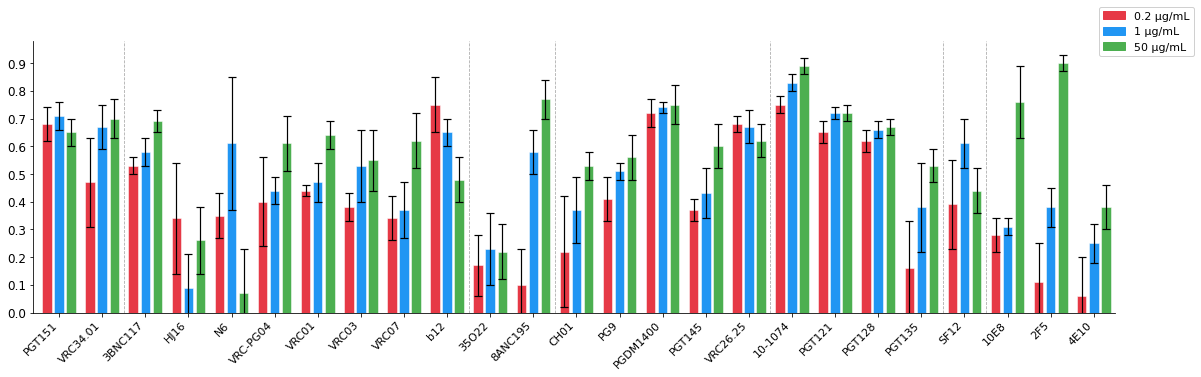

✓ Saved /Users/YUQIAO/blackbox/VALANCE/plots/valance_mcc_barplot.png


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
DATA_PATH  = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
METRIC     = "MCC"    # "MCC", "ACC", "AUC", "F1"
MODEL      = "VALANCE"  # "VALANCE", "BRAVE", "bNAb-ReP"
THRESHOLDS = [0.2, 1, 50]
THR_COLORS = {0.2: "#E63946", 1: "#2196F3", 50: "#4CAF50"}
THR_LABELS = {0.2: "0.2 µg/mL", 1: "1 µg/mL", 50: "50 µg/mL"}
ANTIBODIES_LIST = ['PGT121', 'VRC01', '10-1074', 'PGT145', '3BNC117', 'PGDM1400',
                   'VRC26.25', 'PGT151', 'PG9', '4E10', 'PGT128', 'SF12', 'N6',
                   '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 'VRC34.01',
                   'b12', 'VRC03', 'VRC07', '2F5', '8ANC195']


MODEL_COL_PREFIX = {
    "VALANCE":  "VALANCE",
    "BRAVE":    "BRAVE",
    "bNAb-ReP": "bNab-rep",
}
col_prefix = MODEL_COL_PREFIX[MODEL]


raw = pd.read_excel(XLSX_PATH, sheet_name="Fig_2A", header=1)
raw = raw.iloc[:, :14]
raw.columns = [
    "Antibody", "Threshold",
    "bNab-rep MCC", "bNab-rep ACC", "bNab-rep AUC", "bNab-rep F1",
    "BRAVE MCC",    "BRAVE ACC",    "BRAVE AUC",    "BRAVE F1",
    "VALANCE MCC",  "VALANCE ACC",  "VALANCE AUC",  "VALANCE F1",
]
raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")

def parse_mean(val):
    try:    return float(str(val).split("(")[0])
    except: return np.nan

def parse_std(val):
    try:    return float(str(val).split("(")[1].rstrip(")")) if "(" in str(val) else np.nan
    except: return np.nan

target_col = f"{col_prefix} {METRIC}"
vals = raw[target_col].tolist()
raw[f"{MODEL}_{METRIC}_mean"] = [parse_mean(v) for v in vals]
raw[f"{MODEL}_{METRIC}_std"]  = [parse_std(v)  for v in vals]


df_meta = pd.read_csv(DATA_PATH, sep="\t")
epitope_map = (df_meta[["Antibody", "epitope"]].drop_duplicates()
               .set_index("Antibody")["epitope"]
               .str.strip().to_dict())
 
# merge the two interface epitopes into one display group BEFORE sorting
# so antibodies from both sit together and share a single label
EPITOPE_MERGE = {
    "GP41-GP120_INTERFACE": "SUBUNIT_INTERFACE",
    "GP41-GP41_INTERFACE":  "SUBUNIT_INTERFACE",
}
def merged_epitope(ab):
    epi = epitope_map.get(ab, "")
    return EPITOPE_MERGE.get(epi, epi)
 
EPITOPE_ORDER = [
    "FUSION_PEPTIDE", "GP120_CD4BS", "SUBUNIT_INTERFACE",
    "GP120_V2", "GP120_V3", "GP120_SILENT", "GP41_MPER",
]
EPITOPE_DISPLAY = {
    "FUSION_PEPTIDE":    "Fusion Peptide",
    "GP120_CD4BS":       "CD4BS",
    "SUBUNIT_INTERFACE": "Subunit Interface",
    "GP120_V2":          "V2-Apex",
    "GP120_V3":          "V3-glycan",
    "GP120_SILENT":      "GP120 Silent Face",
    "GP41_MPER":         "MPER",
}
 
def epitope_sort_key(ab):
    epi = merged_epitope(ab)
    idx = EPITOPE_ORDER.index(epi) if epi in EPITOPE_ORDER else len(EPITOPE_ORDER)
    return (idx, ab)

all_abs = raw["Antibody"].dropna().unique().tolist()
try:
    all_abs = [ab for ab in ANTIBODIES_LIST if ab in all_abs]
except NameError:
    pass

antibodies    = sorted(all_abs, key=epitope_sort_key)

epitope_labels = [EPITOPE_DISPLAY.get(merged_epitope(ab), merged_epitope(ab))
                  for ab in antibodies]

n_ab  = len(antibodies)
bar_w = 0.22
offsets = np.linspace(-(len(THRESHOLDS)-1)/2, (len(THRESHOLDS)-1)/2,
                      len(THRESHOLDS)) * (bar_w + 0.06)
x = np.arange(n_ab)


fig, ax = plt.subplots(figsize=(18, 5))
fig.subplots_adjust(left=0.025, right=0.86)

for ti, thr in enumerate(THRESHOLDS):
    sub   = raw[raw["Threshold"] == thr].set_index("Antibody")
    means = np.array([sub.loc[ab, f"{MODEL}_{METRIC}_mean"]
                      if ab in sub.index else np.nan for ab in antibodies])
    stds  = np.array([sub.loc[ab, f"{MODEL}_{METRIC}_std"]
                      if ab in sub.index else np.nan for ab in antibodies])
    xpos  = x + offsets[ti]

    ax.bar(xpos, means, width=bar_w, color=THR_COLORS[thr],
           zorder=2, edgecolor="white", linewidth=0.5)
    ax.errorbar(xpos, means, yerr=stds, fmt="none", ecolor="black",
                elinewidth=1.2, capsize=4, capthick=1.2, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(antibodies, rotation=45, ha="right", fontsize=11)
ax.tick_params(axis="y", labelsize=12)


prev_epi, group_starts = None, []
for i, epi in enumerate(epitope_labels):
    if epi != prev_epi:
        if i > 0:
            ax.axvline(i - 0.5, color="#AAAAAA", linewidth=0.8,
                       linestyle="--", zorder=0)
        group_starts.append((i, epi))
        prev_epi = epi

ymax = ax.get_ylim()[1]
for idx, (start, epi) in enumerate(group_starts):
    end = group_starts[idx+1][0] if idx+1 < len(group_starts) else len(antibodies)
    mid = (start + end - 1) / 2
#     ax.text(mid, ymax * 0.98, epi, ha="center", va="top",
#             fontsize=12, color="#555555", style="italic",
#             bbox=dict(facecolor="white", edgecolor="none", alpha=0.0, pad=1))

# ax.set_ylabel(f"{MODEL} {METRIC}", fontsize=13)
ax.yaxis.set_label_coords(-0.03, 0.5)
ax.set_ylim(0, None)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xlim(-0.6, len(antibodies) - 0.5)

fig.legend(
    [plt.Rectangle((0,0),1,1, color=THR_COLORS[t]) for t in THRESHOLDS],
    [THR_LABELS[t] for t in THRESHOLDS],
    title="", fontsize=11, title_fontsize=11,
    frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
    loc="upper right", bbox_to_anchor=(0.925, 0.99))


out = f"/Users/YUQIAO/blackbox/VALANCE/plots/{MODEL.lower().replace('-','_')}_{METRIC.lower()}_barplot.png"
plt.savefig(out, bbox_inches="tight", dpi=800)
plt.show()
print(f"✓ Saved {out}")

# Fig2B

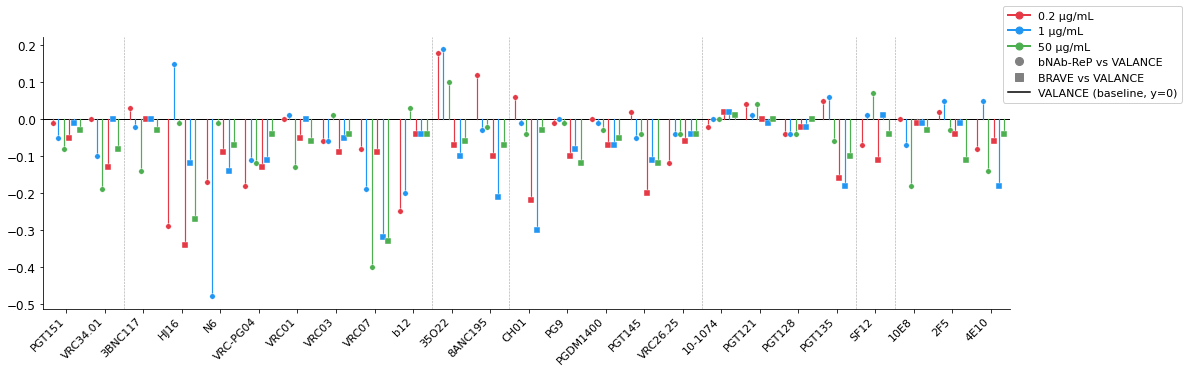

✓ Saved /Users/YUQIAO/blackbox/VALANCE/plots/lollipop_vs_valance_mcc_thr0.2_1.0_50.0.png


In [52]:
"""
Lollipop plot: bNAb-ReP and BRAVE vs VALANCE (benchmark)
- 2 thresholds shown in same panel, differentiated by color
- 2 model comparisons differentiated by marker shape
- y-axis = competitor score − VALANCE score
- 4 metric subpanels
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
DATA_PATH  = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
PLOT_DIR   = "/Users/YUQIAO/blackbox/VALANCE/plots"
SHEET = "Fig_2A"
METRICS    = ["MCC", "ACC", "AUC", "F1"]
THRESHOLDS = [0.2, 1.0, 50.0]
METRIC     = "MCC"   # change to "ACC", "AUC", or "F1"
COL_PREFIX = {"bNAb-ReP": "bNab-rep", "BRAVE": "BRAVE", "VALANCE": "VALANCE"}

# color per threshold, shape per competitor
THR_COLORS   = {0.2: "#E63946", 1.0: "#2196F3", 50.0: "#4CAF50"}
THR_LABELS   = {0.2: "0.2 µg/mL", 1.0: "1 µg/mL", 50.0: "50 µg/mL"}
COMP_MARKERS = {"bNAb-ReP": "o", "BRAVE": "s"}
COMP_LABELS  = {"bNAb-ReP": "bNAb-ReP vs VALANCE", "BRAVE": "BRAVE vs VALANCE"}

EPITOPE_ORDER = [
    "FUSION_PEPTIDE", "GP120_CD4BS", "SUBUNIT_INTERFACE",
    "GP120_V2", "GP120_V3", "GP120_SILENT", "GP41_MPER",
]

EPITOPE_DISPLAY = {
    "FUSION_PEPTIDE":    "Fusion Peptide",
    "GP120_CD4BS":       "CD4BS",
    "SUBUNIT_INTERFACE": "Subunit Interface",
    "GP120_V2":          "V2-Apex",
    "GP120_V3":          "V3-glycan",
    "GP120_SILENT":      "GP120 Silent Face",
    "GP41_MPER":         "MPER",
}


# row slices per threshold in the supplemental sheet
THR_SLICES = {0.2: (0,  26), 1.0: (27, 56), 50.0: (57, None)}


def parse_mean(val):
    try:    return float(str(val).split("(")[0])
    except: return np.nan

def load_threshold(thr):
    raw = pd.read_excel(XLSX_PATH, sheet_name="Fig_2A", header=1)
    raw = raw.iloc[:, :14]
    raw.columns = [
        "Antibody", "Threshold",
        "bNab-rep MCC", "bNab-rep ACC", "bNab-rep AUC", "bNab-rep F1",
        "BRAVE MCC",    "BRAVE ACC",    "BRAVE AUC",    "BRAVE F1",
        "VALANCE MCC",  "VALANCE ACC",  "VALANCE AUC",  "VALANCE F1",
    ]
    raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")
    raw = raw[raw["Antibody"].notna() & (raw["Antibody"] != "Number of Wins")]
    sub = raw[raw["Threshold"] == thr].copy().reset_index(drop=True)
    for metric in METRICS:
        for model in ["bNAb-ReP", "BRAVE", "VALANCE"]:
            col = f"{COL_PREFIX[model]} {metric}"
            sub[f"{model}_{metric}"] = [parse_mean(v) for v in sub[col].tolist()]
    return sub

subs = {thr: load_threshold(thr) for thr in THRESHOLDS}

# Sort antibodies by epitope (use thr=1.0 antibody list as reference) 
df_meta     = pd.read_csv(DATA_PATH, sep="\t")
epitope_map = (df_meta[["Antibody", "epitope"]].drop_duplicates()
               .set_index("Antibody")["epitope"].str.strip().to_dict())

EPITOPE_MERGE = {
    "GP41-GP120_INTERFACE": "SUBUNIT_INTERFACE",
    "GP41-GP41_INTERFACE":  "SUBUNIT_INTERFACE",
}
def merged_epitope(ab):
    epi = epitope_map.get(ab, "")
    return EPITOPE_MERGE.get(epi, epi)

ref_sub = subs[THRESHOLDS[0]]
def epi_key(ab):
    epi = merged_epitope(ab)
    idx = EPITOPE_ORDER.index(epi) if epi in EPITOPE_ORDER else len(EPITOPE_ORDER)
    return (idx, ab)

antibodies     = sorted(ref_sub["Antibody"].tolist(), key=epi_key)
epitope_labels = [EPITOPE_DISPLAY.get(merged_epitope(ab), merged_epitope(ab))
                  for ab in antibodies]
n_ab           = len(antibodies)
x              = np.arange(n_ab)

# Plot 
competitors = ["bNAb-ReP", "BRAVE"]
n_series    = len(THRESHOLDS) * len(competitors)   # 4 lollipops per antibody
spacing     = 0.14
# offsets: (bNAb-ReP thr0.2), (bNAb-ReP thr1.0), (BRAVE thr0.2), (BRAVE thr1.0)
offsets = np.linspace(-(n_series-1)/2, (n_series-1)/2, n_series) * spacing

fig, ax = plt.subplots(1, 1, figsize=(17, 5))
fig.subplots_adjust(left=0.06, right=0.85)

for metric in [METRIC]:
    for xi, ab in enumerate(antibodies):
        series_idx = 0
        for comp in competitors:
            for thr in THRESHOLDS:
                sub  = subs[thr]
                rows = sub[sub["Antibody"] == ab]
                if rows.empty:
                    series_idx += 1
                    continue
                row   = rows.iloc[0]
                val_v = row[f"VALANCE_{metric}"]
                val_c = row[f"{comp}_{metric}"]
                if pd.isna(val_v) or pd.isna(val_c):
                    series_idx += 1
                    continue

                diff  = val_c - val_v
                xpos  = xi + offsets[series_idx]
                color = THR_COLORS[thr]
                marker = COMP_MARKERS[comp]

                ax.plot([xpos, xpos], [0, diff], color=color,
                        linewidth=1.2, zorder=2)
                ax.scatter(xpos, diff, color=color, s=30, zorder=3,
                           marker=marker, edgecolors="white", linewidths=0.4)
                series_idx += 1

    ax.axhline(0, color="black", linewidth=1.0, zorder=1, label="VALANCE")
    # ax.set_ylabel(f"Δ {metric}\n(vs VALANCE)", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)

    # epitope dividers + labels
    prev_epi, group_starts = None, []
    for i, epi in enumerate(epitope_labels):
        if epi != prev_epi:
            if i > 0:
                ax.axvline(i - 0.5, color="#AAAAAA", linewidth=0.6,
                           linestyle="--", zorder=0)
            group_starts.append((i, epi))
            prev_epi = epi

    ytop = ax.get_ylim()[1]
    for idx, (start, epi) in enumerate(group_starts):
        end = group_starts[idx+1][0] if idx+1 < len(group_starts) else n_ab
        mid = (start + end - 1) / 2
#         ax.text(mid, ytop * 1.1, epi, ha="center", va="top",
#                 fontsize=11, color="#555555", style="italic",
#                 bbox=dict(facecolor="white", edgecolor="none",
#                           alpha=0.0, pad=0.5))

ax.set_xticks(x)
ax.set_xticklabels(antibodies, rotation=45, ha="right", fontsize=11)
ax.set_xlim(-0.6, n_ab - 0.5)
ax.tick_params(axis="y", labelsize=12)

# Legend 
thr_handles = [
    mlines.Line2D([0],[0], color=THR_COLORS[t], linewidth=2,
                  marker="o", markersize=7, label=THR_LABELS[t])
    for t in THRESHOLDS
]
comp_handles = [
    mlines.Line2D([0],[0], color="gray", linewidth=0, marker=COMP_MARKERS[c],
                  markersize=8, label=COMP_LABELS[c])
    for c in competitors
]
baseline = mlines.Line2D([0],[0], color="black", linewidth=1.5,
                         label="VALANCE (baseline, y=0)")

fig.legend(handles=thr_handles + comp_handles + [baseline],
           loc="upper right", fontsize=11, frameon=True,
           framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(0.995, 0.98),
           title_fontsize=11)


out = f"{PLOT_DIR}/lollipop_vs_valance_{METRIC.lower()}_thr0.2_1.0_50.0.png"
plt.savefig(out, bbox_inches="tight", dpi=800)
plt.show()
print(f"✓ Saved {out}")

# Fig2C


Within-epitope model comparison — MCC

  Threshold 0.2 µg/mL:
    GP120_CD4BS (n=8): Friedman p=0.0202 *
         bNAb-ReP vs BRAVE: p_adj=1.0000
         bNAb-ReP vs VALANCE: p_adj=0.0840
         BRAVE vs VALANCE: p_adj=0.0533
    GP120_V2 (n=5): Friedman p=0.0759
    GP120_V3 (n=4): Friedman p=0.9355
    GP41_MPER (n=3): Friedman p=0.3067

  Threshold 1 µg/mL:
    GP120_CD4BS (n=8): Friedman p=0.0753
    GP120_V2 (n=5): Friedman p=0.0111 *
         bNAb-ReP vs BRAVE: p_adj=0.2037
         bNAb-ReP vs VALANCE: p_adj=0.1968
         BRAVE vs VALANCE: p_adj=0.1875
    GP120_V3 (n=4): Friedman p=0.8187
    GP41_MPER (n=3): Friedman p=0.3679

  Threshold 50 µg/mL:
    GP120_CD4BS (n=8): Friedman p=0.0302 *
         bNAb-ReP vs BRAVE: p_adj=1.0000
         bNAb-ReP vs VALANCE: p_adj=0.3281
         BRAVE vs VALANCE: p_adj=0.0234 *
    GP120_V2 (n=5): Friedman p=0.0156 *
         bNAb-ReP vs BRAVE: p_adj=0.4324
         bNAb-ReP vs VALANCE: p_adj=0.1875
         BRAVE vs VALANCE: p_adj=0.

/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/Users/YUQIAO/opt/anaconda3/lib/

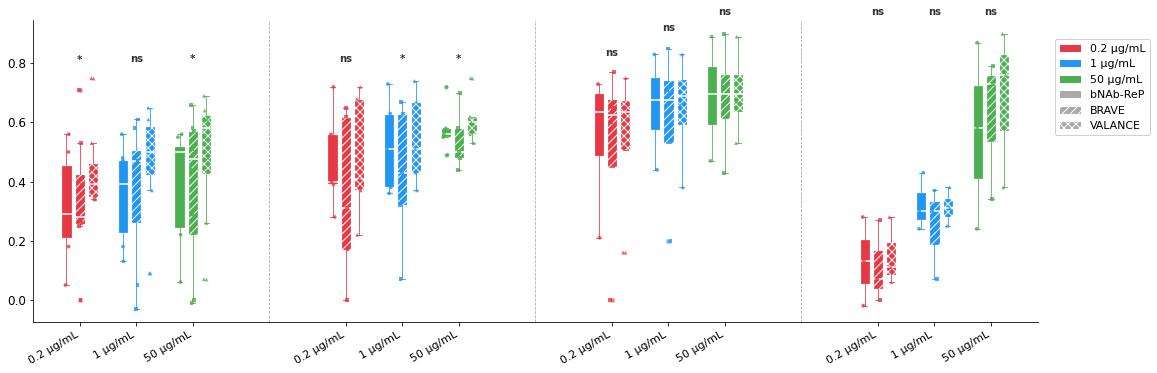

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from itertools import combinations

DATA_PATH = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
XLSX_PATH = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
THRESHOLDS    = [0.2, 1, 50]
METRIC        = "MCC"
EPITOPES_KEEP = ["GP120_CD4BS", "GP120_V2", "GP120_V3", "GP41_MPER"]

EPITOPE_DISPLAY = {
    "GP120_CD4BS": "CD4BS",
    "GP120_V2":    "V2-Apex",
    "GP120_V3":    "V3-glycan",
    "GP41_MPER":   "MPER",
}

# color = threshold, hatch/shape = model
THR_COLORS = {0.2: "#E63946", 1: "#2196F3", 50: "#4CAF50"}
THR_LABELS = {0.2: "0.2 µg/mL", 1: "1 µg/mL", 50: "50 µg/mL"}
MODEL_HATCH  = {"bNAb-ReP": "",    "BRAVE": "///", "VALANCE": "xxx"}
MODEL_MARKER = {"bNAb-ReP": "o",   "BRAVE": "s",   "VALANCE": "^"}
MODELS = {
    "bNAb-ReP": f"bNab-rep {METRIC}",
    "BRAVE":    f"BRAVE {METRIC}",
    "VALANCE":  f"VALANCE {METRIC}",
}
COL_NAMES = [
    "Antibody", "Threshold",
    "bNab-rep MCC", "bNab-rep ACC", "bNab-rep AUC", "bNab-rep F1",
    "BRAVE MCC",    "BRAVE ACC",    "BRAVE AUC",    "BRAVE F1",
    "VALANCE MCC",  "VALANCE ACC",  "VALANCE AUC",  "VALANCE F1",
]

def parse_mean(val):
    try:    return float(str(val).split("(")[0])
    except: return np.nan

raw = pd.read_excel(XLSX_PATH, sheet_name="Fig_2A", header=1)
raw = raw.iloc[:, :14]
raw.columns = COL_NAMES
raw = raw[raw["Antibody"].notna() & (raw["Antibody"] != "Number of Wins")].copy()
raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")

for col in MODELS.values():
    raw[col] = raw[col].apply(parse_mean)

df_raw = pd.read_csv(DATA_PATH, sep="\t")
epitope_map = (df_raw[["Antibody", "epitope"]].drop_duplicates()
               .set_index("Antibody")["epitope"].str.strip().to_dict())
raw["Epitope"] = raw["Antibody"].map(epitope_map)
raw = raw[raw["Epitope"].isin(EPITOPES_KEEP)]

epitopes = [e for e in EPITOPES_KEEP if e in raw["Epitope"].unique()]
n_epi    = len(epitopes)
pairs    = list(combinations(MODELS.keys(), 2))
n_pairs  = len(pairs)

# Stats: same threshold across 3 models (within each epitope)
print(f"\n{'='*70}")
print(f"Within-epitope model comparison — {METRIC}")
print(f"{'='*70}")

stat_results = {}
for thr in THRESHOLDS:
    sub = raw[raw["Threshold"] == thr]
    print(f"\n  Threshold {thr} µg/mL:")
    for epi in epitopes:
        epi_sub = sub[sub["Epitope"] == epi].dropna(subset=list(MODELS.values()))
        if len(epi_sub) < 3:
            print(f"    {epi}: insufficient data (n={len(epi_sub)}), skipping")
            continue
        data_mat = epi_sub[list(MODELS.values())].values
        try:    f_stat, f_p = stats.friedmanchisquare(*data_mat.T)
        except: f_p = np.nan
        f_str    = f"{f_p:.4f}" if not np.isnan(f_p) and f_p >= 0.0001 else "<0.0001"
        sig_flag = " *" if (not np.isnan(f_p) and f_p < 0.05) else ""
        print(f"    {epi} (n={len(epi_sub)}): Friedman p={f_str}{sig_flag}")
        wilcoxon_res = {}
        if not np.isnan(f_p) and f_p < 0.05:
            for m1, m2 in pairs:
                d = epi_sub[[MODELS[m1], MODELS[m2]]].dropna()
                if len(d) < 3: continue
                try:    _, w_p = stats.wilcoxon(d[MODELS[m1]], d[MODELS[m2]])
                except: w_p = np.nan
                w_adj = min(w_p * n_pairs, 1.0) if not np.isnan(w_p) else np.nan
                wilcoxon_res[(m1, m2)] = w_adj
                adj_str = f"{w_adj:.4f}" if not np.isnan(w_adj) else "N/A"
                flag    = " *" if (not np.isnan(w_adj) and w_adj < 0.05) else ""
                print(f"         {m1} vs {m2}: p_adj={adj_str}{flag}")
        stat_results[(epi, thr)] = {"friedman_p": f_p, "wilcoxon": wilcoxon_res}

# Stats: pairwise comparison of adjacent cutoffs within each epitope
print(f"\n{'='*70}")
print(f"Within-epitope adjacent-threshold comparison — {METRIC}")
print(f"{'='*70}")

ADJACENT_PAIRS = [(0.2, 1), (1, 50)]
thr_stat_results = {}   # (epi, model, t1, t2) -> p_adj

for epi in epitopes:
    print(f"\n  Epitope: {epi}")
    for model, metric_col in MODELS.items():
        # common antibodies across all thresholds
        abs_per_thr = []
        for thr in THRESHOLDS:
            sub = raw[(raw["Threshold"] == thr) & (raw["Epitope"] == epi)]
            abs_per_thr.append(set(sub["Antibody"].dropna()))
        common_abs = sorted(abs_per_thr[0] & abs_per_thr[1] & abs_per_thr[2])
        if len(common_abs) < 3:
            continue
        for t1, t2 in ADJACENT_PAIRS:
            s1 = (raw[(raw["Threshold"] == t1) & (raw["Epitope"] == epi)]
                  .set_index("Antibody").reindex(common_abs)[metric_col].values)
            s2 = (raw[(raw["Threshold"] == t2) & (raw["Epitope"] == epi)]
                  .set_index("Antibody").reindex(common_abs)[metric_col].values)
            try:
                _, w_p = stats.wilcoxon(s1, s2)
            except:
                w_p = np.nan
            w_adj = min(w_p * len(ADJACENT_PAIRS), 1.0) if not np.isnan(w_p) else np.nan
            thr_stat_results[(epi, model, t1, t2)] = w_adj
            p_str = f"{w_adj:.4f}" if not np.isnan(w_adj) and w_adj >= 0.0001 else "<0.0001"
            sig   = " *" if not np.isnan(w_adj) and w_adj < 0.05 else ""
            print(f"    {model} | {t1} vs {t2} (n={len(common_abs)}): p_adj={p_str}{sig}")
        
# Plot 
n_models  = len(MODELS)
box_w     = 0.18
model_gap = 0.20
thr_gap   = 0.85
epi_gap   = 4.0

def group_center(epi_idx, thr_idx):
    return epi_idx * epi_gap + thr_idx * thr_gap

def box_x(epi_idx, thr_idx, model_idx):
    center  = group_center(epi_idx, thr_idx)
    offsets = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * model_gap
    return center + offsets[model_idx]

def sig_stars(p):
    if p is None or np.isnan(p): return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

fig, ax = plt.subplots(figsize=(max(18, n_epi * epi_gap * 1.1), 6))
fig.subplots_adjust(bottom=0.18)

xtick_pos, xtick_labels = [], []

for ei, epi in enumerate(epitopes):
    # epitope label above the middle threshold group
    mid_gc = group_center(ei, 1)

    for ti, thr in enumerate(THRESHOLDS):
        gc = group_center(ei, ti)
        xtick_pos.append(gc)
        xtick_labels.append(THR_LABELS[thr])

        sub = raw[raw["Threshold"] == thr]
        for mi, (model, metric_col) in enumerate(MODELS.items()):
            vals = sub.loc[sub["Epitope"] == epi, metric_col].dropna().values
            if len(vals) == 0:
                continue
            xpos  = box_x(ei, ti, mi)
            color = THR_COLORS[thr]
            hatch = MODEL_HATCH[model]

            ax.boxplot(vals, positions=[xpos], widths=box_w * 0.85,
                       patch_artist=True, notch=False,
                       medianprops=dict(color="white", linewidth=1.5),
                       whiskerprops=dict(color=color, linewidth=0.8),
                       capprops=dict(color=color, linewidth=0.8),
                       flierprops=dict(marker=MODEL_MARKER[model], markersize=4,
                                       markerfacecolor=color,
                                       markeredgecolor="none", alpha=0.7),
                       boxprops=dict(facecolor=color, edgecolor="white",
                                     linewidth=1.2, hatch=hatch))
            jitter = np.random.uniform(-box_w * 0.2, box_w * 0.2, len(vals))
            ax.scatter(xpos + jitter, vals, color=color, s=14, alpha=0.8,
                       zorder=4, edgecolors="none", marker=MODEL_MARKER[model])

        # Friedman stars above each threshold group
        res   = stat_results.get((epi, thr), {})
        f_p   = res.get("friedman_p", np.nan)
        stars = sig_stars(f_p)
        if stars:
            ax.text(gc, ax.get_ylim()[1] * 1.01, stars,
                    ha="center", va="bottom", fontsize=10, color="#333333", fontweight="bold")

    # epitope divider between groups
    if ei < n_epi - 1:
        divx = (group_center(ei, len(THRESHOLDS)-1) +
                group_center(ei+1, 0)) / 2
        ax.axvline(divx, color="#AAAAAA", linewidth=0.8, linestyle="--", zorder=0)

    # epitope label above boxes
    ymax = ax.get_ylim()[1]
    left  = group_center(ei, 0) - thr_gap * 0.5
    right = group_center(ei, len(THRESHOLDS)-1) + thr_gap * 0.5
#     ax.text((left + right) / 2, ymax * 1.07, EPITOPE_DISPLAY.get(epi, epi),
#             ha="center", va="bottom", fontsize=11,
#             fontweight="bold", color="#333333",
#                 bbox=dict(facecolor="white", edgecolor="none",
#                           alpha=0.0, pad=0.5))

ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, rotation=30, ha="right", fontsize=11)
# ax.set_ylabel(METRIC, fontsize=11)
# ax.set_title(f"{METRIC} by Epitope Group", fontsize=12,
#              fontweight="bold", pad=30)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=12)

# legend: threshold colors + model hatches/shapes
thr_handles = [mpatches.Patch(facecolor=THR_COLORS[t], edgecolor="white",
                               label=THR_LABELS[t]) for t in THRESHOLDS]
model_handles = [mpatches.Patch(facecolor="#AAAAAA", edgecolor="white",
                                 hatch=MODEL_HATCH[m], label=m)
                 for m in MODELS]
fig.legend(handles= thr_handles+model_handles,
           loc="lower center", ncol=1, fontsize=11,
           framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(0.95, 0.60))

# fig.text(0.5, -0.00,
#          "* p<0.05, ** p<0.01, *** p<0.001 (Friedman test across 3 models within epitope × threshold)",
#          ha="center", fontsize=12, color="#333333")

plt.savefig(
    f"/Users/YUQIAO/blackbox/VALANCE/plots/{METRIC.lower()}_by_epitope.png",
    bbox_inches="tight", dpi=800)
plt.show()

# Fig3A

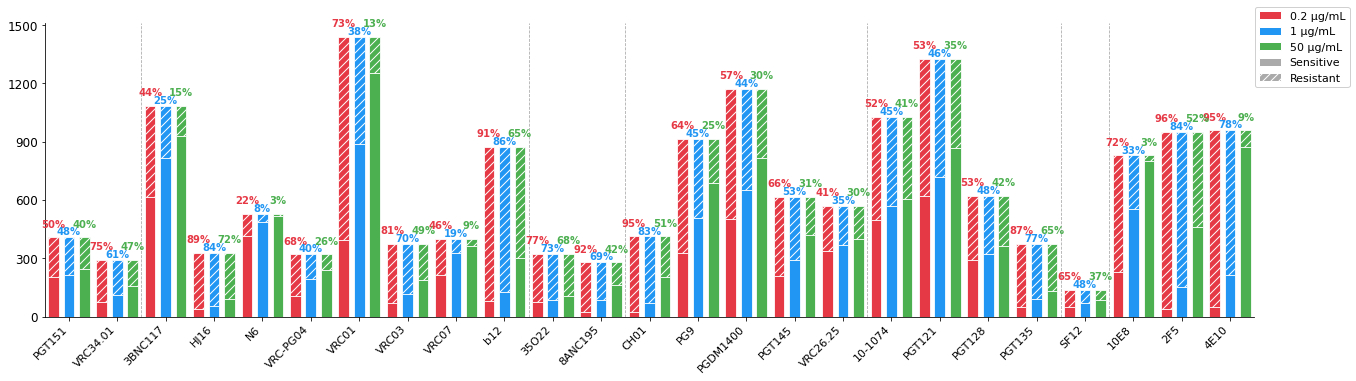

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

DATA_PATH       = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
ANTIBODIES_LIST = ['PGT121', 'VRC01', '10-1074', 'PGT145', '3BNC117', 'PGDM1400',
                   'VRC26.25', 'PGT151', 'PG9', '4E10', 'PGT128', 'SF12', 'N6',
                   '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 'VRC34.01',
                   'b12', 'VRC03', 'VRC07', '2F5', '8ANC195']
THRESHOLDS = [0.2, 1, 50]

# color = threshold, hatch = sensitive vs resistant
THR_COLORS   = {0.2: "#E63946", 1: "#2196F3", 50: "#4CAF50"}
THR_LABELS   = {0.2: "0.2 µg/mL", 1: "1 µg/mL", 50: "50 µg/mL"}
SENS_HATCH   = ""       # solid fill for sensitive
RESIST_HATCH = "///"    # diagonal hatch for resistant

# EPITOPE_ORDER = [
#     "FUSION_PEPTIDE", "GP120_CD4BS", "GP41-GP120_INTERFACE",
#     "GP120_V2", "GP41-GP41_INTERFACE", "GP120_V3",
#     "GP120_SILENT", "GP41_MPER",
# ]


# Build counts_df 
df = pd.read_csv(DATA_PATH, sep="\t")
df["IC50"] = pd.to_numeric(df["IC50"], errors="coerce")

rows = []
for ab in ANTIBODIES_LIST:
    valid = df.loc[df["Antibody"] == ab, "IC50"].dropna()
    row   = {"Antibody": ab}
    for thr in THRESHOLDS:
        row[f"Sensitive (thr={thr})"] = (valid < thr).sum()
        row[f"Resistant (thr={thr})"] = (valid >= thr).sum()
    rows.append(row)
counts_df = pd.DataFrame(rows).set_index("Antibody")

# Sort antibodies by epitope
epitope_map = (df[["Antibody", "epitope"]].drop_duplicates()
               .set_index("Antibody")["epitope"].str.strip().to_dict())

EPITOPE_ORDER = [
    "FUSION_PEPTIDE", "GP120_CD4BS", "SUBUNIT_INTERFACE",
    "GP120_V2", "GP120_V3", "GP120_SILENT", "GP41_MPER",
]

EPITOPE_MERGE = {
    "GP41-GP120_INTERFACE": "SUBUNIT_INTERFACE",
    "GP41-GP41_INTERFACE":  "SUBUNIT_INTERFACE",
}
def merged_epitope(ab):
    epi = epitope_map.get(ab, "")
    return EPITOPE_MERGE.get(epi, epi)

EPITOPE_DISPLAY = {
    "FUSION_PEPTIDE":    "Fusion Peptide",
    "GP120_CD4BS":       "CD4BS",
    "SUBUNIT_INTERFACE": "Subunit Interface",
    "GP120_V2":          "V2-Apex",
    "GP120_V3":          "V3-glycan",
    "GP120_SILENT":      "GP120 Silent Face",
    "GP41_MPER":         "MPER",
}


def epitope_sort_key(ab):
    epi = merged_epitope(ab)
    idx = EPITOPE_ORDER.index(epi) if epi in EPITOPE_ORDER else len(EPITOPE_ORDER)
    return (idx, ab)

antibodies     = sorted(ANTIBODIES_LIST, key=epitope_sort_key)

epitope_labels = [EPITOPE_DISPLAY.get(merged_epitope(ab), merged_epitope(ab)) for ab in antibodies]
counts_df      = counts_df.loc[antibodies]

# Plot 
n_ab    = len(antibodies)
bar_w   = 0.22
n_thr   = len(THRESHOLDS)
offsets = np.linspace(-(n_thr-1)/2, (n_thr-1)/2, n_thr) * (bar_w + 0.10)
x       = np.arange(n_ab)
 
fig, ax = plt.subplots(figsize=(20, 6))
fig.subplots_adjust(bottom=0.2, left=0.04, right=0.88)
 
for ti, thr in enumerate(THRESHOLDS):
    sens    = counts_df[f"Sensitive (thr={thr})"].values
    resist  = counts_df[f"Resistant (thr={thr})"].values
    total   = sens + resist
    pct_res = np.where(total > 0, resist / total * 100, 0)
    xpos    = x + offsets[ti]
    color   = THR_COLORS[thr]
 
    # sensitive: solid fill
    ax.bar(xpos, sens, width=bar_w, color=color,
           hatch=SENS_HATCH, edgecolor="white", linewidth=0.8, zorder=2)
    # resistant: hatched fill
    ax.bar(xpos, resist, width=bar_w, color=color,
           bottom=sens, hatch=RESIST_HATCH, edgecolor="white", linewidth=0.8, zorder=2)
 
    # % resistant annotation — alternate up/down per threshold group
    for i, (s, r, p) in enumerate(zip(sens, resist, pct_res)):
        if (s + r) > 0:
            offset = 42 if ti % 2 == 0 else 2
            ax.text(xpos[i], s + r + offset, f"{p:.0f}%",
                    ha="center", va="bottom",
                    fontsize=10, fontweight="bold", color=color)

# epitope dividers + labels
prev_epi, group_starts = None, []
for i, epi in enumerate(epitope_labels):
    if epi != prev_epi:
        if i > 0:
            ax.axvline(i - 0.5, color="#AAAAAA", linewidth=0.8,
                       linestyle="--", zorder=0)
        group_starts.append((i, epi))
        prev_epi = epi

ymax = ax.get_ylim()[1]
for idx, (start, epi) in enumerate(group_starts):
    end = group_starts[idx+1][0] if idx+1 < len(group_starts) else n_ab
    mid = (start + end - 1) / 2
#     ax.text(mid, ymax * 1.07, epi, ha="center", va="top",
#             fontsize=13, color="#555555", style="italic",
#             bbox=dict(facecolor="white", edgecolor="none", alpha=0.0, pad=1))

ax.set_xticks(x)
ax.set_xticklabels(antibodies, rotation=45, ha="right", fontsize=11)
# ax.set_ylabel("Count", fontsize=11)
ax.yaxis.set_label_coords(-0.02, 0.5)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=6))
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.set_xlim(-0.5, n_ab - 0.5)
ax.tick_params(axis="y", labelsize=12)

# legend: threshold colors + sens/resist hatches
thr_handles = [mpatches.Patch(facecolor=THR_COLORS[t], edgecolor="white",
                               label=THR_LABELS[t]) for t in THRESHOLDS]
type_handles = [
    mpatches.Patch(facecolor="#AAAAAA", edgecolor="white",
                   hatch=SENS_HATCH,   label="Sensitive"),
    mpatches.Patch(facecolor="#AAAAAA", edgecolor="white",
                   hatch=RESIST_HATCH, label="Resistant"),
]
fig.legend(handles=thr_handles + type_handles,
           loc="upper right", fontsize=11, ncol=1,
           frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(0.95, 0.93))


plt.savefig("/Users/YUQIAO/blackbox/VALANCE/plots/valance_label_ratio_plot.png",
            bbox_inches="tight", dpi=800)
plt.show()

# Fig3B


Fisher's z-test on |ρ|: VALANCE vs other models (MCC ~ Imbalance)
H0: |ρ_VALANCE| == |ρ_other|  (equal sensitivity to imbalance)

  Threshold 0.2 µg/mL:
    VALANCE (|ρ|=0.695) vs bNAb-ReP (|ρ|=0.753): z=-0.402, p=0.688
    VALANCE (|ρ|=0.695) vs BRAVE (|ρ|=0.703): z=-0.047, p=0.963

  Threshold 1 µg/mL:
    VALANCE (|ρ|=0.525) vs bNAb-ReP (|ρ|=0.670): z=-0.755, p=0.450
    VALANCE (|ρ|=0.525) vs BRAVE (|ρ|=0.582): z=-0.275, p=0.783

  Threshold 50 µg/mL:
    VALANCE (|ρ|=0.256) vs bNAb-ReP (|ρ|=0.446): z=-0.724, p=0.469
    VALANCE (|ρ|=0.256) vs BRAVE (|ρ|=0.350): z=-0.345, p=0.730


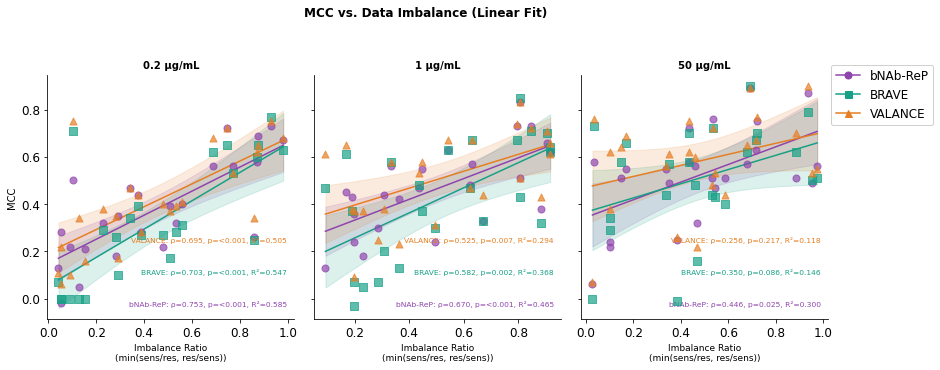

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


DATA_PATH       = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
ANTIBODIES_LIST = ['PGT121', 'VRC01', '10-1074', 'PGT145', '3BNC117', 'PGDM1400',
                   'VRC26.25', 'PGT151', 'PG9', '4E10', 'PGT128', 'SF12', 'N6',
                   '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 'VRC34.01',
                   'b12', 'VRC03', 'VRC07', '2F5', '8ANC195']

# Build counts_df 
df = pd.read_csv(DATA_PATH, sep="\t")
df["IC50"] = pd.to_numeric(df["IC50"], errors="coerce")

rows = []
for ab in ANTIBODIES_LIST:
    valid = df.loc[df["Antibody"] == ab, "IC50"].dropna()
    row   = {"Antibody": ab}
    for thr in THRESHOLDS:
        row[f"Sensitive (thr={thr})"] = (valid < thr).sum()
        row[f"Resistant (thr={thr})"] = (valid >= thr).sum()
    rows.append(row)
counts_df = pd.DataFrame(rows).set_index("Antibody")


XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
THRESHOLDS = [0.2, 1, 50]
METRIC     = "MCC"      # change to "ACC", "MCC", "AUC", or "F1"
FIT_TYPE   = "linear"  # "linear" or "quadratic"

COLORS = {
    "bNAb-ReP": "#8E44AD",   # purple
    "BRAVE":    "#16A085",   # teal
    "VALANCE":  "#E67E22",   # orange
}
MARKERS = {
    "bNAb-ReP": "o",
    "BRAVE":    "s",
    "VALANCE":  "^",
}

# 1. Load Excel 
COL_NAMES = [
    "Antibody", "Epitope", "Threshold",
    "bNab-rep MCC", "BRAVE MCC",    "VALANCE MCC",
    "bNab-rep ACC", "BRAVE ACC",    "VALANCE ACC",
    "bNab-rep AUC", "BRAVE AUC",    "VALANCE AUC",
    "bNab-rep F1",  "BRAVE F1",     "VALANCE F1",
]

def load_excel():
    frames = []
    for thr in [0.2, 1.0]:
        df = pd.read_excel(XLSX_PATH, sheet_name="Supplemental Table 1",
                           header=None, skiprows=2)
        df = df.iloc[:26, :15] if thr == 0.2 else df.iloc[27:56, :15]
        df.columns = COL_NAMES
        df = df[df["Antibody"].notna() & (df["Antibody"] != "Number of Wins")].copy()
        df["Threshold"] = pd.to_numeric(df["Threshold"], errors="coerce")
        frames.append(df[df["Threshold"] == thr])
    df50 = pd.read_excel(XLSX_PATH, sheet_name="Fig_1c",
                         header=None, skiprows=2)
    df50 = df50.iloc[:, :15]
    df50.columns = COL_NAMES
    df50 = df50[df50["Antibody"].notna() & (df50["Antibody"] != "Number of Wins")].copy()
    df50["Threshold"] = pd.to_numeric(df50["Threshold"], errors="coerce")
    frames.append(df50)
    return pd.concat(frames, ignore_index=True)

raw = load_excel()
# rename columns to match MODELS lookup
for metric in ["MCC", "ACC", "AUC", "F1"]:
    raw[f"bNab-rep {metric}"] = raw[f"bNab-rep {metric}"]
    raw[f"BRAVE {metric}"]    = raw[f"BRAVE {metric}"]
    raw[f"VALANCE {metric}"]  = raw[f"VALANCE {metric}"]

MODELS = {
    "bNAb-ReP": f"bNab-rep {METRIC}",
    "BRAVE":    f"BRAVE {METRIC}",
    "VALANCE":  f"VALANCE {METRIC}",
}

def parse_mean(val):
    try:
        return float(str(val).split("(")[0])
    except:
        return np.nan

for col in MODELS.values():
    raw[col] = raw[col].apply(parse_mean)
raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")

# 2. Compute imbalance ratio 
imbalance_rows = []
for ab in raw["Antibody"].dropna().unique():
    for thr in THRESHOLDS:
        s = counts_df.loc[ab, f"Sensitive (thr={thr})"] if ab in counts_df.index else np.nan
        r = counts_df.loc[ab, f"Resistant (thr={thr})"] if ab in counts_df.index else np.nan
        ratio = min(s / r, r / s) if (s and r) else np.nan
        imbalance_rows.append({"Antibody": ab, "Threshold": thr, "Imbalance": ratio})

imbalance_df = pd.DataFrame(imbalance_rows)
merged = raw.merge(imbalance_df, on=["Antibody", "Threshold"], how="inner")

# 3. Fisher's z-test: compare Spearman |ρ| of VALANCE vs other models
def fisher_z_test_abs(r1, r2, n1, n2):
    """
    Two-tailed Fisher's z-test comparing two independent Spearman correlations.
    Tests H0: |ρ1| == |ρ2|  (i.e. equal sensitivity to imbalance).
    Returns (z_stat, p_value).
    """
    z1 = np.arctanh(abs(r1))
    z2 = np.arctanh(abs(r2))
    se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z_stat = (z1 - z2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return z_stat, p_value

print(f"\n{'='*65}")
print(f"Fisher's z-test on |ρ|: VALANCE vs other models ({METRIC} ~ Imbalance)")
print(f"H0: |ρ_VALANCE| == |ρ_other|  (equal sensitivity to imbalance)")
print(f"{'='*65}")

fisher_results = {}   # store for annotation
for thr in THRESHOLDS:
    sub = merged[merged["Threshold"] == thr].dropna(subset=["Imbalance"])
    print(f"\n  Threshold {thr} µg/mL:")

    rho_valance, _ = stats.spearmanr(
        sub[["Imbalance", MODELS["VALANCE"]]].dropna()["Imbalance"],
        sub[["Imbalance", MODELS["VALANCE"]]].dropna()[MODELS["VALANCE"]]
    )
    n_val = sub[["Imbalance", MODELS["VALANCE"]]].dropna().shape[0]

    fisher_results[thr] = {}
    for model in ["bNAb-ReP", "BRAVE"]:
        d = sub[["Imbalance", MODELS[model]]].dropna()
        rho_other, _ = stats.spearmanr(d["Imbalance"], d[MODELS[model]])
        n_other = len(d)
        z_stat, p_val = fisher_z_test_abs(rho_valance, rho_other, n_val, n_other)
        p_str = f"{p_val:.3f}" if p_val >= 0.001 else "<0.001"
        print(f"    VALANCE (|ρ|={abs(rho_valance):.3f}) vs {model} (|ρ|={abs(rho_other):.3f}): "
              f"z={z_stat:.3f}, p={p_str}")
        fisher_results[thr][model] = (rho_other, p_val)
    fisher_results[thr]["VALANCE_rho"] = rho_valance

# 4. Plot 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fig.subplots_adjust(wspace=0.08)

for ax, thr in zip(axes, THRESHOLDS):
    sub = merged[merged["Threshold"] == thr].dropna(subset=["Imbalance"])

    for i, (model, metric_col) in enumerate(MODELS.items()):
        d = sub[["Imbalance", metric_col]].dropna()
        x, y = d["Imbalance"].values, d[metric_col].values

        ax.scatter(x, y, color=COLORS[model], s=50, alpha=0.69, zorder=3,
                       marker=MARKERS[model])

        if len(x) > 2:
            x_line = np.linspace(x.min(), x.max(), 200)

            if FIT_TYPE == "quadratic":
                coeffs = np.polyfit(x, y, 2)
                y_fit  = np.polyval(coeffs, x_line)
                y_pred = np.polyval(coeffs, x)
                ss_res = np.sum((y - y_pred) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)
                r2     = 1 - ss_res / ss_tot
            else:
                slope, intercept, _, _, _ = stats.linregress(x, y)
                y_fit = slope * x_line + intercept
                r2    = np.corrcoef(x, y)[0, 1] ** 2

            # analytical 95% CI around regression line using prediction interval
            n      = len(x)
            x_mean = x.mean()
            se_line = np.sqrt(
                (np.sum((y - (slope * x + intercept))**2) / (n - 2)) *
                (1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
            )
            t_crit = stats.t.ppf(0.975, df=n - 2)
            ci_lo  = y_fit - t_crit * se_line
            ci_hi  = y_fit + t_crit * se_line

            ax.plot(x_line, y_fit, color=COLORS[model], linewidth=1.5, zorder=2)
            ax.fill_between(x_line, ci_lo, ci_hi,
                            color=COLORS[model], alpha=0.15, zorder=1)

            rho, p = stats.spearmanr(x, y)
            p_str  = f"{p:.3f}" if p >= 0.001 else "<0.001"
            ax.text(0.97, 0.05 + i * 0.13,
                    f"{model}: ρ={rho:.3f}, p={p_str}, R²={r2:.3f}",
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=7.5, color=COLORS[model])

    ax.set_title(f"{thr} µg/mL", fontsize=10, fontweight="bold")
    ax.set_xlabel("Imbalance Ratio\n(min(sens/res, res/sens))", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)


axes[0].set_ylabel(METRIC, fontsize=10)

handles = [plt.Line2D([0], [0], color=COLORS[m], marker=MARKERS[m],
                       markersize=7, linewidth=1.5, label=m)
           for m in COLORS]
fig.legend(handles=handles, loc="upper right", ncol=1, fontsize=12,
           frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(1.01, 0.93))

fit_label = "Quadratic" if FIT_TYPE == "quadratic" else "Linear"
fig.suptitle(f"{METRIC} vs. Data Imbalance ({fit_label} Fit)",
             fontsize=12, fontweight="bold", y=1.09)

plt.savefig(
    f"/Users/YUQIAO/blackbox/VALANCE/plots/{METRIC.lower()}_vs_imbalance_{FIT_TYPE}.png",
    bbox_inches="tight", dpi=500
)
plt.show()

### Remove titles, axis labels for publication


Fisher's z-test on |ρ|: VALANCE vs other models (MCC ~ Imbalance)
H0: |ρ_VALANCE| == |ρ_other|  (equal sensitivity to imbalance)

  Threshold 0.2 µg/mL:
    VALANCE (|ρ|=0.695) vs bNAb-ReP (|ρ|=0.753): z=-0.402, p=0.688
    VALANCE (|ρ|=0.695) vs BRAVE (|ρ|=0.703): z=-0.047, p=0.963

  Threshold 1 µg/mL:
    VALANCE (|ρ|=0.525) vs bNAb-ReP (|ρ|=0.670): z=-0.755, p=0.450
    VALANCE (|ρ|=0.525) vs BRAVE (|ρ|=0.582): z=-0.275, p=0.783

  Threshold 50 µg/mL:
    VALANCE (|ρ|=0.256) vs bNAb-ReP (|ρ|=0.446): z=-0.724, p=0.469
    VALANCE (|ρ|=0.256) vs BRAVE (|ρ|=0.350): z=-0.345, p=0.730


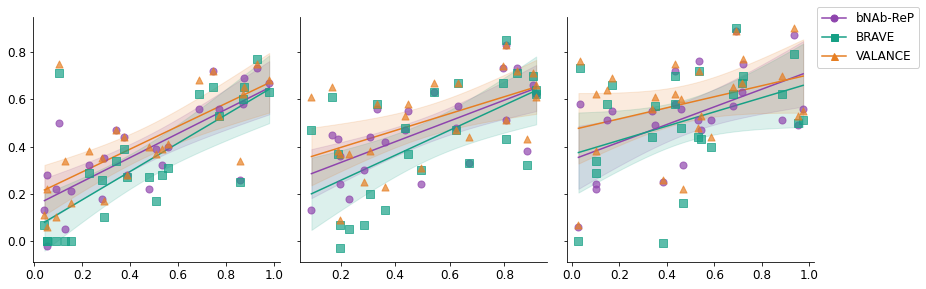

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

DATA_PATH       = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
ANTIBODIES_LIST = ['PGT121', 'VRC01', '10-1074', 'PGT145', '3BNC117', 'PGDM1400',
                   'VRC26.25', 'PGT151', 'PG9', '4E10', 'PGT128', 'SF12', 'N6',
                   '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 'VRC34.01',
                   'b12', 'VRC03', 'VRC07', '2F5', '8ANC195']

# Build counts_df 
df = pd.read_csv(DATA_PATH, sep="\t")
df["IC50"] = pd.to_numeric(df["IC50"], errors="coerce")

rows = []
for ab in ANTIBODIES_LIST:
    valid = df.loc[df["Antibody"] == ab, "IC50"].dropna()
    row   = {"Antibody": ab}
    for thr in THRESHOLDS:
        row[f"Sensitive (thr={thr})"] = (valid < thr).sum()
        row[f"Resistant (thr={thr})"] = (valid >= thr).sum()
    rows.append(row)
counts_df = pd.DataFrame(rows).set_index("Antibody")

XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
THRESHOLDS = [0.2, 1, 50]
METRIC     = "MCC"      # change to "ACC", "MCC", "AUC", or "F1"
FIT_TYPE   = "linear"  # "linear" or "quadratic"

COLORS = {
    "bNAb-ReP": "#8E44AD",   # purple
    "BRAVE":    "#16A085",   # teal
    "VALANCE":  "#E67E22",   # orange
}
MARKERS = {
    "bNAb-ReP": "o",
    "BRAVE":    "s",
    "VALANCE":  "^",
}

# 1. Parse Excel 
COL_NAMES = [
    "Antibody", "Epitope", "Threshold",
    "bNab-rep MCC", "BRAVE MCC",    "VALANCE MCC",
    "bNab-rep ACC", "BRAVE ACC",    "VALANCE ACC",
    "bNab-rep AUC", "BRAVE AUC",    "VALANCE AUC",
    "bNab-rep F1",  "BRAVE F1",     "VALANCE F1",
]

def load_excel():
    frames = []
    for thr in [0.2, 1.0]:
        df = pd.read_excel(XLSX_PATH, sheet_name="Supplemental Table 1",
                           header=None, skiprows=2)
        df = df.iloc[:26, :15] if thr == 0.2 else df.iloc[27:56, :15]
        df.columns = COL_NAMES
        df = df[df["Antibody"].notna() & (df["Antibody"] != "Number of Wins")].copy()
        df["Threshold"] = pd.to_numeric(df["Threshold"], errors="coerce")
        frames.append(df[df["Threshold"] == thr])
    df50 = pd.read_excel(XLSX_PATH, sheet_name="Fig_1c",
                         header=None, skiprows=2)
    df50 = df50.iloc[:, :15]
    df50.columns = COL_NAMES
    df50 = df50[df50["Antibody"].notna() & (df50["Antibody"] != "Number of Wins")].copy()
    df50["Threshold"] = pd.to_numeric(df50["Threshold"], errors="coerce")
    frames.append(df50)
    return pd.concat(frames, ignore_index=True)

raw = load_excel()

# rename columns to match MODELS lookup
for metric in ["MCC", "ACC", "AUC", "F1"]:
    raw[f"bNab-rep {metric}"] = raw[f"bNab-rep {metric}"]
    raw[f"BRAVE {metric}"]    = raw[f"BRAVE {metric}"]
    raw[f"VALANCE {metric}"]  = raw[f"VALANCE {metric}"]

MODELS = {
    "bNAb-ReP": f"bNab-rep {METRIC}",
    "BRAVE":    f"BRAVE {METRIC}",
    "VALANCE":  f"VALANCE {METRIC}",
}

def parse_mean(val):
    try:
        return float(str(val).split("(")[0])
    except:
        return np.nan

for col in MODELS.values():
    raw[col] = raw[col].apply(parse_mean)
raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")

# 2. Compute imbalance ratio 
imbalance_rows = []
for ab in raw["Antibody"].dropna().unique():
    for thr in THRESHOLDS:
        s = counts_df.loc[ab, f"Sensitive (thr={thr})"] if ab in counts_df.index else np.nan
        r = counts_df.loc[ab, f"Resistant (thr={thr})"] if ab in counts_df.index else np.nan
        ratio = min(s / r, r / s) if (s and r) else np.nan
        imbalance_rows.append({"Antibody": ab, "Threshold": thr, "Imbalance": ratio})

imbalance_df = pd.DataFrame(imbalance_rows)
merged = raw.merge(imbalance_df, on=["Antibody", "Threshold"], how="inner")

# 3. Fisher's z-test: compare Spearman |ρ| of VALANCE vs other models
def fisher_z_test_abs(r1, r2, n1, n2):
    """
    Two-tailed Fisher's z-test comparing two independent Spearman correlations.
    Tests H0: |ρ1| == |ρ2|  (i.e. equal sensitivity to imbalance).
    Returns (z_stat, p_value).
    """
    z1 = np.arctanh(abs(r1))
    z2 = np.arctanh(abs(r2))
    se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z_stat = (z1 - z2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return z_stat, p_value

print(f"\n{'='*65}")
print(f"Fisher's z-test on |ρ|: VALANCE vs other models ({METRIC} ~ Imbalance)")
print(f"H0: |ρ_VALANCE| == |ρ_other|  (equal sensitivity to imbalance)")
print(f"{'='*65}")

fisher_results = {}   # store for annotation
for thr in THRESHOLDS:
    sub = merged[merged["Threshold"] == thr].dropna(subset=["Imbalance"])
    print(f"\n  Threshold {thr} µg/mL:")

    rho_valance, _ = stats.spearmanr(
        sub[["Imbalance", MODELS["VALANCE"]]].dropna()["Imbalance"],
        sub[["Imbalance", MODELS["VALANCE"]]].dropna()[MODELS["VALANCE"]]
    )
    n_val = sub[["Imbalance", MODELS["VALANCE"]]].dropna().shape[0]

    fisher_results[thr] = {}
    for model in ["bNAb-ReP", "BRAVE"]:
        d = sub[["Imbalance", MODELS[model]]].dropna()
        rho_other, _ = stats.spearmanr(d["Imbalance"], d[MODELS[model]])
        n_other = len(d)
        z_stat, p_val = fisher_z_test_abs(rho_valance, rho_other, n_val, n_other)
        p_str = f"{p_val:.3f}" if p_val >= 0.001 else "<0.001"
        print(f"    VALANCE (|ρ|={abs(rho_valance):.3f}) vs {model} (|ρ|={abs(rho_other):.3f}): "
              f"z={z_stat:.3f}, p={p_str}")
        fisher_results[thr][model] = (rho_other, p_val)
    fisher_results[thr]["VALANCE_rho"] = rho_valance

# 4. Plot 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fig.subplots_adjust(wspace=0.08)

for ax, thr in zip(axes, THRESHOLDS):
    sub = merged[merged["Threshold"] == thr].dropna(subset=["Imbalance"])

    for i, (model, metric_col) in enumerate(MODELS.items()):
        d = sub[["Imbalance", metric_col]].dropna()
        x, y = d["Imbalance"].values, d[metric_col].values

        ax.scatter(x, y, color=COLORS[model], s=50, alpha=0.69, zorder=3,
                       marker=MARKERS[model])

        if len(x) > 2:
            x_line = np.linspace(x.min(), x.max(), 200)

            if FIT_TYPE == "quadratic":
                coeffs = np.polyfit(x, y, 2)
                y_fit  = np.polyval(coeffs, x_line)
                y_pred = np.polyval(coeffs, x)
                ss_res = np.sum((y - y_pred) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)
                r2     = 1 - ss_res / ss_tot
            else:
                slope, intercept, _, _, _ = stats.linregress(x, y)
                y_fit = slope * x_line + intercept
                r2    = np.corrcoef(x, y)[0, 1] ** 2
      
            # analytical 95% CI around regression line using prediction interval
            n      = len(x)
            x_mean = x.mean()
            se_line = np.sqrt(
                (np.sum((y - (slope * x + intercept))**2) / (n - 2)) *
                (1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
            )
            t_crit = stats.t.ppf(0.975, df=n - 2)
            ci_lo  = y_fit - t_crit * se_line
            ci_hi  = y_fit + t_crit * se_line
            
            

            ax.plot(x_line, y_fit, color=COLORS[model], linewidth=1.5, zorder=2)
            ax.fill_between(x_line, ci_lo, ci_hi,
                            color=COLORS[model], alpha=0.15, zorder=1)

            rho, p = stats.spearmanr(x, y)
            p_str  = f"{p:.3f}" if p >= 0.001 else "<0.001"
#             ax.text(0.97, 0.05 + i * 0.13,
#                     f"{model}: ρ={rho:.3f}, p={p_str}, R²={r2:.3f}",
#                     transform=ax.transAxes, ha="right", va="bottom",
#                     fontsize=7.5, color=COLORS[model])

    # ax.set_title(f"{thr} µg/mL", fontsize=10, fontweight="bold")
    # ax.set_xlabel("Imbalance Ratio\n(min(sens/res, res/sens))", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)


# axes[0].set_ylabel(METRIC, fontsize=10)

handles = [plt.Line2D([0], [0], color=COLORS[m], marker=MARKERS[m],
                       markersize=7, linewidth=1.5, label=m)
           for m in COLORS]
fig.legend(handles=handles, loc="upper right", ncol=1, fontsize=12,
           frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(1.01, 0.93))

fit_label = "Quadratic" if FIT_TYPE == "quadratic" else "Linear"


plt.savefig(
    f"/Users/YUQIAO/blackbox/VALANCE/plots/{METRIC.lower()}_vs_imbalance_{FIT_TYPE}.png",
    bbox_inches="tight", dpi=800
)
plt.show()

# Fig4B

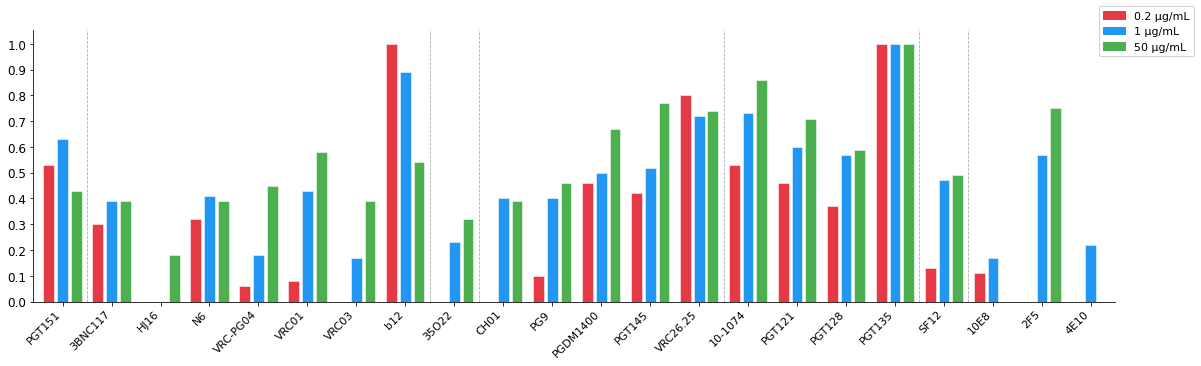

✓ Saved /Users/YUQIAO/blackbox/VALANCE/plots/valance_mcc_barplot.png


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
DATA_PATH  = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
METRIC     = "MCC"    # "MCC", "ACC", "AUC", "F1"
MODEL      = "VALANCE"  # "VALANCE", "BRAVE", "bNAb-ReP"
THRESHOLDS = [0.2, 1, 50]
# THR_COLORS = {0.2: "#117A65", 1: "#B7950B", 50: "#922B21"}
THR_COLORS = {0.2: "#E63946", 1: "#2196F3", 50: "#4CAF50"}
THR_LABELS = {0.2: "0.2 µg/mL", 1: "1 µg/mL", 50: "50 µg/mL"}


MODEL_COL_PREFIX = {
    "VALANCE":  "VALANCE",
    "BRAVE":    "BRAVE",
    "bNAb-ReP": "bNab-rep",
}
col_prefix = MODEL_COL_PREFIX[MODEL]

# Load Excel 
COL_NAMES = [
    "Antibody", "Epitope", "Threshold",
    "Number of training strains", "Number of prediction strains",
    "bNab-rep MCC", "BRAVE MCC",    "VALANCE MCC",
    "bNab-rep ACC", "BRAVE ACC",    "VALANCE ACC",
    "bNab-rep AUC", "BRAVE AUC",    "VALANCE AUC",
]

def clean(df):
    df = df.iloc[:, :14].copy()
    df.columns = COL_NAMES
    df = df[df["Antibody"].notna() & (df["Antibody"] != "Number of Wins")].copy()
    df = df[~df["Antibody"].isin(["VRC07", "VRC34.01", "8ANC195"])] 
    df["Threshold"] = pd.to_numeric(df["Threshold"], errors="coerce")
    return df

df1  = pd.read_excel(XLSX_PATH, sheet_name="Supplemental Table 3", header=None, skiprows=2)
df02 = pd.read_excel(XLSX_PATH, sheet_name="Supplemental Table 3", header=None, skiprows=2)
df50 = pd.read_excel(XLSX_PATH, sheet_name="Fig_4A",               header=None, skiprows=2)

raw = pd.concat([
    clean(df02.iloc[27:56]),   # thr=0.2
    clean(df1.iloc[:26]),      # thr=1.0
    clean(df50),               # thr=50
], ignore_index=True)


def parse_mean(val):
    try:    return float(str(val).split("(")[0])
    except: return np.nan

def parse_std(val):
    try:    return float(str(val).split("(")[1].rstrip(")")) if "(" in str(val) else np.nan
    except: return np.nan

target_col = f"{col_prefix} {METRIC}"
vals = raw[target_col].tolist()
raw[f"{MODEL}_{METRIC}_mean"] = [parse_mean(v) for v in vals]
raw[f"{MODEL}_{METRIC}_std"]  = [parse_std(v)  for v in vals]

# 2. Build plot data 
df_meta = pd.read_csv(DATA_PATH, sep="\t")
epitope_map = (df_meta[["Antibody", "epitope"]].drop_duplicates()
               .set_index("Antibody")["epitope"]
               .str.strip().to_dict())

all_abs = raw["Antibody"].dropna().unique().tolist()
try:
    all_abs = [ab for ab in ANTIBODIES_LIST if ab in all_abs]
except NameError:
    pass

EPITOPE_ORDER = [
    "FUSION_PEPTIDE", "GP120_CD4BS", "SUBUNIT_INTERFACE",
    "GP120_V2", "GP120_V3", "GP120_SILENT", "GP41_MPER",
]

EPITOPE_MERGE = {
    "GP41-GP120_INTERFACE": "SUBUNIT_INTERFACE",
    "GP41-GP41_INTERFACE":  "SUBUNIT_INTERFACE",
}
def merged_epitope(ab):
    epi = epitope_map.get(ab, "")
    return EPITOPE_MERGE.get(epi, epi)

EPITOPE_DISPLAY = {
    "FUSION_PEPTIDE":    "Fusion Peptide",
    "GP120_CD4BS":       "CD4BS",
    "SUBUNIT_INTERFACE": "Subunit Interface",
    "GP120_V2":          "V2-Apex",
    "GP120_V3":          "V3-glycan",
    "GP120_SILENT":      "GP120 Silent Face",
    "GP41_MPER":         "MPER",
}

all_abs = raw["Antibody"].dropna().unique().tolist()
try:
    all_abs = [ab for ab in ANTIBODIES_LIST if ab in all_abs]
except NameError:
    pass


def epitope_sort_key(ab):
    epi = merged_epitope(ab)
    idx = EPITOPE_ORDER.index(epi) if epi in EPITOPE_ORDER else len(EPITOPE_ORDER)
    return (idx, ab)

antibodies    = sorted(all_abs, key=epitope_sort_key)
epitope_labels = [EPITOPE_DISPLAY.get(merged_epitope(ab), merged_epitope(ab)) for ab in antibodies]


n_ab  = len(antibodies)
bar_w = 0.22
offsets = np.linspace(-(len(THRESHOLDS)-1)/2, (len(THRESHOLDS)-1)/2,
                      len(THRESHOLDS)) * (bar_w + 0.06)
x = np.arange(n_ab)

# 3. Plot 
fig, ax = plt.subplots(figsize=(18, 5))
fig.subplots_adjust(left=0.025, right=0.86)

for ti, thr in enumerate(THRESHOLDS):
    sub   = raw[raw["Threshold"] == thr].set_index("Antibody")
    means = np.array([sub.loc[ab, f"{MODEL}_{METRIC}_mean"]
                      if ab in sub.index else np.nan for ab in antibodies])
    xpos  = x + offsets[ti]

    ax.bar(xpos, means, width=bar_w, color=THR_COLORS[thr],
           zorder=2, edgecolor="white", linewidth=0.5)


ax.set_xticks(x)
ax.set_xticklabels(antibodies, rotation=45, ha="right", fontsize=11)
ax.tick_params(axis="y", labelsize=12)

# vertical dividers + epitope group labels
prev_epi, group_starts = None, []
for i, epi in enumerate(epitope_labels):
    if epi != prev_epi:
        if i > 0:
            ax.axvline(i - 0.5, color="#AAAAAA", linewidth=0.8,
                       linestyle="--", zorder=0)
        group_starts.append((i, epi))
        prev_epi = epi

ymax = ax.get_ylim()[1]
for idx, (start, epi) in enumerate(group_starts):
    end = group_starts[idx+1][0] if idx+1 < len(group_starts) else len(antibodies)
    mid = (start + end - 1) / 2
#     ax.text(mid, ymax * 1.02, epi, ha="center", va="top",
#             fontsize=13, color="#555555", style="italic",
#             bbox=dict(facecolor="white", edgecolor="none", alpha=0.0, pad=1))

# ax.set_ylabel(f"{MODEL} {METRIC}", fontsize=13)
ax.yaxis.set_label_coords(-0.03, 0.5)
ax.set_ylim(0, None)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xlim(-0.6, len(antibodies) - 0.5)

fig.legend(
    [plt.Rectangle((0,0),1,1, color=THR_COLORS[t]) for t in THRESHOLDS],
    [THR_LABELS[t] for t in THRESHOLDS],fontsize=11, 
    frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
    loc="upper right", bbox_to_anchor=(0.925, 0.96))


out = f"/Users/YUQIAO/blackbox/VALANCE/plots/{MODEL.lower().replace('-','_')}_{METRIC.lower()}_barplot.png"
plt.savefig(out, bbox_inches="tight", dpi=800)
plt.show()
print(f"✓ Saved {out}")

# Fig4C

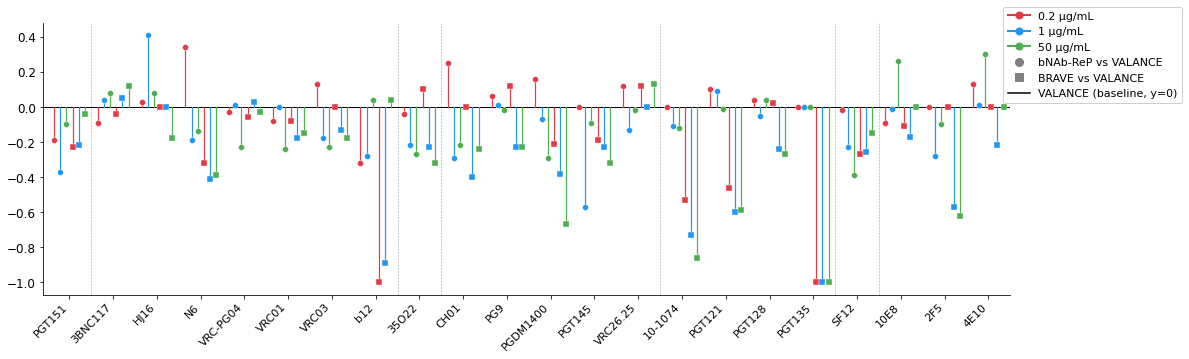

✓ Saved /Users/YUQIAO/blackbox/VALANCE/plots/lollipop_fig4a_mcc_thr0.2_1.0.png


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
DATA_PATH  = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
METRIC     = "MCC"    # "MCC", "ACC", "AUC"

THRESHOLDS = [0.2, 1, 50]
THR_COLORS = {0.2: "#E63946", 1: "#2196F3", 50: "#4CAF50"}
THR_LABELS = {0.2: "0.2 µg/mL", 1: "1 µg/mL", 50: "50 µg/mL"}


COMP_MARKERS = {"bNAb-ReP": "o", "BRAVE": "s"}
COMP_LABELS  = {"bNAb-ReP": "bNAb-ReP vs VALANCE", "BRAVE": "BRAVE vs VALANCE"}

COL_NAMES = [
    "Antibody", "Epitope", "Threshold",
    "Number of training strains", "Number of prediction strains",
    "bNab-rep MCC", "BRAVE MCC",    "VALANCE MCC",
    "bNab-rep ACC", "BRAVE ACC",    "VALANCE ACC",
    "bNab-rep AUC", "BRAVE AUC",    "VALANCE AUC",
]

def clean(df):
    df = df.iloc[:, :14].copy()
    df.columns = COL_NAMES
    df = df[df["Antibody"].notna() & (df["Antibody"] != "Number of Wins")].copy()
    df = df[~df["Antibody"].isin(["VRC07", "VRC34.01", "8ANC195"])]
    df["Threshold"] = pd.to_numeric(df["Threshold"], errors="coerce")
    return df

def parse_mean(val):
    try:    return float(str(val).split("(")[0])
    except: return np.nan

# Load data 

df1  = pd.read_excel(XLSX_PATH, sheet_name="Supplemental Table 3",
                     header=None, skiprows=2)
df02 = pd.read_excel(XLSX_PATH, sheet_name="Supplemental Table 3",
                     header=None, skiprows=2)
df50 = pd.read_excel(XLSX_PATH, sheet_name="Fig_4A",
                     header=None, skiprows=2)
raw = pd.concat([
    clean(df02.iloc[27:56]),   # thr=0.2
    clean(df1.iloc[:26]),      # thr=1.0
    clean(df50),               # thr=50
], ignore_index=True)

for col in [f"bNab-rep {METRIC}", f"BRAVE {METRIC}", f"VALANCE {METRIC}"]:
    raw[col] = raw[col].apply(parse_mean)

# Sort antibodies by epitope
df_meta = pd.read_csv(DATA_PATH, sep="\t")
epitope_map = (df_meta[["Antibody", "epitope"]].drop_duplicates()
               .set_index("Antibody")["epitope"].str.strip().to_dict())

EPITOPE_ORDER = [
    "FUSION_PEPTIDE", "GP120_CD4BS", "SUBUNIT_INTERFACE",
    "GP120_V2", "GP120_V3", "GP120_SILENT", "GP41_MPER",
]

EPITOPE_MERGE = {
    "GP41-GP120_INTERFACE": "SUBUNIT_INTERFACE",
    "GP41-GP41_INTERFACE":  "SUBUNIT_INTERFACE",
}
def merged_epitope(ab):
    epi = epitope_map.get(ab, "")
    return EPITOPE_MERGE.get(epi, epi)

EPITOPE_DISPLAY = {
    "FUSION_PEPTIDE":    "Fusion Peptide",
    "GP120_CD4BS":       "CD4BS",
    "SUBUNIT_INTERFACE": "Subunit Interface",
    "GP120_V2":          "V2-Apex",
    "GP120_V3":          "V3-glycan",
    "GP120_SILENT":      "GP120 Silent Face",
    "GP41_MPER":         "MPER",
}

all_abs = raw["Antibody"].dropna().unique().tolist()
try:
    all_abs = [ab for ab in ANTIBODIES_LIST if ab in all_abs]
except NameError:
    pass


def epitope_sort_key(ab):
    epi = merged_epitope(ab)
    idx = EPITOPE_ORDER.index(epi) if epi in EPITOPE_ORDER else len(EPITOPE_ORDER)
    return (idx, ab)

antibodies    = sorted(all_abs, key=epitope_sort_key)
epitope_labels = [EPITOPE_DISPLAY.get(merged_epitope(ab), merged_epitope(ab)) for ab in antibodies]

n_ab           = len(antibodies)
x              = np.arange(n_ab)

competitors = ["bNAb-ReP", "BRAVE"]
col_map     = {"bNAb-ReP": f"bNab-rep {METRIC}", "BRAVE": f"BRAVE {METRIC}",
               "VALANCE":  f"VALANCE {METRIC}"}

n_series = len(THRESHOLDS) * len(competitors)
spacing  = 0.14
offsets  = np.linspace(-(n_series-1)/2, (n_series-1)/2, n_series) * spacing

# Plot
fig, ax = plt.subplots(figsize=(17, 5))
fig.subplots_adjust(left=0.06, right=0.85)

for xi, ab in enumerate(antibodies):
    series_idx = 0
    for comp in competitors:
        for thr in THRESHOLDS:
            sub  = raw[raw["Threshold"] == thr]
            rows = sub[sub["Antibody"] == ab]
            if rows.empty:
                series_idx += 1
                continue
            row   = rows.iloc[0]
            val_v = row[col_map["VALANCE"]]
            val_c = row[col_map[comp]]
            if pd.isna(val_v) or pd.isna(val_c):
                series_idx += 1
                continue

            diff  = val_c - val_v
            xpos  = xi + offsets[series_idx]
            color = THR_COLORS[thr]

            ax.plot([xpos, xpos], [0, diff], color=color,
                    linewidth=1.2, zorder=2)
            ax.scatter(xpos, diff, color=color, s=35, zorder=3,
                       marker=COMP_MARKERS[comp],
                       edgecolors="white", linewidths=0.4)
            series_idx += 1

ax.axhline(0, color="black", linewidth=1.0, zorder=1)
# ax.set_ylabel(f"Δ {METRIC} (vs VALANCE)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)


# epitope dividers + labels
prev_epi, group_starts = None, []
for i, epi in enumerate(epitope_labels):
    if epi != prev_epi:
        if i > 0:
            ax.axvline(i - 0.5, color="#AAAAAA", linewidth=0.6,
                       linestyle="--", zorder=0)
        group_starts.append((i, epi))
        prev_epi = epi

ytop = ax.get_ylim()[1]
for idx, (start, epi) in enumerate(group_starts):
    end = group_starts[idx+1][0] if idx+1 < len(group_starts) else n_ab
    mid = (start + end - 1) / 2
#     ax.text(mid, ytop * 1.07, epi, ha="center", va="top",
#             fontsize=13, color="#555555", style="italic",
#             bbox=dict(facecolor="white", edgecolor="none", alpha=0.0, pad=0.5))

ax.set_xticks(x)
ax.set_xticklabels(antibodies, rotation=45, ha="right", fontsize=11)
ax.set_xlim(-0.6, n_ab - 0.5)
ax.tick_params(axis="y", labelsize=12)

# legend
thr_handles = [
    mlines.Line2D([0],[0], color=THR_COLORS[t], linewidth=2,
                  marker="o", markersize=7, label=THR_LABELS[t])
    for t in THRESHOLDS
]
comp_handles = [
    mlines.Line2D([0],[0], color="gray", linewidth=0,
                  marker=COMP_MARKERS[c], markersize=8, label=COMP_LABELS[c])
    for c in competitors
]
baseline = mlines.Line2D([0],[0], color="black", linewidth=1.5,
                         label="VALANCE (baseline, y=0)")
fig.legend(handles=thr_handles + comp_handles + [baseline],
           loc="upper right", fontsize=11, frameon=True,
           framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(0.995, 0.94),
           title="",
           title_fontsize=8)

out = f"/Users/YUQIAO/blackbox/VALANCE/plots/lollipop_fig4a_{METRIC.lower()}_thr0.2_1.0.png"
plt.savefig(out, bbox_inches="tight", dpi=800)
plt.show()
print(f"✓ Saved {out}")

# Fig4D


Raw counts per antibody:
          Sensitive (thr=0.2)  Resistant (thr=0.2)  Sensitive (thr=1)  Resistant (thr=1)  Sensitive (thr=50)  Resistant (thr=50)
Antibody                                                                                                                        
PGT121                     80                  116                102                 94                 131                  65
VRC01                      36                  234                130                140                 223                  47
10-1074                    83                   74                104                 53                 119                  38
PGT145                     92                  107                124                 75                 144                  55
3BNC117                   123                  123                180                 66                 205                  41
PGDM1400                   32                   91                 46  

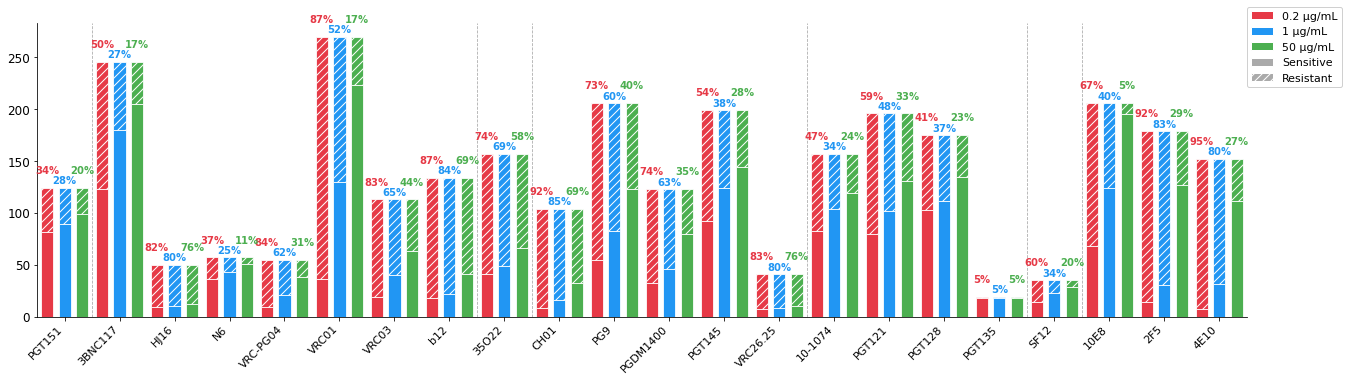

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

DATA_PATH      = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
LABEL_PATH     = "/Users/YUQIAO/blackbox/VALANCE/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records_include_TBDs_GTlabels_flipped.txt"
EXCLUDE_VIRUS  = ['BC11', 'T250_4', 'T252_7']

ANTIBODIES_LIST = ['PGT121', 'VRC01', '10-1074', 'PGT145', '3BNC117', 'PGDM1400',
                   'VRC26.25', 'PGT151', 'PG9', '4E10', 'PGT128', 'SF12', 'N6',
                   '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 
                   'b12', 'VRC03', '2F5']
THRESHOLDS = [0.2, 1, 50]

# color = threshold, hatch = sensitive vs resistant
THR_COLORS   = {0.2: "#E63946", 1: "#2196F3", 50: "#4CAF50"}
THR_LABELS   = {0.2: "0.2 µg/mL", 1: "1 µg/mL", 50: "50 µg/mL"}
SENS_HATCH   = ""       # solid fill for sensitive
RESIST_HATCH = "///"    # diagonal hatch for resistant

# EPITOPE_ORDER = [
#     "FUSION_PEPTIDE", "GP120_CD4BS", "GP41-GP120_INTERFACE",
#     "GP120_V2", "GP41-GP41_INTERFACE", "GP120_V3",
#     "GP120_SILENT", "GP41_MPER",
# ]


# Build counts_df from label file
ldf = pd.read_csv(LABEL_PATH, sep="\t")
ldf = ldf[~ldf["Virus"].isin(EXCLUDE_VIRUS)]
ldf = ldf[ldf["Antibody"].isin(ANTIBODIES_LIST)]
ldf["Threshold"] = pd.to_numeric(ldf["Threshold"], errors="coerce")

rows = []
for ab in ANTIBODIES_LIST:
    row = {"Antibody": ab}
    for thr in THRESHOLDS:
        sub = ldf[(ldf["Antibody"] == ab) & (ldf["Threshold"] == thr)]
        row[f"Sensitive (thr={thr})"] = (sub["Label_Sensitive/Resistant"] == "sensitive").sum()
        row[f"Resistant (thr={thr})"] = (sub["Label_Sensitive/Resistant"] == "resistant").sum()
    rows.append(row)
counts_df = pd.DataFrame(rows).set_index("Antibody")

# Print raw count table
print("\nRaw counts per antibody:")
print(counts_df.to_string())
counts_df.to_csv("/Users/YUQIAO/blackbox/VALANCE/plots/label_counts_table.csv")
print("\n✓ Saved label_counts_table.csv")

# Sort antibodies by epitope
epitope_map = (df[["Antibody", "epitope"]].drop_duplicates()
               .set_index("Antibody")["epitope"].str.strip().to_dict())

EPITOPE_ORDER = [
    "FUSION_PEPTIDE", "GP120_CD4BS", "SUBUNIT_INTERFACE",
    "GP120_V2", "GP120_V3", "GP120_SILENT", "GP41_MPER",
]

EPITOPE_MERGE = {
    "GP41-GP120_INTERFACE": "SUBUNIT_INTERFACE",
    "GP41-GP41_INTERFACE":  "SUBUNIT_INTERFACE",
}
def merged_epitope(ab):
    epi = epitope_map.get(ab, "")
    return EPITOPE_MERGE.get(epi, epi)

EPITOPE_DISPLAY = {
    "FUSION_PEPTIDE":    "Fusion Peptide",
    "GP120_CD4BS":       "CD4BS",
    "SUBUNIT_INTERFACE": "Subunit Interface",
    "GP120_V2":          "V2-Apex",
    "GP120_V3":          "V3-glycan",
    "GP120_SILENT":      "GP120 Silent Face",
    "GP41_MPER":         "MPER",
}


def epitope_sort_key(ab):
    epi = merged_epitope(ab)
    idx = EPITOPE_ORDER.index(epi) if epi in EPITOPE_ORDER else len(EPITOPE_ORDER)
    return (idx, ab)

antibodies     = sorted(ANTIBODIES_LIST, key=epitope_sort_key)

epitope_labels = [EPITOPE_DISPLAY.get(merged_epitope(ab), merged_epitope(ab)) for ab in antibodies]
counts_df      = counts_df.loc[antibodies]

# Plot 
n_ab    = len(antibodies)
bar_w   = 0.22
n_thr   = len(THRESHOLDS)
offsets = np.linspace(-(n_thr-1)/2, (n_thr-1)/2, n_thr) * (bar_w + 0.10)
x       = np.arange(n_ab)
 
fig, ax = plt.subplots(figsize=(20, 6))
fig.subplots_adjust(bottom=0.2, left=0.04, right=0.88)
 
for ti, thr in enumerate(THRESHOLDS):
    sens    = counts_df[f"Sensitive (thr={thr})"].values
    resist  = counts_df[f"Resistant (thr={thr})"].values
    total   = sens + resist
    pct_res = np.where(total > 0, resist / total * 100, 0)
    xpos    = x + offsets[ti]
    color   = THR_COLORS[thr]
 
    # sensitive: solid fill
    ax.bar(xpos, sens, width=bar_w, color=color,
           hatch=SENS_HATCH, edgecolor="white", linewidth=0.8, zorder=2)
    # resistant: hatched fill
    ax.bar(xpos, resist, width=bar_w, color=color,
           bottom=sens, hatch=RESIST_HATCH, edgecolor="white", linewidth=0.8, zorder=2)
 
    # % resistant annotation — alternate up/down per threshold group
    for i, (s, r, p) in enumerate(zip(sens, resist, pct_res)):
        if (s + r) > 0:
            offset = 12 if ti % 2 == 0 else 2
            ax.text(xpos[i], s + r + offset, f"{p:.0f}%",
                    ha="center", va="bottom",
                    fontsize=10, fontweight="bold", color=color)

# epitope dividers + labels
prev_epi, group_starts = None, []
for i, epi in enumerate(epitope_labels):
    if epi != prev_epi:
        if i > 0:
            ax.axvline(i - 0.5, color="#AAAAAA", linewidth=0.8,
                       linestyle="--", zorder=0)
        group_starts.append((i, epi))
        prev_epi = epi

ymax = ax.get_ylim()[1]
for idx, (start, epi) in enumerate(group_starts):
    end = group_starts[idx+1][0] if idx+1 < len(group_starts) else n_ab
    mid = (start + end - 1) / 2
#     ax.text(mid, ymax * 1.07, epi, ha="center", va="top",
#             fontsize=13, color="#555555", style="italic",
#             bbox=dict(facecolor="white", edgecolor="none", alpha=0.0, pad=1))

ax.set_xticks(x)
ax.set_xticklabels(antibodies, rotation=45, ha="right", fontsize=11)
# ax.set_ylabel("Count", fontsize=11)
ax.yaxis.set_label_coords(-0.02, 0.5)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=6))
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.set_xlim(-0.5, n_ab - 0.5)
ax.tick_params(axis="y", labelsize=12)

# legend: threshold colors + sens/resist hatches
thr_handles = [mpatches.Patch(facecolor=THR_COLORS[t], edgecolor="white",
                               label=THR_LABELS[t]) for t in THRESHOLDS]
type_handles = [
    mpatches.Patch(facecolor="#AAAAAA", edgecolor="white",
                   hatch=SENS_HATCH,   label="Sensitive"),
    mpatches.Patch(facecolor="#AAAAAA", edgecolor="white",
                   hatch=RESIST_HATCH, label="Resistant"),
]
fig.legend(handles=thr_handles + type_handles,
           loc="upper right", fontsize=11, ncol=1,
           frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(0.95, 0.93))


plt.savefig("/Users/YUQIAO/blackbox/VALANCE/plots/valance_label_ratio_plot.png",
            bbox_inches="tight", dpi=800)
plt.show()

# Fig 5A,B,C

### Full code with titles, axis labels

In [26]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D


BASE_DIR   = "/Users/YUQIAO/blackbox/VALANCE/resistance_predictions"

# ANTIBODIES = ['PGT151', 'PG9', '4E10', 'SF12', 'N6', '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 'VRC34.01', 'b12', 'VRC07-523LS.v34', 'VRC03', '2F5', '8ANC195']  
ANTIBODIES = ['PGT121','VRC01','10-1074','10E8','3BNC117',
              'PGDM1400','VRC26.25','N6','VRC07']

THRESHOLDS = [0.2, 1.0, 50.0]
WINDOW     = 5          
MIN_VIRUSES = 5         

# Predefined distinct colors for up to 26 antibodies
PREDEFINED_COLORS = [
    '#E63946', '#2196F3', '#FF9800', '#4CAF50', '#9C27B0',  # 1-5
    '#00BCD4', '#FF5722', '#8BC34A', '#795548', '#F44336',  # 6-10
    '#3F51B5', '#009688', '#FFC107', '#673AB7', '#CDDC39',  # 11-15
    '#FF4081', '#7C4DFF', '#64FFDA', '#FF6E40', '#18FFFF',  # 16-20
    '#B39DDB', '#FFD54F', '#A1887F', '#E0E0E0', '#90CAF9',  # 21-25
    '#EF9A9A'  # 26
]

# Use predefined colors if available, otherwise generate
if len(ANTIBODIES) <= len(PREDEFINED_COLORS):
    COLORS = PREDEFINED_COLORS[:len(ANTIBODIES)]
else:
    COLORS = get_color_palette(len(ANTIBODIES))

color_dict = {ab: COLORS[i] for i, ab in enumerate(ANTIBODIES)}


def extract_year(virus_name: str):
    parts = virus_name.split("|")
    try:
        return int(float(parts[-2]))   # 2nd-to-last field
    except (IndexError, ValueError):
        return np.nan


records = []
for ab in ANTIBODIES:
    fpath = os.path.join(BASE_DIR, f"{ab}_50.0_prediction_finetuned_tabpfn.txt")
    df = pd.read_csv(fpath, sep="\t", header=None)
    df["antibody"]  = ab
    df["year"]      = df[0].apply(extract_year)
    df["resistant"] = df[2].astype(int)
    df["threshold"] = df[3].astype(float)
    records.append(df[["antibody","year","resistant","threshold"]])

data = pd.concat(records, ignore_index=True)
data = data.dropna(subset=["year"])
data["year"] = data["year"].astype(int)

print(f"Loaded {len(data):,} rows | years {data.year.min()}–{data.year.max()}")
print("Threshold counts:\n", data.threshold.value_counts())

data.head(10)

Loaded 266,571 rows | years 1976–2024
Threshold counts:
 50.0    88857
1.0     88857
0.2     88857
Name: threshold, dtype: int64


,antibody,year,resistant,threshold
0,PGT121,2004,0,50.0
1,PGT121,2004,0,50.0
2,PGT121,1981,0,50.0
3,PGT121,1982,0,50.0
4,PGT121,1981,0,50.0
5,PGT121,1982,0,50.0
6,PGT121,1981,0,50.0
7,PGT121,1983,0,50.0
8,PGT121,1986,0,50.0
9,PGT121,1983,0,50.0


In [27]:
data[247890:247900]

,antibody,year,resistant,threshold
247890,VRC07,2011,0,1.0
247891,VRC07,2009,0,1.0
247892,VRC07,2010,0,1.0
247893,VRC07,1999,0,1.0
247894,VRC07,2011,0,1.0
247895,VRC07,2011,0,1.0
247896,VRC07,2010,0,1.0
247897,VRC07,2001,0,1.0
247898,VRC07,2002,0,1.0
247899,VRC07,2008,0,1.0


In [28]:
# Compute sliding-window resistance %
def sliding_pct(sub: pd.DataFrame, all_years, window=WINDOW, min_n=MIN_VIRUSES):
    """
    For each anchor year, collect viruses in [year, year+window-1]
    and compute % resistant.
    """
    rows = []
    for y in all_years:
        pool = sub[(sub.year >= y) & (sub.year < y + window)]
        n    = len(pool)
        if n >= min_n:
            rows.append({"year_start": y,
                         "year_mid":   y + (window - 1) / 2,
                         "pct":        pool.resistant.mean() * 100,
                         "n":          n})
    return pd.DataFrame(rows)

# pre-compute for every (threshold, antibody) combo
results = {}
for thr in THRESHOLDS:
    sub_thr = data[data.threshold == thr]
    all_years = range(sub_thr.year.min(), sub_thr.year.max() - WINDOW + 2)
    for ab in ANTIBODIES:
        sub = sub_thr[sub_thr.antibody == ab]
        if len(sub) == 0:
            continue
        results[(thr, ab)] = sliding_pct(sub, all_years)

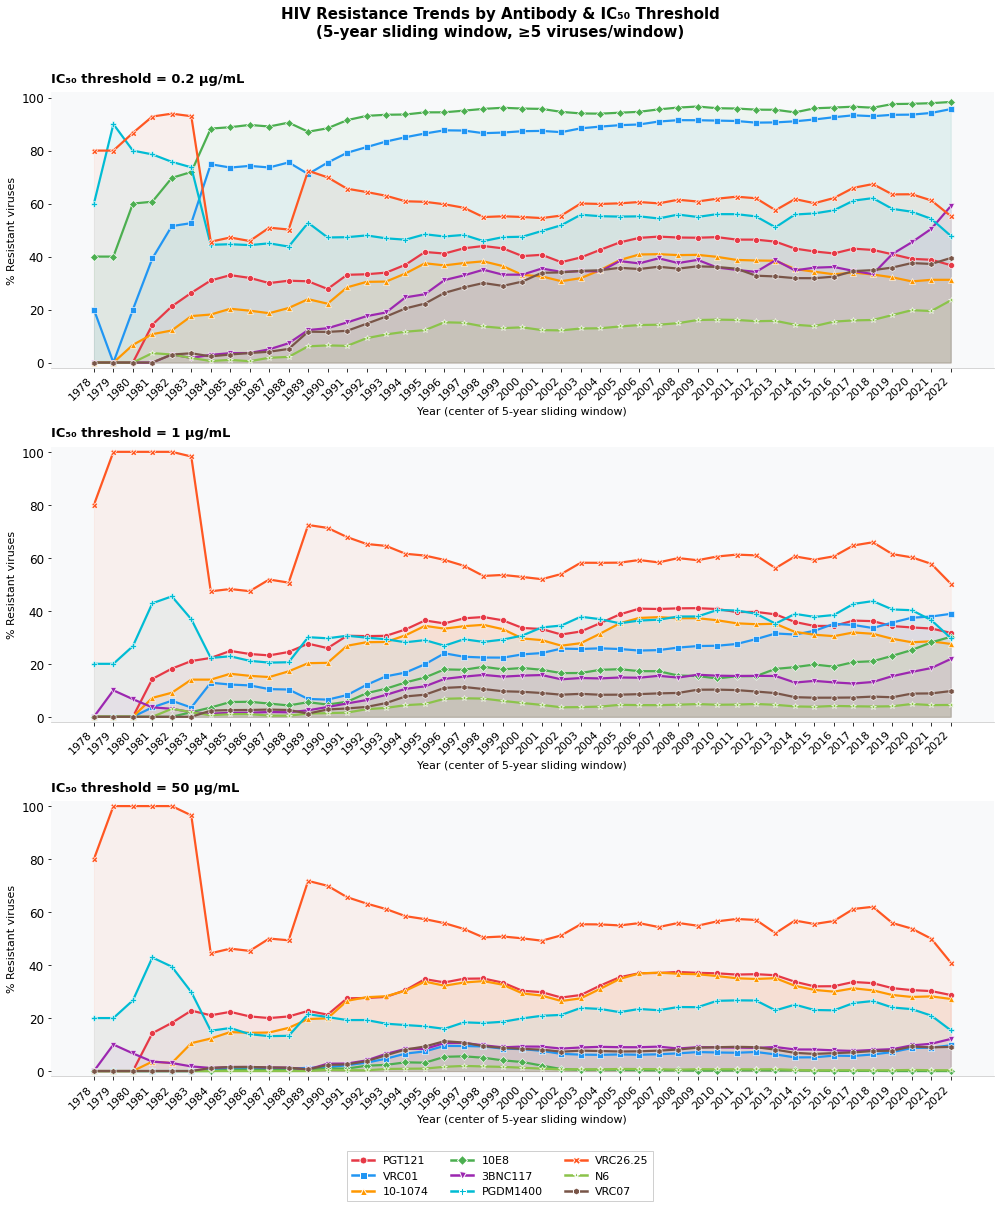

✓ Saved resistance_trends_panel.png


In [30]:
# Panel plot
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h']  # 9 distinct shapes

fig, axes = plt.subplots(
    nrows=len(THRESHOLDS), ncols=1,
    figsize=(14, 5.5 * len(THRESHOLDS)),
    sharex=False
)

THR_LABELS = {0.2: "IC₅₀ threshold = 0.2 µg/mL",
              1.0: "IC₅₀ threshold = 1 µg/mL",
              50.0:"IC₅₀ threshold = 50 µg/mL"}

for ax, thr in zip(axes, THRESHOLDS):
    ax.set_facecolor("#F8F9FA")
    ax.spines[["top","right","left"]].set_visible(False)
    ax.spines["bottom"].set_color("#CCCCCC")

    for ab, color, marker in zip(ANTIBODIES, COLORS, MARKERS):
        key = (thr, ab)
        if key not in results or results[key].empty:
            continue
        df = results[key].sort_values("year_mid")

        ax.plot(df.year_mid, df.pct,
                color=color, linewidth=2.2,
                marker=marker, markersize=6,
                markeredgewidth=0.6, markeredgecolor="white",
                zorder=3, label=ab)

        ax.fill_between(df.year_mid, df.pct,
                        alpha=0.06, color=color, zorder=2)

    ax.set_title(THR_LABELS[thr], fontsize=13, fontweight="bold",
                 loc="left", pad=10)
    ax.set_ylabel("% Resistant viruses", fontsize=11)
    ax.set_ylim(-2, 102)
    # ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g%%"))
    ax.set_xlabel(f"Year (center of {WINDOW}-year sliding window)", fontsize=11)

    xticks = sorted({int(r["year_mid"] + 0.5)
                     for k, v in results.items() if k[0] == thr
                     for _, r in v.iterrows()})
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(int(x)) for x in xticks],
                       rotation=45, ha="right", fontsize=11)
    ax.tick_params(axis="y", labelsize=12)

# Shared legend
legend_handles = [Line2D([0],[0], color=c, linewidth=2.5,
                          marker=m, markersize=7,
                          markeredgecolor="white", label=ab)
                  for ab, c, m in zip(ANTIBODIES, COLORS, MARKERS)]

fig.legend(handles=legend_handles,
           # title="Antibody", title_fontsize=11,
           fontsize=11, ncol=3,
           loc="lower center", bbox_to_anchor=(0.5, 0.0),
           frameon=True, framealpha=0.9,
           edgecolor="#CCCCCC", fancybox=False)

fig.suptitle("HIV Resistance Trends by Antibody & IC₅₀ Threshold\n"
             f"({WINDOW}-year sliding window, ≥{MIN_VIRUSES} viruses/window)",
             fontsize=15, fontweight="bold", y=1.01)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("/Users/YUQIAO/blackbox/VALANCE/plots/resistance_trends_panel.png", bbox_inches="tight", dpi=800)
plt.show()
print("✓ Saved resistance_trends_panel.png")

### Remove titles, axis labels for publication

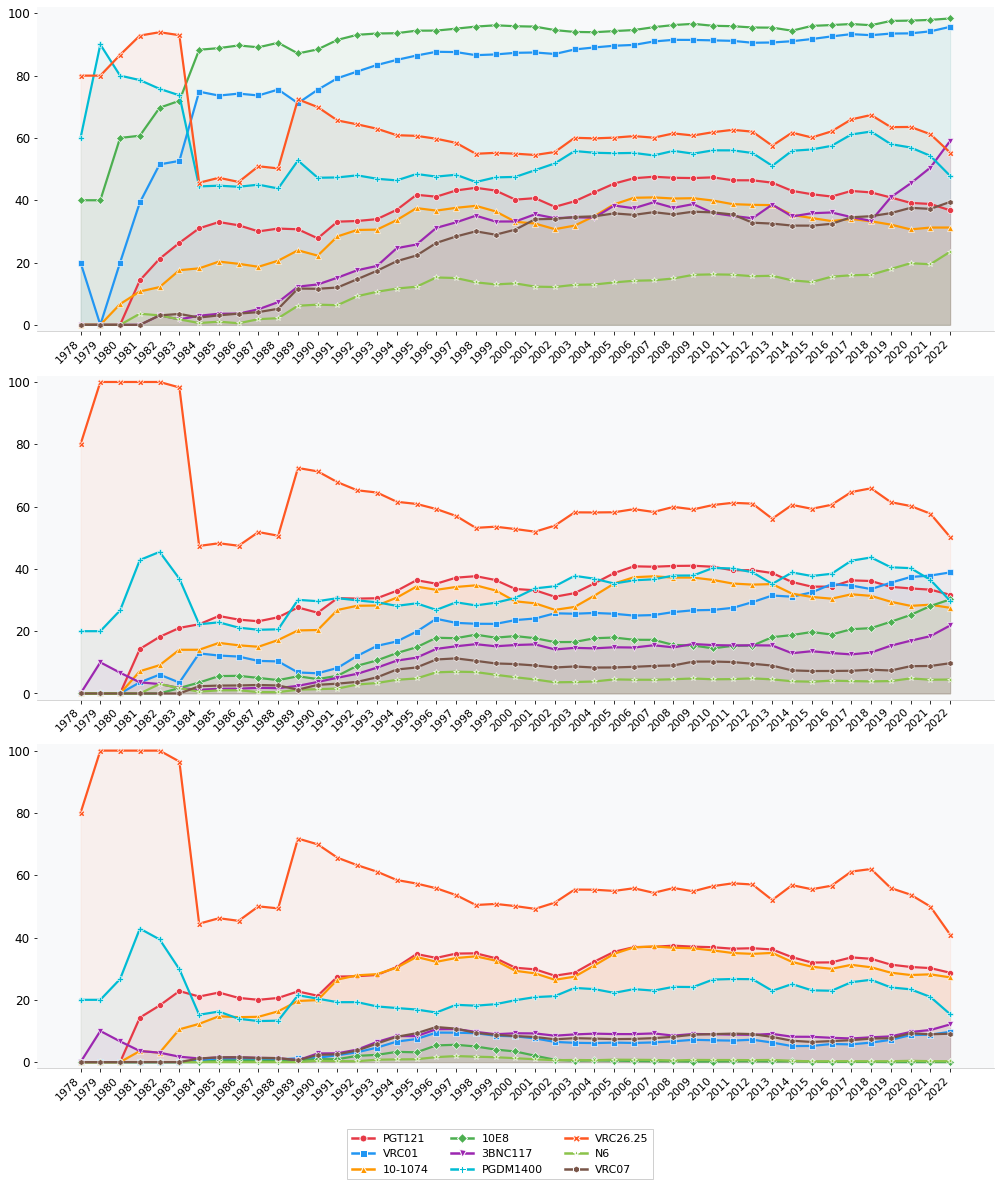

✓ Saved resistance_trends_panel.png


In [31]:
# Panel plot
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h']  # 9 distinct shapes

fig, axes = plt.subplots(
    nrows=len(THRESHOLDS), ncols=1,
    figsize=(14, 5.5 * len(THRESHOLDS)),
    sharex=False
)

THR_LABELS = {0.2: "IC₅₀ threshold = 0.2 µg/mL",
              1.0: "IC₅₀ threshold = 1 µg/mL",
              50.0:"IC₅₀ threshold = 50 µg/mL"}

for ax, thr in zip(axes, THRESHOLDS):
    ax.set_facecolor("#F8F9FA")
    ax.spines[["top","right","left"]].set_visible(False)
    ax.spines["bottom"].set_color("#CCCCCC")

    for ab, color, marker in zip(ANTIBODIES, COLORS, MARKERS):
        key = (thr, ab)
        if key not in results or results[key].empty:
            continue
        df = results[key].sort_values("year_mid")

        ax.plot(df.year_mid, df.pct,
                color=color, linewidth=2.2,
                marker=marker, markersize=6,
                markeredgewidth=0.6, markeredgecolor="white",
                zorder=3, label=ab)

        ax.fill_between(df.year_mid, df.pct,
                        alpha=0.06, color=color, zorder=2)

    # ax.set_title(THR_LABELS[thr], fontsize=13, fontweight="bold",
    #              loc="left", pad=10)
    # ax.set_ylabel("% Resistant viruses", fontsize=11)
    ax.set_ylim(-2, 102)
    # ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g%%"))
    # ax.set_xlabel(f"Year (center of {WINDOW}-year sliding window)", fontsize=11)

    xticks = sorted({int(r["year_mid"] + 0.5)
                     for k, v in results.items() if k[0] == thr
                     for _, r in v.iterrows()})
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(int(x)) for x in xticks],
                       rotation=45, ha="right", fontsize=11)
    ax.tick_params(axis="y", labelsize=12)

# Shared legend
legend_handles = [Line2D([0],[0], color=c, linewidth=2.5,
                          marker=m, markersize=7,
                          markeredgecolor="white", label=ab)
                  for ab, c, m in zip(ANTIBODIES, COLORS, MARKERS)]

fig.legend(handles=legend_handles,
           # title="Antibody", title_fontsize=11,
           fontsize=11, ncol=3,
           loc="lower center", bbox_to_anchor=(0.5, 0.0),
           frameon=True, framealpha=0.9,
           edgecolor="#CCCCCC", fancybox=False)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("/Users/YUQIAO/blackbox/VALANCE/plots/resistance_trends_panel.png", bbox_inches="tight", dpi=800)
plt.show()
print("✓ Saved resistance_trends_panel.png")

# Fig6A, B

### Full code with titles, axis labels

Loaded 266,571 rows | years 1976–2024
  thr=0.2: 176 pan-resistant strains (resistant to all 9 antibodies)
  thr=1.0: 29 pan-resistant strains (resistant to all 9 antibodies)
  thr=50.0: 12 pan-resistant strains (resistant to all 9 antibodies)
  thr=0.2: 9873 strains tested against all 9 antibodies
  thr=1.0: 9873 strains tested against all 9 antibodies
  thr=50.0: 9873 strains tested against all 9 antibodies
Loading sequences from FASTA...
  Loaded 69,107 sequence mappings from FASTA
Loading sequences from FASTA...
  Loaded 9,873 sequences
✓ Saved /home/yujieq/work/ML_training/VALANCE/plots/pan_resistant_strains.csv  (217 rows across 3 thresholds)
threshold
0.2     176
1.0      29
50.0     12
Name: n_pan_strains, dtype: int64


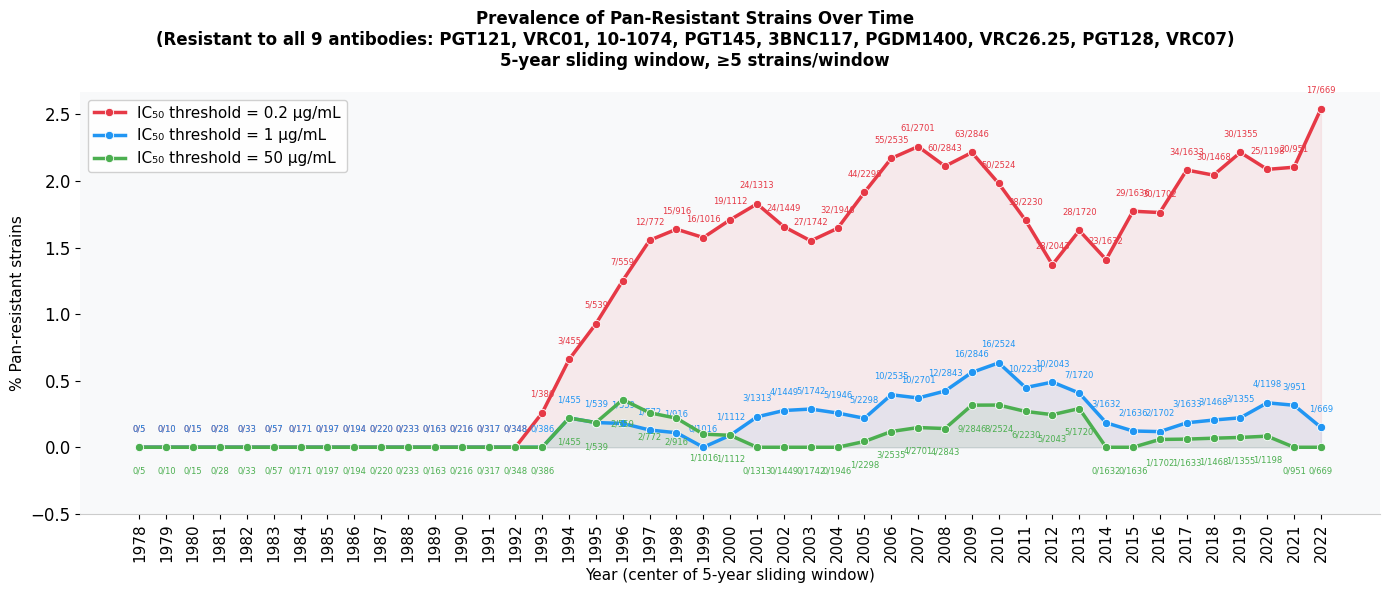

✓ Saved pan_resistance_trend.png


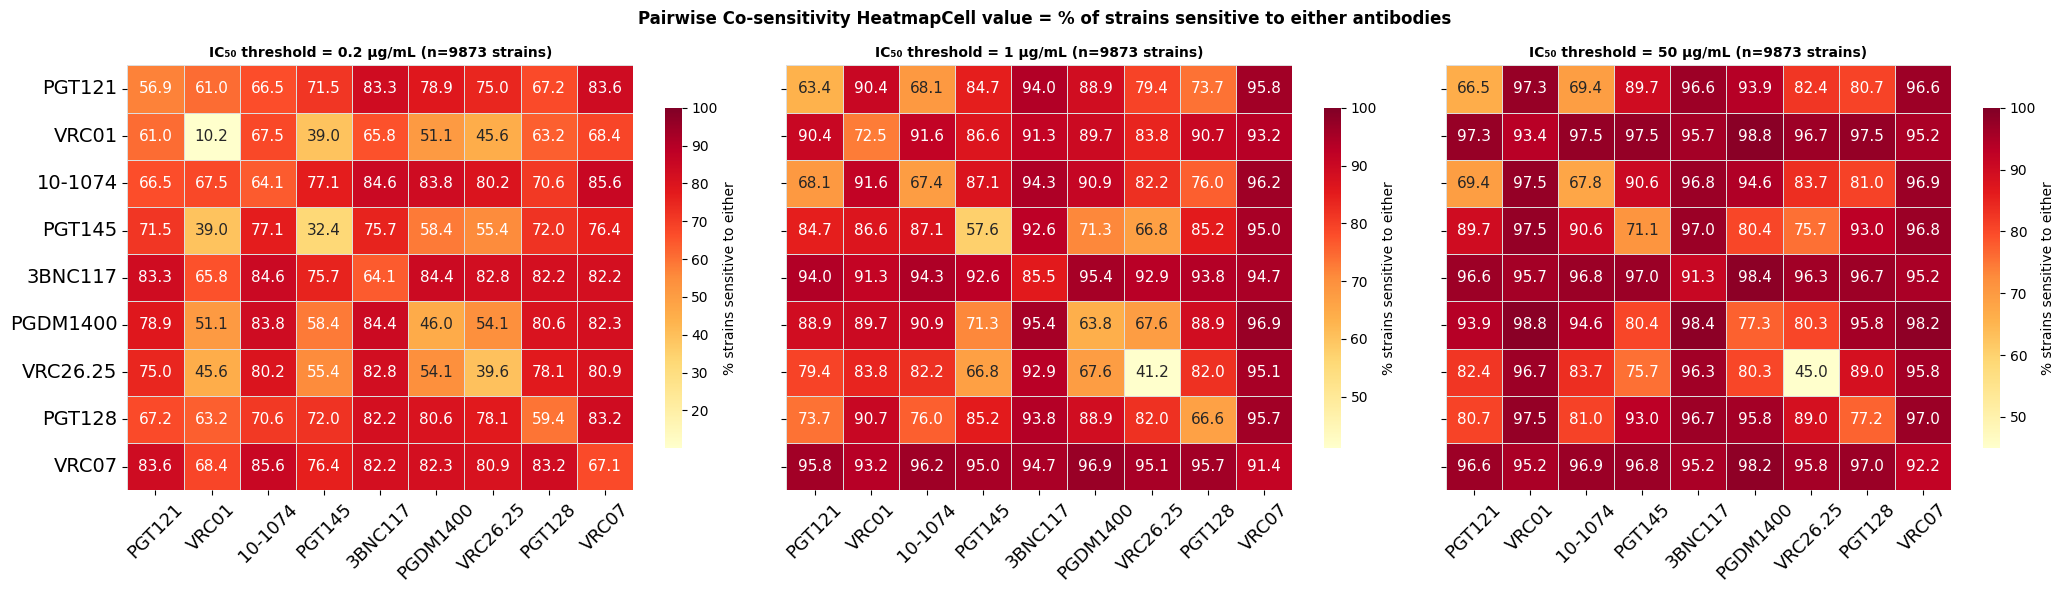

✓ Saved pairwise_coresistance_heatmap.png


In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns



BASE_DIR   = "/Users/YUQIAO/blackbox/VALANCE/resistance_predictions"

# ANTIBODIES = ['PGT151', 'PG9', '4E10', 'SF12', 'N6', '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 'VRC34.01', 'b12', 'VRC07-523LS.v34', 'VRC03', '2F5', '8ANC195']  
ANTIBODIES = ['PGT121','VRC01','10-1074','10E8','3BNC117',
              'PGDM1400','VRC26.25','N6','VRC07']

THRESHOLDS  = [0.2, 1.0, 50.0]
WINDOW      = 5
MIN_VIRUSES = 5

THR_COLORS = {0.2: '#E63946', 1.0: '#2196F3', 50.0: '#4CAF50'}
THR_LABELS = {0.2:  "IC₅₀ threshold = 0.2 µg/mL",
              1.0:  "IC₅₀ threshold = 1 µg/mL",
              50.0: "IC₅₀ threshold = 50 µg/mL"}

def extract_year(virus_name: str):
    parts = virus_name.split("|")
    try:
        return int(float(parts[-2]))
    except (IndexError, ValueError):
        return np.nan


records = []
for ab in ANTIBODIES:
    fpath = os.path.join(BASE_DIR, f"{ab}_50.0_prediction_finetuned_tabpfn.txt")
    df = pd.read_csv(fpath, sep="\t", header=None)
    df["antibody"]  = ab
    df["virus_id"]  = df[0]
    df["year"]      = df[0].apply(extract_year)
    df["resistant"] = df[2].astype(int)
    df["threshold"] = df[3].astype(float)
    records.append(df[["antibody", "virus_id", "year", "resistant", "threshold"]])

data = pd.concat(records, ignore_index=True)
data = data.dropna(subset=["year"])
data["year"] = data["year"].astype(int)
print(f"Loaded {len(data):,} rows | years {data.year.min()}–{data.year.max()}")

# For each threshold, find strains resistant to ALL 9 antibodies 
pan_resistant = {}   
for thr in THRESHOLDS:
    sub = data[data.threshold == thr]
    
    pivot = sub.pivot_table(index="virus_id", columns="antibody",
                            values="resistant", aggfunc="first")
    # keep only viruses with predictions for all 9 antibodies
    pivot = pivot.dropna(subset=ANTIBODIES)
    
    pan_ids = set(pivot.index[pivot[ANTIBODIES].sum(axis=1) == len(ANTIBODIES)])
    pan_resistant[thr] = pan_ids
    print(f"  thr={thr}: {len(pan_ids)} pan-resistant strains "
          f"(resistant to all {len(ANTIBODIES)} antibodies)")

# Get strains tested against ALL 9 antibodies (per threshold) 
# denominator = only strains with predictions for all 9 abs
fully_tested = {}   
for thr in THRESHOLDS:
    sub = data[data.threshold == thr]
    pivot = sub.pivot_table(index="virus_id", columns="antibody",
                            values="resistant", aggfunc="first")
    complete_ids = set(pivot.dropna(subset=ANTIBODIES).index)
    year_map = (sub[sub.virus_id.isin(complete_ids)]
                [["virus_id", "year"]].drop_duplicates("virus_id")
                .set_index("virus_id")["year"].to_dict())
    fully_tested[thr] = year_map
    print(f"  thr={thr}: {len(complete_ids)} strains tested against all "
          f"{len(ANTIBODIES)} antibodies")

# Sliding window: % pan-resistant among fully-tested strains only ─
def sliding_pan_pct(pan_ids, fully_tested_years, window=WINDOW, min_n=MIN_VIRUSES):
    """
    Denominator = strains tested against all 9 antibodies in the window.
    Numerator   = subset of those that are pan-resistant.
    """
    if not fully_tested_years:
        return pd.DataFrame()
    all_years = range(min(fully_tested_years.values()),
                      max(fully_tested_years.values()) - window + 2)
    rows = []
    for y in all_years:
        fully_in_window = {vid for vid, yr in fully_tested_years.items()
                           if y <= yr < y + window}
        pan_in_window   = fully_in_window & pan_ids
        n_all = len(fully_in_window)
        n_pan = len(pan_in_window)
        if n_all >= min_n:
            rows.append({
                "year_start": y,
                "year_mid":   y + (window - 1) / 2,
                "pct":        n_pan / n_all * 100,
                "n_all":      n_all,
                "n_pan":      n_pan,
            })
    return pd.DataFrame(rows)

trend_results = {}
for thr in THRESHOLDS:
    trend_results[thr] = sliding_pan_pct(pan_resistant[thr], fully_tested[thr])

# Load env sequences from FASTA 
from Bio import SeqIO
FASTA_FILE = "/home/yujieq/work/ML_training/VALANCE/scripts/env_all_11-2025_preprocessed_CDS_aa.unique.fa"

print("Loading sequences from FASTA...")

seq_map = {}
for rec in SeqIO.parse(FASTA_FILE, "fasta"):
    seq = str(rec.seq)
    
    seq_map[rec.id] = seq
    for field in rec.id.split("|"):
        field = field.strip()
        if field:
            seq_map[field] = seq
print(f"  Loaded {len(seq_map):,} sequence mappings from FASTA")

# Save pan-resistant strains to CSV 
# For each threshold, collect all strains resistant to ALL 9 antibodies
# with their year and per-antibody resistance labels
pan_rows = []
for thr in THRESHOLDS:
    sub   = data[data.threshold == thr]
    pivot = sub.pivot_table(index="virus_id", columns="antibody",
                            values="resistant", aggfunc="first")
    pivot = pivot.reindex(columns=ANTIBODIES).dropna(subset=ANTIBODIES)
    pan_ids = pan_resistant[thr]
    pan_pivot = pivot.loc[pivot.index.isin(pan_ids)].copy()
    pan_pivot = pan_pivot.reset_index()
    pan_pivot["threshold"] = thr
    # add year
    year_map = fully_tested[thr]
    pan_pivot["year"] = pan_pivot["virus_id"].map(year_map)
    pan_rows.append(pan_pivot)

pan_df = pd.concat(pan_rows, ignore_index=True)

cols = ["virus_id", "year", "threshold"] + ANTIBODIES
pan_df = pan_df[cols].sort_values(["threshold", "year", "virus_id"])

# Add env sequence from original FASTA
from Bio import SeqIO

FASTA_FILE = "/home/yujieq/work/ML_training/VALANCE/scripts/env_all_11-2025_preprocessed_CDS_aa.unique.fa"
print("Loading sequences from FASTA...")
seq_map = {}   
for rec in SeqIO.parse(FASTA_FILE, "fasta"):
    vid = rec.id
    seq_map[vid] = str(rec.seq)
print(f"  Loaded {len(seq_map):,} sequences")

pan_df["env_seq"] = pan_df["virus_id"].map(seq_map)
n_missing = pan_df["env_seq"].isna().sum()
if n_missing:
    print(f"  [WARN] {n_missing} strains had no matching sequence in FASTA")
n_missing = pan_df["env_seq"].isna().sum()
if n_missing:
    print(f"  [WARN] {n_missing} strains had no matching sequence in FASTA")

cols = ["virus_id", "year", "threshold", "env_seq"] + ANTIBODIES
pan_df = pan_df[cols].sort_values(["threshold", "year", "virus_id"])
pan_df["env_seq"] = pan_df["virus_id"].map(seq_map)
n_missing = pan_df["env_seq"].isna().sum()
if n_missing:
    print(f"  [WARN] {n_missing} strains had no matching sequence in FASTA")

csv_path = "/home/yujieq/work/ML_training/VALANCE/plots/pan_resistant_strains.csv"
pan_df.to_csv(csv_path, index=False)
print(f"✓ Saved {csv_path}  ({len(pan_df)} rows across {len(THRESHOLDS)} thresholds)")
print(pan_df.groupby("threshold").size().rename("n_pan_strains"))

# Plot 1: single-panel trend (all 3 thresholds overlaid)
fig, ax = plt.subplots(figsize=(14, 6))

ax.set_facecolor("#F8F9FA")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

for thr in THRESHOLDS:
    df    = trend_results[thr].sort_values("year_mid")
    color = THR_COLORS[thr]

    ax.plot(df.year_mid, df.pct, color=color, linewidth=2.5,
            marker="o", markersize=6, markeredgewidth=0.6,
            markeredgecolor="white", zorder=3, label=THR_LABELS[thr])
    ax.fill_between(df.year_mid, df.pct, alpha=0.08, color=color, zorder=2)

    # labels above for thr 0.2 and 1.0, below for thr 50.0
    label_above = thr in [0.2, 1.0]
    for i, (_, row) in enumerate(df.iterrows()):
        offset = 10 if label_above else -14
        va     = "bottom" if label_above else "top"
        ax.annotate(f"{int(row.n_pan)}/{int(row.n_all)}",
                    xy=(row.year_mid, row.pct),
                    xytext=(0, offset), textcoords="offset points",
                    ha="center", va=va, fontsize=6, color=color)

ax.set_ylabel("% Pan-resistant strains", fontsize=11)
ax.set_ylim(-0.5, None)
# ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g%%"))
ax.set_xlabel(f"Year (center of {WINDOW}-year sliding window)", fontsize=11)
ax.tick_params(axis="y", labelsize=12)

# show every year on x-axis
all_years = sorted(set(
    int(row.year_mid) for df in trend_results.values()
    for _, row in df.iterrows()
))
ax.set_xticks(all_years)
ax.set_xticklabels([str(y) for y in all_years], rotation=90, ha="center", fontsize=11)

ax.legend(fontsize=11, frameon=True, framealpha=0.9,
          edgecolor="#CCCCCC", loc="upper left")

fig.suptitle(
    f"Prevalence of Pan-Resistant Strains Over Time\n"
    f"(Resistant to all {len(ANTIBODIES)} antibodies: "
    f"{', '.join(ANTIBODIES)})\n"
    f"{WINDOW}-year sliding window, ≥{MIN_VIRUSES} strains/window",
    fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(
    "/home/yujieq/work/ML_training/VALANCE/plots/pan_resistance_trend.png",
    bbox_inches="tight", dpi=800)
plt.show()
print("✓ Saved pan_resistance_trend.png")

# Plot 2: pairwise co-sensitivity heatmap 
# For each pair of antibodies, compute fraction of strains sensitive to BOTH
import seaborn as sns

n_ab = len(ANTIBODIES)

fig, axes = plt.subplots(1, len(THRESHOLDS),
                         figsize=(7 * len(THRESHOLDS), 6),
                         sharey=True)

for ax, thr in zip(axes, THRESHOLDS):
    sub   = data[data.threshold == thr]
    pivot = sub.pivot_table(index="virus_id", columns="antibody",
                            values="resistant", aggfunc="first")
    pivot = pivot.reindex(columns=ANTIBODIES).dropna(subset=ANTIBODIES)
    n_total = len(pivot)

    # build n_ab × n_ab matrix: % sensitive to either antibody i or j
    mat = pd.DataFrame(np.nan, index=ANTIBODIES, columns=ANTIBODIES)
    for ab1 in ANTIBODIES:
        for ab2 in ANTIBODIES:
            either = ((pivot[ab1] == 0) | (pivot[ab2] == 0)).sum()
            mat.loc[ab1, ab2] = either / n_total * 100
    vmin_data = mat.min().min()   # start color scale from actual data minimum

    sns.heatmap(mat, ax=ax, cmap="YlOrRd", vmin=vmin_data, vmax=100,
                annot=True, fmt=".1f", annot_kws={"size": 11},
                linewidths=0.4, linecolor="#DDDDDD",
                cbar_kws={"label": "% strains sensitive to either",
                          "shrink": 0.8})
    ax.set_title(f"{THR_LABELS[thr]} (n={n_total} strains)",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=13)
    ax.tick_params(axis="y", rotation=0,  labelsize=14)

fig.suptitle("Pairwise Co-sensitivity Heatmap"
             "Cell value = % of strains sensitive to either antibodies",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "/home/yujieq/work/ML_training/VALANCE/plots/pairwise_cosensitivity_heatmap.png",
    bbox_inches="tight", dpi=800)
plt.show()
print("✓ Saved pairwise_coresistance_heatmap.png")

### Remove titles, axis labels for publication

Loaded 266,571 rows | years 1976–2024
  thr=0.2: 97 pan-resistant strains (resistant to all 9 antibodies)
  thr=1.0: 8 pan-resistant strains (resistant to all 9 antibodies)
  thr=50.0: 1 pan-resistant strains (resistant to all 9 antibodies)
  thr=0.2: 9873 strains tested against all 9 antibodies
  thr=1.0: 9873 strains tested against all 9 antibodies
  thr=50.0: 9873 strains tested against all 9 antibodies
Loading sequences from FASTA...
  Loaded 69,107 sequence mappings from FASTA
Loading sequences from FASTA...
  Loaded 9,873 sequences
✓ Saved /Users/YUQIAO/blackbox/VALANCE/plots/pan_resistant_strains.csv  (106 rows across 3 thresholds)
threshold
0.2     97
1.0      8
50.0     1
Name: n_pan_strains, dtype: int64


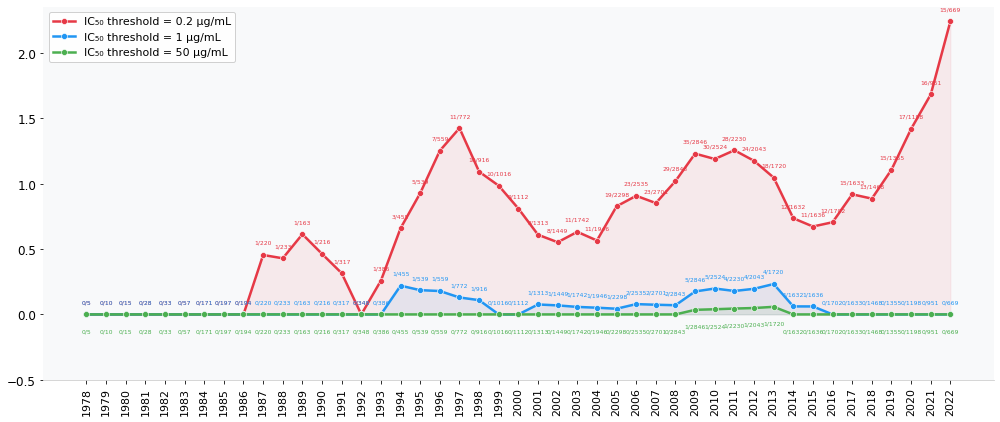

✓ Saved pan_resistance_trend.png


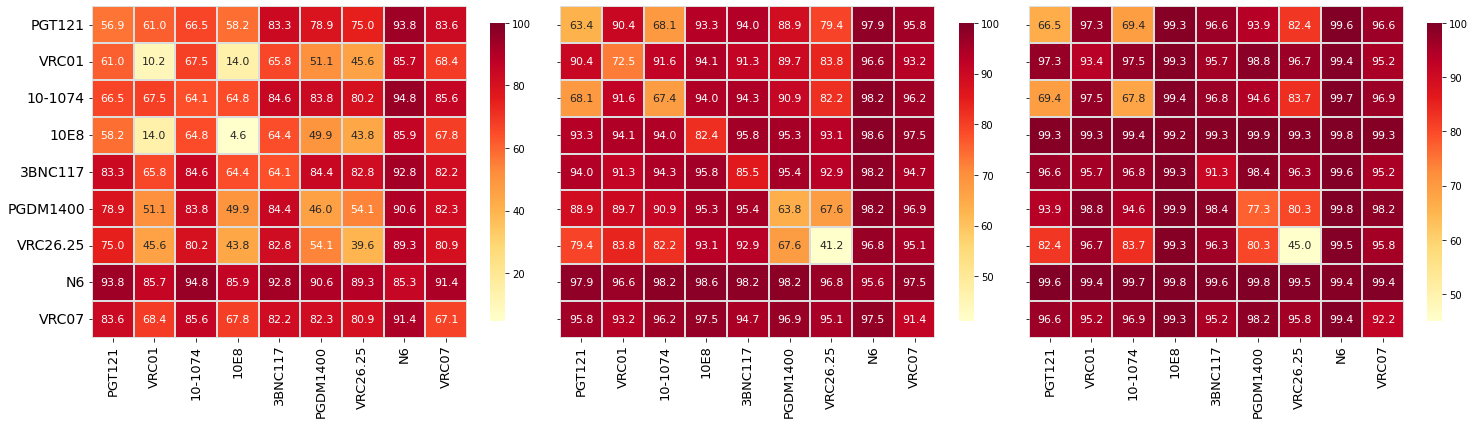

✓ Saved pairwise_coresistance_heatmap.png


In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns



BASE_DIR   = "/Users/YUQIAO/blackbox/VALANCE/resistance_predictions"

# ANTIBODIES = ['PGT151', 'PG9', '4E10', 'SF12', 'N6', '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 'VRC34.01', 'b12', 'VRC07-523LS.v34', 'VRC03', '2F5', '8ANC195']  
ANTIBODIES = ['PGT121','VRC01','10-1074','10E8','3BNC117',
              'PGDM1400','VRC26.25','N6','VRC07']
THRESHOLDS  = [0.2, 1.0, 50.0]
WINDOW      = 5
MIN_VIRUSES = 5

THR_COLORS = {0.2: '#E63946', 1.0: '#2196F3', 50.0: '#4CAF50'}
THR_LABELS = {0.2:  "IC₅₀ threshold = 0.2 µg/mL",
              1.0:  "IC₅₀ threshold = 1 µg/mL",
              50.0: "IC₅₀ threshold = 50 µg/mL"}

def extract_year(virus_name: str):
    parts = virus_name.split("|")
    try:
        return int(float(parts[-2]))
    except (IndexError, ValueError):
        return np.nan


records = []
for ab in ANTIBODIES:
    fpath = os.path.join(BASE_DIR, f"{ab}_50.0_prediction_finetuned_tabpfn.txt")
    df = pd.read_csv(fpath, sep="\t", header=None)
    df["antibody"]  = ab
    df["virus_id"]  = df[0]
    df["year"]      = df[0].apply(extract_year)
    df["resistant"] = df[2].astype(int)
    df["threshold"] = df[3].astype(float)
    records.append(df[["antibody", "virus_id", "year", "resistant", "threshold"]])

data = pd.concat(records, ignore_index=True)
data = data.dropna(subset=["year"])
data["year"] = data["year"].astype(int)
print(f"Loaded {len(data):,} rows | years {data.year.min()}–{data.year.max()}")

# For each threshold, find strains resistant to ALL 9 antibodies 
pan_resistant = {}   
for thr in THRESHOLDS:
    sub = data[data.threshold == thr]
    
    pivot = sub.pivot_table(index="virus_id", columns="antibody",
                            values="resistant", aggfunc="first")
    # keep only viruses with predictions for all 9 antibodies
    pivot = pivot.dropna(subset=ANTIBODIES)
    
    pan_ids = set(pivot.index[pivot[ANTIBODIES].sum(axis=1) == len(ANTIBODIES)])
    pan_resistant[thr] = pan_ids
    print(f"  thr={thr}: {len(pan_ids)} pan-resistant strains "
          f"(resistant to all {len(ANTIBODIES)} antibodies)")

# Get strains tested against ALL 9 antibodies (per threshold) 
# denominator = only strains with predictions for all 9 abs
fully_tested = {}   
for thr in THRESHOLDS:
    sub = data[data.threshold == thr]
    pivot = sub.pivot_table(index="virus_id", columns="antibody",
                            values="resistant", aggfunc="first")
    complete_ids = set(pivot.dropna(subset=ANTIBODIES).index)
    year_map = (sub[sub.virus_id.isin(complete_ids)]
                [["virus_id", "year"]].drop_duplicates("virus_id")
                .set_index("virus_id")["year"].to_dict())
    fully_tested[thr] = year_map
    print(f"  thr={thr}: {len(complete_ids)} strains tested against all "
          f"{len(ANTIBODIES)} antibodies")

# Sliding window: % pan-resistant among fully-tested strains only ─
def sliding_pan_pct(pan_ids, fully_tested_years, window=WINDOW, min_n=MIN_VIRUSES):
    """
    Denominator = strains tested against all 9 antibodies in the window.
    Numerator   = subset of those that are pan-resistant.
    """
    if not fully_tested_years:
        return pd.DataFrame()
    all_years = range(min(fully_tested_years.values()),
                      max(fully_tested_years.values()) - window + 2)
    rows = []
    for y in all_years:
        fully_in_window = {vid for vid, yr in fully_tested_years.items()
                           if y <= yr < y + window}
        pan_in_window   = fully_in_window & pan_ids
        n_all = len(fully_in_window)
        n_pan = len(pan_in_window)
        if n_all >= min_n:
            rows.append({
                "year_start": y,
                "year_mid":   y + (window - 1) / 2,
                "pct":        n_pan / n_all * 100,
                "n_all":      n_all,
                "n_pan":      n_pan,
            })
    return pd.DataFrame(rows)

trend_results = {}
for thr in THRESHOLDS:
    trend_results[thr] = sliding_pan_pct(pan_resistant[thr], fully_tested[thr])

# Load env sequences from FASTA 
from Bio import SeqIO
FASTA_FILE = "/Users/YUQIAO/blackbox/VALANCE/env_all_11-2025_preprocessed_CDS_aa.unique.fa"

print("Loading sequences from FASTA...")

seq_map = {}
for rec in SeqIO.parse(FASTA_FILE, "fasta"):
    seq = str(rec.seq)
    
    seq_map[rec.id] = seq
    for field in rec.id.split("|"):
        field = field.strip()
        if field:
            seq_map[field] = seq
print(f"  Loaded {len(seq_map):,} sequence mappings from FASTA")

# Save pan-resistant strains to CSV 
# For each threshold, collect all strains resistant to ALL 9 antibodies
# with their year and per-antibody resistance labels
pan_rows = []
for thr in THRESHOLDS:
    sub   = data[data.threshold == thr]
    pivot = sub.pivot_table(index="virus_id", columns="antibody",
                            values="resistant", aggfunc="first")
    pivot = pivot.reindex(columns=ANTIBODIES).dropna(subset=ANTIBODIES)
    pan_ids = pan_resistant[thr]
    pan_pivot = pivot.loc[pivot.index.isin(pan_ids)].copy()
    pan_pivot = pan_pivot.reset_index()
    pan_pivot["threshold"] = thr
    # add year
    year_map = fully_tested[thr]
    pan_pivot["year"] = pan_pivot["virus_id"].map(year_map)
    pan_rows.append(pan_pivot)

pan_df = pd.concat(pan_rows, ignore_index=True)

cols = ["virus_id", "year", "threshold"] + ANTIBODIES
pan_df = pan_df[cols].sort_values(["threshold", "year", "virus_id"])

# Add env sequence from original FASTA
from Bio import SeqIO

FASTA_FILE = "/Users/YUQIAO/blackbox/VALANCE/env_all_11-2025_preprocessed_CDS_aa.unique.fa"
print("Loading sequences from FASTA...")
seq_map = {}   
for rec in SeqIO.parse(FASTA_FILE, "fasta"):
    vid = rec.id
    seq_map[vid] = str(rec.seq)
print(f"  Loaded {len(seq_map):,} sequences")

pan_df["env_seq"] = pan_df["virus_id"].map(seq_map)
n_missing = pan_df["env_seq"].isna().sum()
if n_missing:
    print(f"  [WARN] {n_missing} strains had no matching sequence in FASTA")
n_missing = pan_df["env_seq"].isna().sum()
if n_missing:
    print(f"  [WARN] {n_missing} strains had no matching sequence in FASTA")

cols = ["virus_id", "year", "threshold", "env_seq"] + ANTIBODIES
pan_df = pan_df[cols].sort_values(["threshold", "year", "virus_id"])
pan_df["env_seq"] = pan_df["virus_id"].map(seq_map)
n_missing = pan_df["env_seq"].isna().sum()
if n_missing:
    print(f"  [WARN] {n_missing} strains had no matching sequence in FASTA")

csv_path = "/Users/YUQIAO/blackbox/VALANCE/plots/pan_resistant_strains.csv"
pan_df.to_csv(csv_path, index=False)
print(f"✓ Saved {csv_path}  ({len(pan_df)} rows across {len(THRESHOLDS)} thresholds)")
print(pan_df.groupby("threshold").size().rename("n_pan_strains"))

# Plot 1: single-panel trend (all 3 thresholds overlaid)
fig, ax = plt.subplots(figsize=(14, 6))

ax.set_facecolor("#F8F9FA")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

for thr in THRESHOLDS:
    df    = trend_results[thr].sort_values("year_mid")
    color = THR_COLORS[thr]

    ax.plot(df.year_mid, df.pct, color=color, linewidth=2.5,
            marker="o", markersize=6, markeredgewidth=0.6,
            markeredgecolor="white", zorder=3, label=THR_LABELS[thr])
    ax.fill_between(df.year_mid, df.pct, alpha=0.08, color=color, zorder=2)

    # labels above for thr 0.2 and 1.0, below for thr 50.0
    label_above = thr in [0.2, 1.0]
    for i, (_, row) in enumerate(df.iterrows()):
        offset = 10 if label_above else -14
        va     = "bottom" if label_above else "top"
        ax.annotate(f"{int(row.n_pan)}/{int(row.n_all)}",
                    xy=(row.year_mid, row.pct),
                    xytext=(0, offset), textcoords="offset points",
                    ha="center", va=va, fontsize=6, color=color)

# ax.set_ylabel("% Pan-resistant strains", fontsize=11)
ax.set_ylim(-0.5, None)
# ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g%%"))
# ax.set_xlabel(f"Year (center of {WINDOW}-year sliding window)", fontsize=11)
ax.tick_params(axis="y", labelsize=12)

# show every year on x-axis
all_years = sorted(set(
    int(row.year_mid) for df in trend_results.values()
    for _, row in df.iterrows()
))
ax.set_xticks(all_years)
ax.set_xticklabels([str(y) for y in all_years], rotation=90, ha="center", fontsize=11)

ax.legend(fontsize=11, frameon=True, framealpha=0.9,
          edgecolor="#CCCCCC", loc="upper left")

# fig.suptitle(
#     f"Prevalence of Pan-Resistant Strains Over Time\n"
#     f"(Resistant to all {len(ANTIBODIES)} antibodies: "
#     f"{', '.join(ANTIBODIES)})\n"
#     f"{WINDOW}-year sliding window, ≥{MIN_VIRUSES} strains/window",
#     fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(
    "/Users/YUQIAO/blackbox/VALANCE/plots/pan_resistance_trend.png",
    bbox_inches="tight", dpi=800)
plt.show()
print("✓ Saved pan_resistance_trend.png")

# Plot 2: pairwise co-resistance heatmap 
# For each pair of antibodies, compute fraction of strains resistant to BOTH
import seaborn as sns

n_ab = len(ANTIBODIES)

fig, axes = plt.subplots(1, len(THRESHOLDS),
                         figsize=(7 * len(THRESHOLDS), 6),
                         sharey=True)

for ax, thr in zip(axes, THRESHOLDS):
    sub   = data[data.threshold == thr]
    pivot = sub.pivot_table(index="virus_id", columns="antibody",
                            values="resistant", aggfunc="first")
    pivot = pivot.reindex(columns=ANTIBODIES).dropna(subset=ANTIBODIES)
    n_total = len(pivot)

    # build n_ab × n_ab matrix: % sensitive to either antibody i or j
    mat = pd.DataFrame(np.nan, index=ANTIBODIES, columns=ANTIBODIES)
    for ab1 in ANTIBODIES:
        for ab2 in ANTIBODIES:
            either = ((pivot[ab1] == 0) | (pivot[ab2] == 0)).sum()
            mat.loc[ab1, ab2] = either / n_total * 100
    vmin_data = mat.min().min()   # start color scale from actual data minimum

    sns.heatmap(mat, ax=ax, cmap="YlOrRd", vmin=vmin_data, vmax=100,
                annot=True, fmt=".1f", annot_kws={"size": 11},
                linewidths=0.4, linecolor="#DDDDDD",
                cbar_kws={"label": "",
                          "shrink": 0.9})
    # ax.set_title(f"{THR_LABELS[thr]} (n={n_total} strains)",
    #              fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=90, labelsize=13)
    ax.tick_params(axis="y", rotation=0,  labelsize=14)

# fig.suptitle("Pairwise Co-resistance Heatmap"
#              "Cell value = % of strains resistant to both antibodies",
#              fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "/Users/YUQIAO/blackbox/VALANCE/plots/pairwise_cosensitivity_heatmap.png",
    bbox_inches="tight", dpi=800)
plt.show()
print("✓ Saved pairwise_coresistance_heatmap.png")

# Fig6C

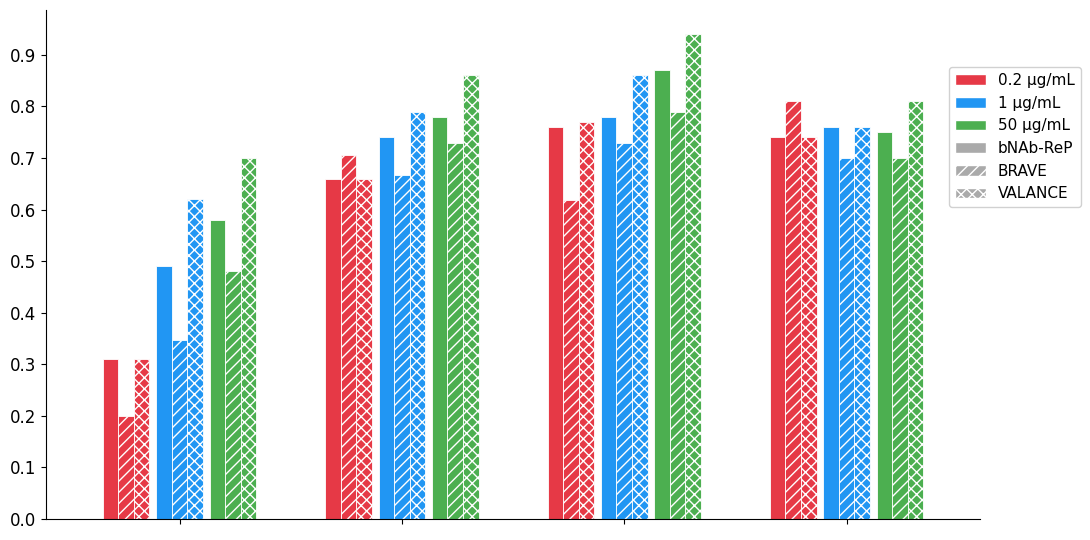

✓ Saved /home/yujieq/work/ML_training/VALANCE/plots/fig6c_all_metrics_barplot.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

XLSX_PATH = "/home/yujieq/work/ML_training/VALANCE/plots/Supplemental_Tables_Final.xlsx"


THR_COLORS = {0.2: "#E63946", 1: "#2196F3", 50: "#4CAF50"}
THR_LABELS = {0.2: "0.2 µg/mL", 1: "1 µg/mL", 50: "50 µg/mL"}


MODEL_ORDER   = ["bNab-rep", "BRAVE", "VALANCE"]
MODEL_LABELS  = {"bNab-rep": "bNAb-ReP", "BRAVE": "BRAVE", "VALANCE": "VALANCE"}
MODEL_HATCHES = {"bNab-rep": "", "BRAVE": "///", "VALANCE": "xxx"}

METRICS = ["MCC", "ACC", "AUC", "F1"]

# Load table 
raw = pd.read_excel(XLSX_PATH, sheet_name="Fig_6C", header=1)
raw = raw.iloc[:, :15]
raw.columns = [
    "Num_Antibodies", "Num_Strains", "Cutoff",
    "bNab-rep MCC", "BRAVE MCC", "VALANCE MCC",
    "bNab-rep ACC", "BRAVE ACC", "VALANCE ACC",
    "bNab-rep AUC", "BRAVE AUC", "VALANCE AUC",
    "bNab-rep F1",  "BRAVE F1",  "VALANCE F1",
]


raw["Cutoff"] = pd.to_numeric(raw["Cutoff"], errors="coerce")
raw = raw.dropna(subset=["Cutoff"]).copy()
for col in raw.columns[3:]:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

THRESHOLDS = sorted(raw["Cutoff"].unique())   # ascending: 0.2, 1, 50
sub = raw.set_index("Cutoff")

n_thr, n_models = len(THRESHOLDS), len(MODEL_ORDER)
bar_w, group_gap = 0.07, 0.03


offsets = []
for ci in range(n_thr):
    for mi in range(n_models):
        offsets.append(ci * (n_models * bar_w + group_gap) + mi * bar_w)
offsets = np.array(offsets)
offsets -= offsets.mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 5.5))

for m_idx, metric in enumerate(METRICS):
    bar_idx = 0
    for thr in THRESHOLDS:
        for model in MODEL_ORDER:
            val = sub.loc[thr, f"{model} {metric}"]
            xpos = m_idx + offsets[bar_idx]
            ax.bar(xpos, val, width=bar_w, color=THR_COLORS[thr],
                   hatch=MODEL_HATCHES[model], edgecolor="white",
                   linewidth=0.6, zorder=2)
            bar_idx += 1

ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels('', fontsize=13)
ax.tick_params(axis="y", labelsize=12)
# ax.set_ylabel("Score", fontsize=13)
ax.set_ylim(0, None)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xlim(-0.6, len(METRICS) - 0.4)

# Combined legend: threshold colors + model hatches
thr_handles = [mpatches.Patch(facecolor=THR_COLORS[t], edgecolor="white",
                               label=THR_LABELS[t]) for t in THRESHOLDS]
model_handles = [mpatches.Patch(facecolor="#AAAAAA", edgecolor="white",
                                 hatch=MODEL_HATCHES[m], label=MODEL_LABELS[m])
                  for m in MODEL_ORDER]
fig.legend(handles=thr_handles + model_handles,
           loc="lower center", ncol=1, fontsize=11,
           framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(1.02, 0.60))

n_ab = int(raw["Num_Antibodies"].iloc[0])
n_strains = int(raw["Num_Strains"].iloc[0])


plt.tight_layout()

out = "/home/yujieq/work/ML_training/VALANCE/plots/fig6c_all_metrics_barplot.png"
plt.savefig(out, bbox_inches="tight", dpi=800)
plt.show()
print(f"✓ Saved {out}")

# Fig6D

### Independent test dataset

Processing PGT121 @ thres 0.2 ...
  196 matched strains
Processing VRC01 @ thres 0.2 ...
  270 matched strains
Processing 10-1074 @ thres 0.2 ...
  157 matched strains
Processing PGT145 @ thres 0.2 ...
  199 matched strains
Processing 3BNC117 @ thres 0.2 ...
  246 matched strains
Processing PGDM1400 @ thres 0.2 ...
  123 matched strains
Processing SF12 @ thres 0.2 ...
  35 matched strains
Processing N6 @ thres 0.2 ...
  57 matched strains
Processing PGT121 @ thres 1.0 ...
  196 matched strains
Processing VRC01 @ thres 1.0 ...
  270 matched strains
Processing 10-1074 @ thres 1.0 ...
  157 matched strains
Processing PGT145 @ thres 1.0 ...
  199 matched strains
Processing 3BNC117 @ thres 1.0 ...
  246 matched strains
Processing PGDM1400 @ thres 1.0 ...
  123 matched strains
Processing SF12 @ thres 1.0 ...
  35 matched strains
Processing N6 @ thres 1.0 ...
  57 matched strains
Processing PGT121 @ thres 50.0 ...
  196 matched strains
Processing VRC01 @ thres 50.0 ...
  270 matched strains
P

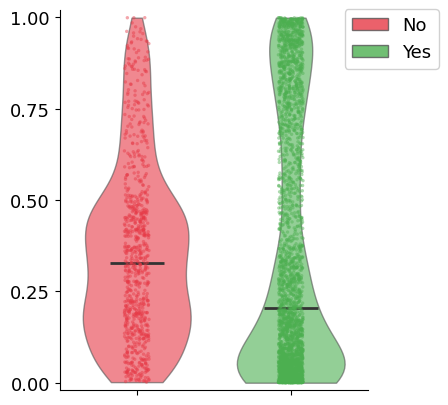

In [24]:
import os
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

# Configuration 
GROUND_TRUTH_FILE = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records_include_TBDs_GTlabels_flipped.txt"

PREDICTION_BASE_DIR = "/home/yujieq/work/ML_training/VALANCE"
OUTPUT_DIR = "/home/yujieq/work/ML_training/VALANCE/plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 8 antibodies 
ANTIBODIES = ['PGT121', 'VRC01', '10-1074', 'PGT145', '3BNC117', 'PGDM1400', 'SF12', 'N6']

THRESHOLDS = [0.2, 1.0, 50.0]

OUTPUT_XLSX = os.path.join(OUTPUT_DIR, "Fig_6D_data_9clinical_abs_all_thresholds.xlsx")
OUTPUT_PNG  = os.path.join(OUTPUT_DIR, "Fig_6D_prob_resistant_by_correctness.png")

# Colors for the two groups (red = incorrect, green = correct - consistent
# with a pass/fail reading; swap these if you'd rather use a different scheme)
GROUP_COLORS = {"No": "#E63946", "Yes": "#4CAF50"}

# Helpers
def extract_virus_id(virus_str):
    if pd.isna(virus_str):
        return None
    parts = str(virus_str).split('.')
    if len(parts) >= 3:
        return parts[-2]
    return str(virus_str)

def extract_resistant_prob(prob_str):
    """Extract the second probability (resistant class) from string like '[0.8808056  0.11919439]'"""
    if pd.isna(prob_str):
        return np.nan
    prob_str = str(prob_str)
    numbers = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', prob_str)
    if len(numbers) >= 2:
        return float(numbers[1])
    elif len(numbers) == 1:
        return float(numbers[0])
    else:
        return np.nan

# Load ground truth 
gt_df_all = pd.read_csv(GROUND_TRUTH_FILE, sep='\t')

# Collect predictions across all antibodies x thresholds
all_predictions = []

for threshold in THRESHOLDS:
    gt_df = gt_df_all[gt_df_all['Threshold'] == threshold].copy()
    gt_df = gt_df[~gt_df['GeoMean_IC50'].isna()]
    gt_df['Virus_clean'] = gt_df['Virus'].apply(extract_virus_id)
    gt_df = gt_df.dropna(subset=['Virus_clean', 'Label_0/1'])
    gt_df['Label_0/1'] = gt_df['Label_0/1'].astype(int)
    gt_df = gt_df.drop_duplicates(subset=['Antibody', 'Virus_clean'])

    for antibody in ANTIBODIES:
        pred_file = os.path.join(
            PREDICTION_BASE_DIR, antibody,
            f"{antibody}_prediction_thres{threshold}_finetuned_tabpfn.txt"
        )

        if not os.path.exists(pred_file):
            print(f"[SKIP] {antibody} @ thres {threshold}: file not found: {pred_file}")
            continue

        print(f"Processing {antibody} @ thres {threshold} ...")

        try:
            pred_df = pd.read_csv(pred_file, sep='\t', header=None,
                                   names=['virus_id', 'probability', 'prediction'])
        except Exception as e:
            print(f"  Error reading {pred_file}: {e}")
            continue

        pred_df['prob_resistant'] = pred_df['probability'].apply(extract_resistant_prob)
        pred_df['virus_id_clean'] = pred_df['virus_id'].apply(extract_virus_id)

        antibody_gt = gt_df[gt_df['Antibody'] == antibody].copy()
        if antibody_gt.empty:
            print(f"  No GT for: {antibody}")
            continue

        matched = 0
        for _, row in antibody_gt.iterrows():
            virus_id = row['Virus_clean']
            gt_label = row['Label_0/1']

            pred_rows = pred_df[pred_df['virus_id_clean'] == virus_id]
            if pred_rows.empty:
                continue

            pred_value = pred_rows['prediction'].iloc[0]
            if isinstance(pred_value, str):
                pred_label = 0 if pred_value.lower() == 'sensitive' else 1
            else:
                pred_label = int(pred_value)

            prob_resistant = pred_rows['prob_resistant'].iloc[0]

            all_predictions.append({
                'Antibody':        antibody,
                'Virus':           virus_id,
                'Threshold':       threshold,
                'GT Label':        gt_label,
                'Prediction':      pred_label,
                'Prob_Resistant':  prob_resistant,
            })
            matched += 1

        print(f"  {matched} matched strains")

if not all_predictions:
    print("No results generated. Check file paths.")
else:
    all_preds_df = pd.DataFrame(all_predictions)
    all_preds_df.to_excel(OUTPUT_XLSX, sheet_name='Fig_6D', index=False)
    print(f"\n✓ Data saved to: {OUTPUT_XLSX}")
    print(f"Total matched predictions across antibodies x thresholds: {len(all_preds_df)}")

    #Split into correct / incorrect groups
    all_preds_df['correct'] = np.where(
        all_preds_df['GT Label'] == all_preds_df['Prediction'], 'Yes', 'No'
    )

    labels = ['No', 'Yes']
    data = [all_preds_df.loc[all_preds_df['correct'] == g, 'Prob_Resistant'].values
            for g in labels]

    print(f"No (incorrect):  n = {len(data[0])}")
    print(f"Yes (correct):   n = {len(data[1])}")

    #Violin + rug plot 
    fig, ax = plt.subplots(figsize=(4, 5))
    fig.subplots_adjust(left=0.18, right=0.95, bottom=0.12)

    parts = ax.violinplot(data, positions=range(len(labels)),
                           showmedians=True, showextrema=False, widths=0.7)

    for body, g in zip(parts['bodies'], labels):
        color = GROUP_COLORS[g]
        body.set_facecolor(color)
        body.set_edgecolor('#555555')
        body.set_alpha(0.6)

    parts['cmedians'].set_color('#333333')
    parts['cmedians'].set_linewidth(2)

    # jittered rug points
    rng = np.random.default_rng(42)
    for i, (g, vals) in enumerate(zip(labels, data)):
        color = GROUP_COLORS[g]
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(i + jitter, vals, s=6, color=color, alpha=0.45,
                   zorder=3, edgecolors='none')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels('', fontsize=14)
    # ax.set_xlabel('correct', fontsize=13)
    ax.set_xlim(-0.5, len(labels) - 0.5)
    ax.set_ylim(-0.02, 1.02)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=13)
    # ax.set_ylabel("Prob_Resistant", fontsize=13)

    group_handles = [mpatches.Patch(facecolor=GROUP_COLORS[g], edgecolor='#555',
                                     label=g, alpha=0.8) for g in labels]
    fig.legend(handles=group_handles, fontsize=13, ncol=1, frameon=True,
               framealpha=0.9, edgecolor='#CCCCCC',
               loc='upper right', bbox_to_anchor=(1.15, 0.90))

    # fig.suptitle("Prob_Resistant by Prediction Correctness\n"
    #              "Dots show individual strains; line = median",
    #              fontsize=11, fontweight="bold")

    plt.savefig(OUTPUT_PNG, dpi=800, bbox_inches='tight')
    print(f"✓ Plot saved to: {OUTPUT_PNG}")

### Xueling W. 11 test strains

No (incorrect):  n = 59
Yes (correct):   n = 199

✓ Saved to: /home/yujieq/work/ML_training/VALANCE/plots/Fig_6D_prob_resistant_by_correctness.png


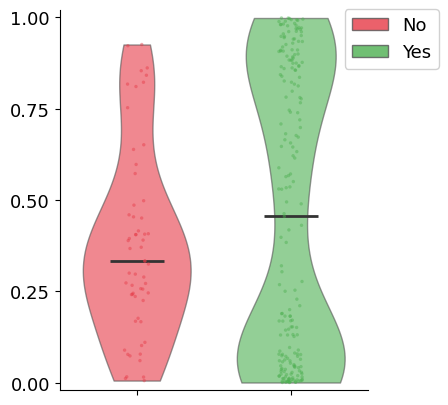

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

EXCEL_FILE = "/home/yujieq/work/ML_training/VALANCE/plots/Supplemental_Tables_Final.xlsx"
SHEET_NAME = "Fig_6D"
OUTPUT_PNG = "/home/yujieq/work/ML_training/VALANCE/plots/Fig_6D_prob_resistant_by_correctness.png"

# Colors for the two groups (red = incorrect, green = correct - consistent
GROUP_COLORS = {"No": "#E63946", "Yes": "#4CAF50"}

 
df = pd.read_excel(EXCEL_FILE, sheet_name=SHEET_NAME)
df = df.dropna(subset=['GT Label', 'Prediction', 'Prob_Resistant']).copy()


df['correct'] = np.where(df['GT Label'] == df['Prediction'], 'Yes', 'No')

labels = ['No', 'Yes']
data = [df.loc[df['correct'] == g, 'Prob_Resistant'].values for g in labels]

print(f"No (incorrect):  n = {len(data[0])}")
print(f"Yes (correct):   n = {len(data[1])}")


fig, ax = plt.subplots(figsize=(4, 5))
fig.subplots_adjust(left=0.18, right=0.95, bottom=0.12)

parts = ax.violinplot(data, positions=range(len(labels)),
                       showmedians=True, showextrema=False, widths=0.7)

for body, g in zip(parts['bodies'], labels):
    color = GROUP_COLORS[g]
    body.set_facecolor(color)
    body.set_edgecolor('#555555')
    body.set_alpha(0.6)

parts['cmedians'].set_color('#333333')
parts['cmedians'].set_linewidth(2)


rng = np.random.default_rng(42)
for i, (g, vals) in enumerate(zip(labels, data)):
    color = GROUP_COLORS[g]
    jitter = rng.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(i + jitter, vals, s=6, color=color, alpha=0.45,
               zorder=3, edgecolors='none')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels('', fontsize=14)
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylim(-0.02, 1.02)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=13)


group_handles = [mpatches.Patch(facecolor=GROUP_COLORS[g], edgecolor='#555',
                                 label=g, alpha=0.8) for g in labels]
fig.legend(handles=group_handles, fontsize=13, ncol=1, frameon=True,
           framealpha=0.9, edgecolor='#CCCCCC',
           loc='upper right', bbox_to_anchor=(1.15, 0.90))


plt.savefig(OUTPUT_PNG, dpi=800, bbox_inches='tight')
print(f"\n✓ Saved to: {OUTPUT_PNG}")

# FigS1 B

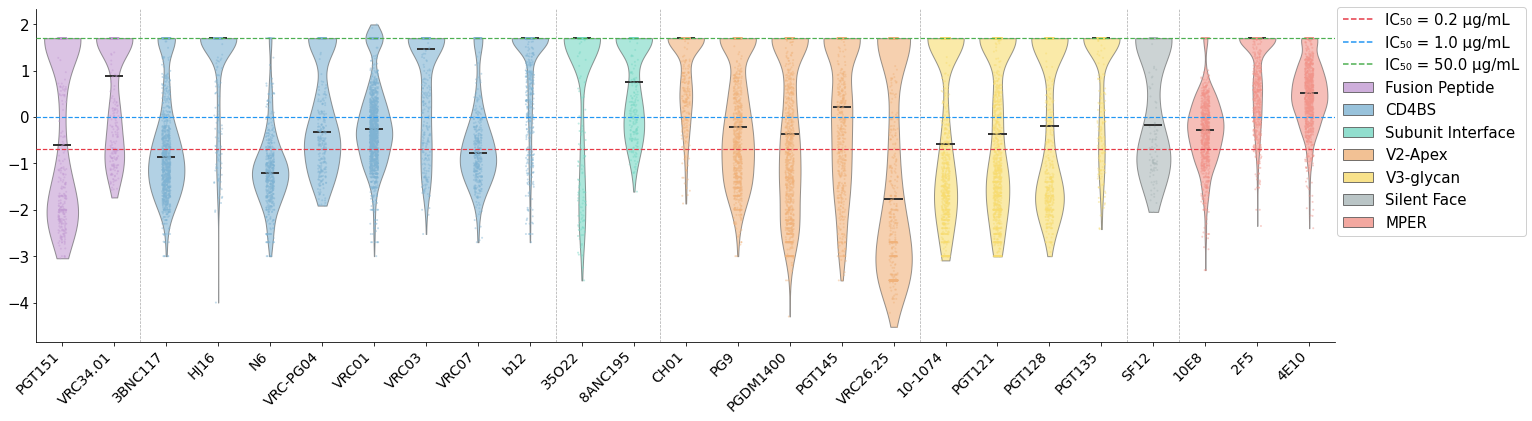

✓ Saved ic50_violin_rug.png


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

DATA_PATH = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
ANTIBODIES_LIST = ['PGT121', 'VRC01', '10-1074', 'PGT145', '3BNC117', 'PGDM1400',
                   'VRC26.25', 'PGT151', 'PG9', '4E10', 'PGT128', 'SF12', 'N6',
                   '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 'VRC34.01',
                   'b12', 'VRC03', 'VRC07', '2F5', '8ANC195']

# EPITOPE_ORDER = [
#     "FUSION_PEPTIDE", "GP120_CD4BS", "GP41-GP120_INTERFACE",
#     "GP120_V2", "GP41-GP41_INTERFACE", "GP120_V3",
#     "GP120_SILENT", "GP41_MPER",
# ]

EPITOPE_ORDER = [
    "FUSION_PEPTIDE", "GP120_CD4BS", "SUBUNIT_INTERFACE",
    "GP120_V2", "GP120_V3", "GP120_SILENT", "GP41_MPER",
]

EPITOPE_DISPLAY = {
    "FUSION_PEPTIDE":    "Fusion Peptide",
    "GP120_CD4BS":       "CD4BS",
    "SUBUNIT_INTERFACE": "Subunit Interface",
    "GP120_V2":          "V2-Apex",
    "GP120_V3":          "V3-glycan",
    "GP120_SILENT":      "Silent Face",
    "GP41_MPER":         "MPER",
}


# EPITOPE_COLORS = {
#     "FUSION_PEPTIDE":        "#C39BD3",
#     "GP120_CD4BS":           "#7FB3D3",
#     "GP41-GP120_INTERFACE":  "#76D7C4",
#     "GP120_V2":              "#F0B27A",
#     "GP41-GP41_INTERFACE":   "#EC7063",
#     "GP120_V3":              "#F7DC6F",
#     "GP120_SILENT":          "#AAB7B8",
#     "GP41_MPER":             "#F1948A",
# }

EPITOPE_COLORS = {
    "FUSION_PEPTIDE":        "#C39BD3",
    "GP120_CD4BS":           "#7FB3D3",
    "GP41-GP120_INTERFACE":  "#76D7C4",
    "GP120_V2":              "#F0B27A",
    "GP41-GP41_INTERFACE":   "#76D7C4",
    "GP120_V3":              "#F7DC6F",
    "GP120_SILENT":          "#AAB7B8",
    "GP41_MPER":             "#F1948A",
    "SUBUNIT_INTERFACE":     "#76D7C4",   
}

# EPITOPE_COLORS = {
#     "Fusion Peptide":        "#C39BD3",
#     "CD4BS":           "#7FB3D3",
#     "Subunit Interface":  "#76D7C4",
#     "V2-Apex":              "#F0B27A",
#     "V3-glycan":              "#F7DC6F",
#     "Silent Face":          "#AAB7B8",
#     "MPER":             "#F1948A",
# }

THR_LOG = {0.2: np.log10(0.2), 1.0: np.log10(1.0), 50.0: np.log10(50.0)}
THR_COLORS = {0.2: "#E63946", 1.0: "#2196F3", 50.0: "#4CAF50"}

# ── Load & sort ────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, sep="\t")
df["IC50"] = pd.to_numeric(df["IC50"], errors="coerce")
df = df.dropna(subset=["IC50"])

epitope_map = (df[["Antibody", "epitope"]].drop_duplicates()
               .set_index("Antibody")["epitope"].str.strip().to_dict())

EPITOPE_MERGE = {
    "GP41-GP120_INTERFACE": "SUBUNIT_INTERFACE",
    "GP41-GP41_INTERFACE":  "SUBUNIT_INTERFACE",
}
def merged_epitope(ab):
    epi = epitope_map.get(ab, "")
    return EPITOPE_MERGE.get(epi, epi)

def epi_key(ab):
    epi = merged_epitope(ab)
    idx = EPITOPE_ORDER.index(epi) if epi in EPITOPE_ORDER else len(EPITOPE_ORDER)
    return (idx, ab)


antibodies = sorted(ANTIBODIES_LIST, key=epi_key)

x_grid = np.linspace(-5, 3, 500)   # log10 IC50 range




# Violin + rug (jittered dots along y-axis)

fig3, ax3 = plt.subplots(figsize=(22, 7))
fig3.subplots_adjust(left=0.05, right=0.87, bottom=0.22)

ic50_data = [np.log10(df.loc[df["Antibody"] == ab, "IC50"].values)
             for ab in antibodies]
# epitope_labels = [epitope_map.get(ab, "") for ab in antibodies]
epitope_labels = [EPITOPE_DISPLAY.get(merged_epitope(ab), merged_epitope(ab))
                  for ab in antibodies]

parts = ax3.violinplot(ic50_data, positions=range(len(antibodies)),
                       showmedians=True, showextrema=False, widths=0.7)

for i, (body, ab) in enumerate(zip(parts["bodies"], antibodies)):
    epi   = epitope_map.get(ab, "")
    color = EPITOPE_COLORS.get(epi, "#CCCCCC")
    body.set_facecolor(color)
    body.set_edgecolor("#555555")
    body.set_alpha(0.6)

parts["cmedians"].set_color("#333333")
parts["cmedians"].set_linewidth(2)

# jittered rug points
rng = np.random.default_rng(42)
for i, (ab, vals) in enumerate(zip(antibodies, ic50_data)):
    epi   = epitope_map.get(ab, "")
    color = EPITOPE_COLORS.get(epi, "#CCCCCC")
    jitter = rng.uniform(-0.08, 0.08, size=len(vals))
    ax3.scatter(i + jitter, vals, s=4, color=color,
                alpha=0.45, zorder=3, edgecolors="none")

# threshold lines
for thr, tlog in THR_LOG.items():
    ax3.axhline(tlog, color=THR_COLORS[thr], linewidth=1.2,
                linestyle="--", zorder=5, label=f"IC₅₀ = {thr} µg/mL")

# epitope dividers + labels
prev_epi, group_starts = None, []
for i, epi in enumerate(epitope_labels):
    if epi != prev_epi:
        if i > 0:
            ax3.axvline(i - 0.5, color="#AAAAAA", linewidth=0.7,
                        linestyle="--", zorder=0)
        group_starts.append((i, epi))
        prev_epi = epi

ymax = ax3.get_ylim()[1]
for idx, (start, epi) in enumerate(group_starts):
    end = group_starts[idx+1][0] if idx+1 < len(group_starts) else len(antibodies)
    mid = (start + end - 1) / 2
#     ax3.text(mid, ymax * 0.99, epi, ha="center", va="top",
#              fontsize=11, color="#444", style="italic",
#              bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1))

ax3.set_xticks(range(len(antibodies)))
ax3.set_xticklabels(antibodies, rotation=45, ha="right", fontsize=14)
# ax3.set_ylabel("log₁₀(IC₅₀)  [µg/mL]", fontsize=11)
ax3.set_xlim(-0.5, len(antibodies) - 0.5)
ax3.spines[["top", "right"]].set_visible(False)
# ax3.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.4, zorder=0)
ax3.tick_params(axis="y", labelsize=15)

thr_handles = [plt.Line2D([0],[0], color=THR_COLORS[t], linewidth=1.5,
                           linestyle="--", label=f"IC₅₀ = {t} µg/mL")
               for t in THR_LOG]
epi_handles = [mpatches.Patch(facecolor=EPITOPE_COLORS.get(e, "#DDD"),
                               edgecolor="#555",
                               label=EPITOPE_DISPLAY.get(e, e), alpha=0.8)
               for e in EPITOPE_ORDER
               if any(merged_epitope(ab) == e for ab in antibodies)]

fig3.legend(handles=thr_handles + epi_handles, fontsize=15, ncol=1,
            frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
            loc="upper right", bbox_to_anchor=(0.995, 0.90))


plt.savefig("/Users/YUQIAO/blackbox/VALANCE/plots/ic50_violin_rug.png",
            bbox_inches="tight", dpi=800)
plt.show()
print("✓ Saved ic50_violin_rug.png")

# FigS2

### Cross validation

#### cutoff 50.0

In [103]:
"""
Statistical comparison of bNAb-ReP, BRAVE, and VALANCE
=======================================================
Two approaches:
  A) Win-count analysis: chi-square + pairwise binomial tests
  - Win count test (directly on what you see): Chi-square goodness-of-fit tests if wins are distributed non-uniformly across models, then pairwise binomial tests between models.
      - Chi-square goodness-of-fit: H₀ = all 3 models win equally often (~8-9 times each out of 25). A significant result means the win distribution is non-uniform. This is the direct test of what the table shows.
      - Pairwise binomial: for each model pair, treats wins as coin flips and tests if one model wins significantly more than 50% of head-to-head matchups. Bonferroni not applied here since the wins are already counts.
  B) Friedman + pairwise Wilcoxon on raw metric scores (more powerful)
  - Friedman + Wilcoxon on raw scores (more powerful): Uses the full metric values (not just who won), paired by antibody — this is the statistically rigorous approach since it uses all available information rather than just rank 1.
      - Uses the full metric values (e.g., 0.69 vs 0.66), not just who won. Much more sensitive since it retains magnitude information.
      - Post-hoc Wilcoxon only runs when Friedman is significant, with Bonferroni correction across 3 pairs.
"""

import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
METRICS    = ["MCC", "ACC", "AUC", "F1"]
MODELS     = ["bNAb-ReP", "BRAVE", "VALANCE"]
COL_PREFIX = {"bNAb-ReP": "bNab-rep", "BRAVE": "BRAVE", "VALANCE": "VALANCE"}
THRESHOLD  = 50.0   

# Parse Excel 
# Table format: rows 1-2 are header (merged metric + sub-model headers),
# data starts row 3; last row is "Number of Wins" — drop it.
raw = pd.read_excel(XLSX_PATH, sheet_name="Fig_1c", header=None, skiprows=2)
raw = raw.iloc[:, :15]
raw.columns = [
    "Antibody", "Epitope", "Threshold",
    "bNab-rep MCC", "BRAVE MCC",    "VALANCE MCC",
    "bNab-rep ACC", "BRAVE ACC",    "VALANCE ACC",
    "bNab-rep AUC", "BRAVE AUC",    "VALANCE AUC",
    "bNab-rep F1",  "BRAVE F1",     "VALANCE F1",
]
raw = raw[raw["Antibody"].notna() & (raw["Antibody"] != "Number of Wins")].copy()
raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")

def parse_mean(val):
    try:    return float(str(val).split("(")[0])
    except: return np.nan

sub = raw[raw["Threshold"] == THRESHOLD].copy()
for metric in METRICS:
    for model in MODELS:
        col = f"{COL_PREFIX[model]} {metric}"
        sub[f"{model}_{metric}"] = [parse_mean(v) for v in sub[col].tolist()]

n_ab = len(sub)
pairs = list(combinations(MODELS, 2))

print(f"\n{'='*65}")
print(f"Model comparison at threshold = {THRESHOLD} µg/mL  (n={n_ab} antibodies)")
print(f"{'='*65}")

for metric in METRICS:
    score_cols = [f"{m}_{metric}" for m in MODELS]
    df = sub[["Antibody"] + score_cols].dropna()
    n  = len(df)

    print(f"\n── {metric} (n={n} antibodies) ──────────────────────────────")


    # A: Win count analysis — based on mean values only, ties excluded
    scores = df[score_cols].values   # shape (n, 3)
    wins   = np.zeros(3, dtype=int)
    n_ties = 0
    for row in scores:
        if np.isnan(row).any():
            continue
        max_val = row.max()
        winners = np.where(row == max_val)[0]
        if len(winners) == 1:
            wins[winners[0]] += 1
        else:
            for w in winners:          # tie — +1 to each tied model
                wins[w] += 1
    
    print(f"\n  [A] Win counts: "
          + "  ".join(f"{m}={w}" for m, w in zip(MODELS, wins)))

    # Chi-square goodness-of-fit: H0 = wins uniformly distributed
    chi2, p_chi2 = stats.chisquare(wins)
    p_str = f"{p_chi2:.4f}" if p_chi2 >= 0.0001 else "<0.0001"
    sig   = " *" if p_chi2 < 0.05 else ""
    print(f"  Chi-square (uniform wins): χ²={chi2:.3f}, p={p_str}{sig}")

    # Pairwise binomial: for each pair, test if win counts differ from 50/50
    print(f"  Pairwise binomial (H0: equal wins between two models):")
    for m1, m2 in pairs:
        i1, i2  = MODELS.index(m1), MODELS.index(m2)
        w1, w2  = wins[i1], wins[i2]
        total   = w1 + w2
        if total == 0:
            continue
        p_binom = stats.binomtest(max(w1, w2), total, p=0.5).pvalue
        p_str   = f"{p_binom:.4f}" if p_binom >= 0.0001 else "<0.0001"
        sig     = " *" if p_binom < 0.05 else ""
        print(f"    {m1} ({w1}) vs {m2} ({w2}): p={p_str}{sig}")

    # B: Friedman + Wilcoxon on raw scores
    data_mat = df[score_cols].values   # (n_ab, 3)
    f_stat, f_p = stats.friedmanchisquare(*data_mat.T)
    f_str = f"{f_p:.4f}" if f_p >= 0.0001 else "<0.0001"
    sig   = " *" if f_p < 0.05 else ""
    print(f"\n  [B] Friedman test (raw scores): χ²={f_stat:.3f}, p={f_str}{sig}")

    if f_p < 0.05:
        print(f"  Post-hoc Wilcoxon (Bonferroni-corrected, {len(pairs)} pairs):")
        for m1, m2 in pairs:
            c1 = f"{m1}_{metric}"
            c2 = f"{m2}_{metric}"
            d  = df[[c1, c2]].dropna()
            try:
                _, w_p = stats.wilcoxon(d[c1], d[c2])
            except Exception:
                w_p = np.nan
            w_adj = min(w_p * len(pairs), 1.0) if not np.isnan(w_p) else np.nan
            p_str = f"{w_adj:.4f}" if not np.isnan(w_adj) and w_adj >= 0.0001 else "<0.0001"
            sig   = " *" if (not np.isnan(w_adj) and w_adj < 0.05) else ""
            # report median scores for context
            med1  = d[c1].median()
            med2  = d[c2].median()
            print(f"    {m1} (median={med1:.3f}) vs {m2} (median={med2:.3f}): "
                  f"p_adj={p_str}{sig}")
    else:
        print(f"  Friedman not significant — no post-hoc tests run.")

print(f"\n{'='*65}")
print("* = p < 0.05")
print("Note: win-count tests use only rank information; Friedman uses full scores.")


Model comparison at threshold = 50.0 µg/mL  (n=25 antibodies)

── MCC (n=25 antibodies) ──────────────────────────────

  [A] Win counts: bNAb-ReP=5  BRAVE=2  VALANCE=19
  Chi-square (uniform wins): χ²=19.000, p=<0.0001 *
  Pairwise binomial (H0: equal wins between two models):
    bNAb-ReP (5) vs BRAVE (2): p=0.4531
    bNAb-ReP (5) vs VALANCE (19): p=0.0066 *
    BRAVE (2) vs VALANCE (19): p=0.0002 *

  [B] Friedman test (raw scores): χ²=19.771, p=<0.0001 *
  Post-hoc Wilcoxon (Bonferroni-corrected, 3 pairs):
    bNAb-ReP (median=0.550) vs BRAVE (median=0.570): p_adj=1.0000
    bNAb-ReP (median=0.550) vs VALANCE (median=0.620): p_adj=0.0166 *
    BRAVE (median=0.570) vs VALANCE (median=0.620): p_adj=<0.0001 *

── ACC (n=25 antibodies) ──────────────────────────────

  [A] Win counts: bNAb-ReP=4  BRAVE=6  VALANCE=22
  Chi-square (uniform wins): χ²=18.250, p=0.0001 *
  Pairwise binomial (H0: equal wins between two models):
    bNAb-ReP (4) vs BRAVE (6): p=0.7539
    bNAb-ReP (4) vs VA

/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.


In [100]:
raw

,Antibody,Epitope,Threshold,bNab-rep MCC,BRAVE MCC,VALANCE MCC,bNab-rep ACC,BRAVE ACC,VALANCE ACC,bNab-rep AUC,BRAVE AUC,VALANCE AUC,bNab-rep F1,BRAVE F1,VALANCE F1
0,3BNC117,CD4BS,50.0,0.55(0.01),0.66(0.04),0.69(0.04),0.84(0.00),0.92(0.01),0.93(0.01),0.90(0.02),0.93(0.02),0.94(0.01),0.61(0.01),0.67(0.06),0.71(0.05)
1,b12,CD4BS,50.0,0.51(0.07),0.44(0.11),0.48(0.08),0.77(0.04),0.76(0.04),0.78(0.03),0.85(0.02),0.82(0.05),0.85(0.03),0.81(0.03),0.83(0.03),0.84(0.02)
2,HJ16,CD4BS,50.0,0.25(0.07),-0.01(0.09),0.26(0.12),0.64(0.04),0.71(0.01),0.73(0.04),0.69(0.08),0.63(0.05),0.71(0.10),0.72(0.03),0.83(0.01),0.82(0.03)
3,N6,CD4BS,50.0,0.06(0.08),0.00(0.00),0.07(0.16),0.58(0.12),0.97(0.00),0.97(0.00),0.48(0.07),0.80(0.14),0.93(0.12),0.07(0.05),NaN,0.08(0.16)
4,VRC-PG04,CD4BS,50.0,0.49(0.07),0.57(0.11),0.61(0.10),0.77(0.03),0.84(0.04),0.86(0.03),0.85(0.04),0.88(0.05),0.90(0.03),0.64(0.05),0.57(0.13),0.69(0.08)
5,VRC01,CD4BS,50.0,0.51(0.06),0.58(0.06),0.64(0.05),0.83(0.03),0.92(0.01),0.93(0.01),0.90(0.03),0.90(0.03),0.91(0.02),0.56(0.05),0.58(0.06),0.65(0.04)
6,VRC03,CD4BS,50.0,0.56(0.04),0.51(0.11),0.55(0.11),0.78(0.02),0.75(0.05),0.77(0.05),0.86(0.02),0.85(0.05),0.86(0.05),0.78(0.02),0.76(0.05),0.78(0.05)
7,VRC07,CD4BS,50.0,0.22(0.08),0.29(0.16),0.62(0.10),0.65(0.06),0.92(0.01),0.94(0.01),0.82(0.07),0.88(0.11),0.91(0.04),0.28(0.04),0.24(0.01),0.63(0.09)
8,CH01,V2-APEX,50.0,0.49(0.08),0.50(0.11),0.53(0.05),0.74(0.04),0.75(0.06),0.76(0.02),0.82(0.06),0.80(0.04),0.81(0.05),0.75(0.04),0.76(0.04),0.77(0.02)
9,PG9,V2-APEX,50.0,0.55(0.00),0.44(0.05),0.56(0.08),0.80(0.00),0.81(0.01),0.85(0.02),0.88(0.02),0.86(0.03),0.87(0.02),0.67(0.00),0.49(0.05),0.63(0.07)


#### cutoff 0.2 and 1

In [109]:
"""
Statistical comparison of bNAb-ReP, BRAVE, and VALANCE
=======================================================
Two approaches:
  A) Win-count analysis: chi-square + pairwise binomial tests
  - Win count test (directly on what you see): Chi-square goodness-of-fit tests if wins are distributed non-uniformly across models, then pairwise binomial tests between models.
      - Chi-square goodness-of-fit: H₀ = all 3 models win equally often (~8-9 times each out of 25). A significant result means the win distribution is non-uniform. This is the direct test of what the table shows.
      - Pairwise binomial: for each model pair, treats wins as coin flips and tests if one model wins significantly more than 50% of head-to-head matchups. Bonferroni not applied here since the wins are already counts.
  B) Friedman + pairwise Wilcoxon on raw metric scores (more powerful)
  - Friedman + Wilcoxon on raw scores (more powerful): Uses the full metric values (not just who won), paired by antibody — this is the statistically rigorous approach since it uses all available information rather than just rank 1.
      - Uses the full metric values (e.g., 0.69 vs 0.66), not just who won. Much more sensitive since it retains magnitude information.
      - Post-hoc Wilcoxon only runs when Friedman is significant, with Bonferroni correction across 3 pairs.
"""

import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
METRICS    = ["MCC", "ACC", "AUC", "F1"]
MODELS     = ["bNAb-ReP", "BRAVE", "VALANCE"]
COL_PREFIX = {"bNAb-ReP": "bNab-rep", "BRAVE": "BRAVE", "VALANCE": "VALANCE"}
THRESHOLD  = 0.2   # change to 0.2 or 1.0 to analyze other thresholds

# Parse Excel 
# Table format: rows 1-2 are header (merged metric + sub-model headers),
# data starts row 3; last row is "Number of Wins" — drop it.
raw = pd.read_excel(XLSX_PATH, sheet_name="Supplemental Table 1", header=None, skiprows=2)
raw = raw.iloc[:26, :15] # for cutoff 0.2 ug/mL
# raw = raw.iloc[27:56, :15] # for cutoff 1.0 ug/mL

raw.columns = [
    "Antibody", "Epitope", "Threshold",
    "bNab-rep MCC", "BRAVE MCC",    "VALANCE MCC",
    "bNab-rep ACC", "BRAVE ACC",    "VALANCE ACC",
    "bNab-rep AUC", "BRAVE AUC",    "VALANCE AUC",
    "bNab-rep F1",  "BRAVE F1",     "VALANCE F1",
]
raw = raw[raw["Antibody"].notna() & (raw["Antibody"] != "Number of Wins")].copy()
raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")

def parse_mean(val):
    try:    return float(str(val).split("(")[0])
    except: return np.nan

sub = raw[raw["Threshold"] == THRESHOLD].copy()
for metric in METRICS:
    for model in MODELS:
        col = f"{COL_PREFIX[model]} {metric}"
        sub[f"{model}_{metric}"] = [parse_mean(v) for v in sub[col].tolist()]

n_ab = len(sub)
pairs = list(combinations(MODELS, 2))

print(f"\n{'='*65}")
print(f"Model comparison at threshold = {THRESHOLD} µg/mL  (n={n_ab} antibodies)")
print(f"{'='*65}")

for metric in METRICS:
    score_cols = [f"{m}_{metric}" for m in MODELS]
    df = sub[["Antibody"] + score_cols].dropna()
    n  = len(df)

    print(f"\n── {metric} (n={n} antibodies) ──────────────────────────────")

    # A: Win count analysis — based on mean values only, ties excluded
    scores = df[score_cols].values   # shape (n, 3)
    wins   = np.zeros(3, dtype=int)
    n_ties = 0
    for row in scores:
        if np.isnan(row).any():
            continue
        max_val = row.max()
        winners = np.where(row == max_val)[0]
        if len(winners) == 1:
            wins[winners[0]] += 1
        else:
            for w in winners:          # tie — +1 to each tied model
                wins[w] += 1

    print(f"\n  [A] Win counts: "
          + "  ".join(f"{m}={w}" for m, w in zip(MODELS, wins)))

    # Chi-square goodness-of-fit: H0 = wins uniformly distributed
    chi2, p_chi2 = stats.chisquare(wins)
    p_str = f"{p_chi2:.4f}" if p_chi2 >= 0.0001 else "<0.0001"
    sig   = " *" if p_chi2 < 0.05 else ""
    print(f"  Chi-square (uniform wins): χ²={chi2:.3f}, p={p_str}{sig}")

    # Pairwise binomial: for each pair, test if win counts differ from 50/50
    print(f"  Pairwise binomial (H0: equal wins between two models):")
    for m1, m2 in pairs:
        i1, i2  = MODELS.index(m1), MODELS.index(m2)
        w1, w2  = wins[i1], wins[i2]
        total   = w1 + w2
        if total == 0:
            continue
        p_binom = stats.binomtest(max(w1, w2), total, p=0.5).pvalue
        p_str   = f"{p_binom:.4f}" if p_binom >= 0.0001 else "<0.0001"
        sig     = " *" if p_binom < 0.05 else ""
        print(f"    {m1} ({w1}) vs {m2} ({w2}): p={p_str}{sig}")

    # B: Friedman + Wilcoxon on raw scores
    data_mat = df[score_cols].values   # (n_ab, 3)
    f_stat, f_p = stats.friedmanchisquare(*data_mat.T)
    f_str = f"{f_p:.4f}" if f_p >= 0.0001 else "<0.0001"
    sig   = " *" if f_p < 0.05 else ""
    print(f"\n  [B] Friedman test (raw scores): χ²={f_stat:.3f}, p={f_str}{sig}")

    if f_p < 0.05:
        print(f"  Post-hoc Wilcoxon (Bonferroni-corrected, {len(pairs)} pairs):")
        for m1, m2 in pairs:
            c1 = f"{m1}_{metric}"
            c2 = f"{m2}_{metric}"
            d  = df[[c1, c2]].dropna()
            try:
                _, w_p = stats.wilcoxon(d[c1], d[c2])
            except Exception:
                w_p = np.nan
            w_adj = min(w_p * len(pairs), 1.0) if not np.isnan(w_p) else np.nan
            p_str = f"{w_adj:.4f}" if not np.isnan(w_adj) and w_adj >= 0.0001 else "<0.0001"
            sig   = " *" if (not np.isnan(w_adj) and w_adj < 0.05) else ""
            # report median scores for context
            med1  = d[c1].median()
            med2  = d[c2].median()
            print(f"    {m1} (median={med1:.3f}) vs {m2} (median={med2:.3f}): "
                  f"p_adj={p_str}{sig}")
    else:
        print(f"  Friedman not significant — no post-hoc tests run.")

print(f"\n{'='*65}")
print("* = p < 0.05")
print("Note: win-count tests use only rank information; Friedman uses full scores.")


Model comparison at threshold = 0.2 µg/mL  (n=25 antibodies)

── MCC (n=25 antibodies) ──────────────────────────────

  [A] Win counts: bNAb-ReP=12  BRAVE=1  VALANCE=16
  Chi-square (uniform wins): χ²=12.483, p=0.0019 *
  Pairwise binomial (H0: equal wins between two models):
    bNAb-ReP (12) vs BRAVE (1): p=0.0034 *
    bNAb-ReP (12) vs VALANCE (16): p=0.5716
    BRAVE (1) vs VALANCE (16): p=0.0003 *

  [B] Friedman test (raw scores): χ²=18.468, p=<0.0001 *
  Post-hoc Wilcoxon (Bonferroni-corrected, 3 pairs):
    bNAb-ReP (median=0.350) vs BRAVE (median=0.280): p_adj=0.0824
    bNAb-ReP (median=0.350) vs VALANCE (median=0.390): p_adj=0.4473
    BRAVE (median=0.280) vs VALANCE (median=0.390): p_adj=0.0001 *

── ACC (n=25 antibodies) ──────────────────────────────

  [A] Win counts: bNAb-ReP=3  BRAVE=10  VALANCE=19
  Chi-square (uniform wins): χ²=12.062, p=0.0024 *
  Pairwise binomial (H0: equal wins between two models):
    bNAb-ReP (3) vs BRAVE (10): p=0.0923
    bNAb-ReP (3) vs VA

/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.


In [110]:
raw

,Antibody,Epitope,Threshold,bNab-rep MCC,BRAVE MCC,VALANCE MCC,bNab-rep ACC,BRAVE ACC,VALANCE ACC,bNab-rep AUC,BRAVE AUC,VALANCE AUC,bNab-rep F1,BRAVE F1,VALANCE F1
0,3BNC117,GP120_CD4BS,0.2,0.56(0.03),0.53(0.05),0.53(0.03),0.78(0.02),0.77(0.02),0.77(0.01),0.87(0.01),0.87(0.01),0.86(0.01),0.76(0.02),0.74(0.03),0.73(0.02)
1,b12,GP120_CD4BS,0.2,0.50(0.18),0.71(0.15),0.75(0.10),0.84(0.08),0.96(0.02),0.96(0.01),0.93(0.05),0.94(0.05),0.92(0.06),0.91(0.05),0.98(0.01),0.98(0.01)
2,HJ16,GP120_CD4BS,0.2,0.05(0.06),0.00(0.00),0.34(0.20),0.54(0.05),0.89(0.01),0.90(0.02),0.60(0.09),0.63(0.12),0.74(0.07),0.67(0.04),0.94(0.00),0.95(0.01)
3,N6,GP120_CD4BS,0.2,0.18(0.05),0.26(0.10),0.35(0.08),0.60(0.03),0.80(0.02),0.81(0.02),0.65(0.02),0.73(0.05),0.78(0.03),0.40(0.03),0.19(0.11),0.42(0.10)
4,VRC-PG04,GP120_CD4BS,0.2,0.22(0.16),0.27(0.09),0.40(0.16),0.62(0.08),0.71(0.03),0.74(0.07),0.68(0.07),0.68(0.14),0.77(0.06),0.68(0.08),0.82(0.02),0.82(0.05)
5,VRC01,GP120_CD4BS,0.2,0.44(0.07),0.39(0.05),0.44(0.02),0.74(0.04),0.79(0.01),0.80(0.01),0.82(0.02),0.79(0.02),0.80(0.02),0.81(0.03),0.87(0.01),0.87(0.00)
6,VRC03,GP120_CD4BS,0.2,0.32(0.06),0.29(0.18),0.38(0.05),0.70(0.03),0.84(0.02),0.84(0.02),0.77(0.05),0.82(0.04),0.80(0.03),0.79(0.03),0.91(0.01),0.90(0.01)
7,VRC07,GP120_CD4BS,0.2,0.26(0.10),0.25(0.12),0.34(0.08),0.63(0.05),0.63(0.06),0.67(0.04),0.69(0.09),0.69(0.09),0.72(0.04),0.61(0.05),0.57(0.08),0.63(0.06)
8,CH01,GP120_V2,0.2,0.28(0.06),0.00(0.00),0.22(0.20),0.77(0.03),0.95(0.01),0.95(0.01),0.82(0.10),0.65(0.08),0.86(0.06),0.87(0.02),0.97(0.00),0.97(0.00)
9,PG9,GP120_V2,0.2,0.40(0.04),0.31(0.06),0.41(0.08),0.71(0.02),0.70(0.02),0.73(0.04),0.78(0.03),0.76(0.04),0.81(0.04),0.76(0.02),0.79(0.01),0.80(0.03)


### Independent test

#### cutoff 50.0

In [116]:
"""
Statistical comparison of bNAb-ReP, BRAVE, and VALANCE
=======================================================
Two approaches:
  A) Win-count analysis: chi-square + pairwise binomial tests
  - Win count test (directly on what you see): Chi-square goodness-of-fit tests if wins are distributed non-uniformly across models, then pairwise binomial tests between models.
      - Chi-square goodness-of-fit: H₀ = all 3 models win equally often (~8-9 times each out of 25). A significant result means the win distribution is non-uniform. This is the direct test of what the table shows.
      - Pairwise binomial: for each model pair, treats wins as coin flips and tests if one model wins significantly more than 50% of head-to-head matchups. Bonferroni not applied here since the wins are already counts.
  B) Friedman + pairwise Wilcoxon on raw metric scores (more powerful)
  - Friedman + Wilcoxon on raw scores (more powerful): Uses the full metric values (not just who won), paired by antibody — this is the statistically rigorous approach since it uses all available information rather than just rank 1.
      - Uses the full metric values (e.g., 0.69 vs 0.66), not just who won. Much more sensitive since it retains magnitude information.
      - Post-hoc Wilcoxon only runs when Friedman is significant, with Bonferroni correction across 3 pairs.
"""

import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
METRICS    = ["MCC", "ACC", "AUC", "F1"]
MODELS     = ["bNAb-ReP", "BRAVE", "VALANCE"]
COL_PREFIX = {"bNAb-ReP": "bNab-rep", "BRAVE": "BRAVE", "VALANCE": "VALANCE"}
THRESHOLD  = 50.0   # change to 0.2 or 1.0 to analyze other thresholds

# antibodies excluded due to fewer than 10 prediction strains
EXCLUDE_ABS = ["VRC07", "VRC34.01", "8ANC195"]

# Parse Excel 
# Table format: rows 1-2 are header (merged metric + sub-model headers),
# data starts row 3; last row is "Number of Wins" — drop it.
raw = pd.read_excel(XLSX_PATH, sheet_name="Fig_4A", header=None, skiprows=2)
raw = raw.iloc[:, :17]
raw.columns = [
    "Antibody", "Epitope", "Threshold","Number of training strains", "Number of prediction strains",
    "bNab-rep MCC", "BRAVE MCC",    "VALANCE MCC",
    "bNab-rep ACC", "BRAVE ACC",    "VALANCE ACC",
    "bNab-rep AUC", "BRAVE AUC",    "VALANCE AUC",
    "bNab-rep F1",  "BRAVE F1",     "VALANCE F1",
]
raw = raw[raw["Antibody"].notna() & (raw["Antibody"] != "Number of Wins")].copy()
raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")

def parse_mean(val):
    try:    return float(str(val).split("(")[0])
    except: return np.nan

sub = raw[raw["Threshold"] == THRESHOLD].copy()
sub = sub[~sub["Antibody"].isin(EXCLUDE_ABS)]

for metric in METRICS:
    for model in MODELS:
        col = f"{COL_PREFIX[model]} {metric}"
        sub[f"{model}_{metric}"] = [parse_mean(v) for v in sub[col].tolist()]

n_ab = len(sub)
pairs = list(combinations(MODELS, 2))

print(f"\n{'='*65}")
print(f"Model comparison at threshold = {THRESHOLD} µg/mL  (n={n_ab} antibodies)")
print(f"{'='*65}")

for metric in METRICS:
    score_cols = [f"{m}_{metric}" for m in MODELS]
    df = sub[["Antibody"] + score_cols].dropna()
    n  = len(df)

    print(f"\n── {metric} (n={n} antibodies) ──────────────────────────────")

    # A: Win count analysis — based on mean values only, ties excluded
    scores = df[score_cols].values   # shape (n, 3)
    wins   = np.zeros(3, dtype=int)
    n_ties = 0
    for row in scores:
        if np.isnan(row).any():
            continue
        max_val = row.max()
        winners = np.where(row == max_val)[0]
        if len(winners) == 1:
            wins[winners[0]] += 1
        else:
            for w in winners:          # tie — +1 to each tied model
                wins[w] += 1

    print(f"\n  [A] Win counts: "
          + "  ".join(f"{m}={w}" for m, w in zip(MODELS, wins)))

    # Chi-square goodness-of-fit: H0 = wins uniformly distributed
    chi2, p_chi2 = stats.chisquare(wins)
    p_str = f"{p_chi2:.4f}" if p_chi2 >= 0.0001 else "<0.0001"
    sig   = " *" if p_chi2 < 0.05 else ""
    print(f"  Chi-square (uniform wins): χ²={chi2:.3f}, p={p_str}{sig}")

    # Pairwise binomial: for each pair, test if win counts differ from 50/50
    print(f"  Pairwise binomial (H0: equal wins between two models):")
    for m1, m2 in pairs:
        i1, i2  = MODELS.index(m1), MODELS.index(m2)
        w1, w2  = wins[i1], wins[i2]
        total   = w1 + w2
        if total == 0:
            continue
        p_binom = stats.binomtest(max(w1, w2), total, p=0.5).pvalue
        p_str   = f"{p_binom:.4f}" if p_binom >= 0.0001 else "<0.0001"
        sig     = " *" if p_binom < 0.05 else ""
        print(f"    {m1} ({w1}) vs {m2} ({w2}): p={p_str}{sig}")

    # B: Friedman + Wilcoxon on raw scores
    data_mat = df[score_cols].values   # (n_ab, 3)
    f_stat, f_p = stats.friedmanchisquare(*data_mat.T)
    f_str = f"{f_p:.4f}" if f_p >= 0.0001 else "<0.0001"
    sig   = " *" if f_p < 0.05 else ""
    print(f"\n  [B] Friedman test (raw scores): χ²={f_stat:.3f}, p={f_str}{sig}")

    if f_p < 0.05:
        print(f"  Post-hoc Wilcoxon (Bonferroni-corrected, {len(pairs)} pairs):")
        for m1, m2 in pairs:
            c1 = f"{m1}_{metric}"
            c2 = f"{m2}_{metric}"
            d  = df[[c1, c2]].dropna()
            try:
                _, w_p = stats.wilcoxon(d[c1], d[c2])
            except Exception:
                w_p = np.nan
            w_adj = min(w_p * len(pairs), 1.0) if not np.isnan(w_p) else np.nan
            p_str = f"{w_adj:.4f}" if not np.isnan(w_adj) and w_adj >= 0.0001 else "<0.0001"
            sig   = " *" if (not np.isnan(w_adj) and w_adj < 0.05) else ""
            # report median scores for context
            med1  = d[c1].median()
            med2  = d[c2].median()
            print(f"    {m1} (median={med1:.3f}) vs {m2} (median={med2:.3f}): "
                  f"p_adj={p_str}{sig}")
    else:
        print(f"  Friedman not significant — no post-hoc tests run.")

print(f"\n{'='*65}")
print("* = p < 0.05")
print("Note: win-count tests use only rank information; Friedman uses full scores.")


Model comparison at threshold = 50.0 µg/mL  (n=22 antibodies)

── MCC (n=22 antibodies) ──────────────────────────────

  [A] Win counts: bNAb-ReP=6  BRAVE=3  VALANCE=15
  Chi-square (uniform wins): χ²=9.750, p=0.0076 *
  Pairwise binomial (H0: equal wins between two models):
    bNAb-ReP (6) vs BRAVE (3): p=0.5078
    bNAb-ReP (6) vs VALANCE (15): p=0.0784
    BRAVE (3) vs VALANCE (15): p=0.0075 *

  [B] Friedman test (raw scores): χ²=11.595, p=0.0030 *
  Post-hoc Wilcoxon (Bonferroni-corrected, 3 pairs):
    bNAb-ReP (median=0.360) vs BRAVE (median=0.180): p_adj=0.0319 *
    bNAb-ReP (median=0.360) vs VALANCE (median=0.475): p_adj=0.1485
    BRAVE (median=0.180) vs VALANCE (median=0.475): p_adj=0.0013 *

── ACC (n=22 antibodies) ──────────────────────────────

  [A] Win counts: bNAb-ReP=2  BRAVE=6  VALANCE=19
  Chi-square (uniform wins): χ²=17.556, p=0.0002 *
  Pairwise binomial (H0: equal wins between two models):
    bNAb-ReP (2) vs BRAVE (6): p=0.2891
    bNAb-ReP (2) vs VALANCE 

/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.


#### cutoff 0.2 and 1

In [123]:
"""
Statistical comparison of bNAb-ReP, BRAVE, and VALANCE
=======================================================
Two approaches:
  A) Win-count analysis: chi-square + pairwise binomial tests
  - Win count test (directly on what you see): Chi-square goodness-of-fit tests if wins are distributed non-uniformly across models, then pairwise binomial tests between models.
      - Chi-square goodness-of-fit: H₀ = all 3 models win equally often (~8-9 times each out of 25). A significant result means the win distribution is non-uniform. This is the direct test of what the table shows.
      - Pairwise binomial: for each model pair, treats wins as coin flips and tests if one model wins significantly more than 50% of head-to-head matchups. Bonferroni not applied here since the wins are already counts.
  B) Friedman + pairwise Wilcoxon on raw metric scores (more powerful)
  - Friedman + Wilcoxon on raw scores (more powerful): Uses the full metric values (not just who won), paired by antibody — this is the statistically rigorous approach since it uses all available information rather than just rank 1.
      - Uses the full metric values (e.g., 0.69 vs 0.66), not just who won. Much more sensitive since it retains magnitude information.
      - Post-hoc Wilcoxon only runs when Friedman is significant, with Bonferroni correction across 3 pairs.
"""

import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
METRICS    = ["MCC", "ACC", "AUC", "F1"]
MODELS     = ["bNAb-ReP", "BRAVE", "VALANCE"]
COL_PREFIX = {"bNAb-ReP": "bNab-rep", "BRAVE": "BRAVE", "VALANCE": "VALANCE"}
THRESHOLD  = 1.0   # change to 0.2 or 1.0 to analyze other thresholds

# antibodies excluded due to fewer than 10 prediction strains
EXCLUDE_ABS = ["VRC07", "VRC34.01", "8ANC195"]

# Parse Excel
# Table format: rows 1-2 are header (merged metric + sub-model headers),
# data starts row 3; last row is "Number of Wins" — drop it.
raw = pd.read_excel(XLSX_PATH, sheet_name="Supplemental Table 3", header=None, skiprows=2)
raw = raw.iloc[:26, :17] # for cutoff 1.0 ug/mL
# raw = raw.iloc[25:56, :17] # for cutoff 0.2 ug/mL

raw.columns = [
    "Antibody", "Epitope", "Threshold","Number of training strains", "Number of prediction strains",
    "bNab-rep MCC", "BRAVE MCC",    "VALANCE MCC",
    "bNab-rep ACC", "BRAVE ACC",    "VALANCE ACC",
    "bNab-rep AUC", "BRAVE AUC",    "VALANCE AUC",
    "bNab-rep F1",  "BRAVE F1",     "VALANCE F1",
]
raw = raw[raw["Antibody"].notna() & (raw["Antibody"] != "Number of Wins")].copy()
raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")

def parse_mean(val):
    try:    return float(str(val).split("(")[0])
    except: return np.nan


sub = raw[raw["Threshold"] == THRESHOLD].copy()
sub = sub[~sub["Antibody"].isin(EXCLUDE_ABS)]

for metric in METRICS:
    for model in MODELS:
        col = f"{COL_PREFIX[model]} {metric}"
        sub[f"{model}_{metric}"] = [parse_mean(v) for v in sub[col].tolist()]

n_ab = len(sub)
pairs = list(combinations(MODELS, 2))

print(f"\n{'='*65}")
print(f"Model comparison at threshold = {THRESHOLD} µg/mL  (n={n_ab} antibodies)")
print(f"{'='*65}")

for metric in METRICS:
    score_cols = [f"{m}_{metric}" for m in MODELS]
    df = sub[["Antibody"] + score_cols].dropna()
    n  = len(df)

    print(f"\n── {metric} (n={n} antibodies) ──────────────────────────────")

    # A: Win count analysis — based on mean values only, ties excluded
    scores = df[score_cols].values   # shape (n, 3)
    wins   = np.zeros(3, dtype=int)
    n_ties = 0
    for row in scores:
        if np.isnan(row).any():
            continue
        max_val = row.max()
        winners = np.where(row == max_val)[0]
        if len(winners) == 1:
            wins[winners[0]] += 1
        else:
            for w in winners:          # tie — +1 to each tied model
                wins[w] += 1

    print(f"\n  [A] Win counts: "
          + "  ".join(f"{m}={w}" for m, w in zip(MODELS, wins)))

    # Chi-square goodness-of-fit: H0 = wins uniformly distributed
    chi2, p_chi2 = stats.chisquare(wins)
    p_str = f"{p_chi2:.4f}" if p_chi2 >= 0.0001 else "<0.0001"
    sig   = " *" if p_chi2 < 0.05 else ""
    print(f"  Chi-square (uniform wins): χ²={chi2:.3f}, p={p_str}{sig}")

    # Pairwise binomial: for each pair, test if win counts differ from 50/50
    print(f"  Pairwise binomial (H0: equal wins between two models):")
    for m1, m2 in pairs:
        i1, i2  = MODELS.index(m1), MODELS.index(m2)
        w1, w2  = wins[i1], wins[i2]
        total   = w1 + w2
        if total == 0:
            continue
        p_binom = stats.binomtest(max(w1, w2), total, p=0.5).pvalue
        p_str   = f"{p_binom:.4f}" if p_binom >= 0.0001 else "<0.0001"
        sig     = " *" if p_binom < 0.05 else ""
        print(f"    {m1} ({w1}) vs {m2} ({w2}): p={p_str}{sig}")

    # B: Friedman + Wilcoxon on raw scores 
    data_mat = df[score_cols].values   # (n_ab, 3)
    f_stat, f_p = stats.friedmanchisquare(*data_mat.T)
    f_str = f"{f_p:.4f}" if f_p >= 0.0001 else "<0.0001"
    sig   = " *" if f_p < 0.05 else ""
    print(f"\n  [B] Friedman test (raw scores): χ²={f_stat:.3f}, p={f_str}{sig}")

    if f_p < 0.05:
        print(f"  Post-hoc Wilcoxon (Bonferroni-corrected, {len(pairs)} pairs):")
        for m1, m2 in pairs:
            c1 = f"{m1}_{metric}"
            c2 = f"{m2}_{metric}"
            d  = df[[c1, c2]].dropna()
            try:
                _, w_p = stats.wilcoxon(d[c1], d[c2])
            except Exception:
                w_p = np.nan
            w_adj = min(w_p * len(pairs), 1.0) if not np.isnan(w_p) else np.nan
            p_str = f"{w_adj:.4f}" if not np.isnan(w_adj) and w_adj >= 0.0001 else "<0.0001"
            sig   = " *" if (not np.isnan(w_adj) and w_adj < 0.05) else ""
            # report median scores for context
            med1  = d[c1].median()
            med2  = d[c2].median()
            print(f"    {m1} (median={med1:.3f}) vs {m2} (median={med2:.3f}): "
                  f"p_adj={p_str}{sig}")
    else:
        print(f"  Friedman not significant — no post-hoc tests run.")

print(f"\n{'='*65}")
print("* = p < 0.05")
print("Note: win-count tests use only rank information; Friedman uses full scores.")


Model comparison at threshold = 1.0 µg/mL  (n=22 antibodies)

── MCC (n=22 antibodies) ──────────────────────────────

  [A] Win counts: bNAb-ReP=6  BRAVE=3  VALANCE=16
  Chi-square (uniform wins): χ²=11.120, p=0.0038 *
  Pairwise binomial (H0: equal wins between two models):
    bNAb-ReP (6) vs BRAVE (3): p=0.5078
    bNAb-ReP (6) vs VALANCE (16): p=0.0525
    BRAVE (3) vs VALANCE (16): p=0.0044 *

  [B] Friedman test (raw scores): χ²=14.952, p=0.0006 *
  Post-hoc Wilcoxon (Bonferroni-corrected, 3 pairs):
    bNAb-ReP (median=0.350) vs BRAVE (median=0.020): p_adj=0.0141 *
    bNAb-ReP (median=0.350) vs VALANCE (median=0.450): p_adj=0.0411 *
    BRAVE (median=0.020) vs VALANCE (median=0.450): p_adj=0.0004 *

── ACC (n=22 antibodies) ──────────────────────────────

  [A] Win counts: bNAb-ReP=5  BRAVE=6  VALANCE=17
  Chi-square (uniform wins): χ²=9.500, p=0.0087 *
  Pairwise binomial (H0: equal wins between two models):
    bNAb-ReP (5) vs BRAVE (6): p=1.0000
    bNAb-ReP (5) vs VALANCE

/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/YUQIAO/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.


In [124]:
raw

,Antibody,Epitope,Threshold,Number of training strains,Number of prediction strains,bNab-rep MCC,BRAVE MCC,VALANCE MCC,bNab-rep ACC,BRAVE ACC,VALANCE ACC,bNab-rep AUC,BRAVE AUC,VALANCE AUC,bNab-rep F1,BRAVE F1,VALANCE F1
0,3BNC117,CD4BS,1.0,1086.0,246.0,0.43,0.44,0.39,0.75,0.8,0.79,0.78,0.79,0.77,0.6,0.44,0.41
1,b12,CD4BS,1.0,874.0,134.0,0.61,0.0,0.89,0.84,0.84,0.97,0.98,0.97,0.97,0.89,0.91,0.98
2,HJ16,CD4BS,1.0,328.0,50.0,0.41,0.0,0.0,0.76,0.8,0.8,0.76,0.46,0.73,0.84,0.89,0.89
3,N6,CD4BS,1.0,530.0,57.0,0.22,0.0,0.41,0.65,0.75,0.81,0.7,0.82,0.83,0.44,0.0,0.35
4,VRC-PG04,CD4BS,1.0,321.0,55.0,0.19,0.21,0.18,0.47,0.65,0.49,0.68,0.65,0.68,0.29,0.77,0.36
5,VRC01,CD4BS,1.0,1440.0,270.0,0.43,0.25,0.43,0.71,0.63,0.68,0.77,0.68,0.79,0.71,0.68,0.6
6,VRC03,CD4BS,1.0,375.0,113.0,-0.01,0.04,0.17,0.4,0.65,0.61,0.56,0.6,0.64,0.26,0.78,0.69
7,CH01,V2-APEX,1.0,412.0,104.0,0.11,0.0,0.4,0.35,0.85,0.88,0.49,0.79,0.92,0.39,0.92,0.93
8,PG9,V2-APEX,1.0,915.0,207.0,0.41,0.17,0.4,0.68,0.62,0.68,0.81,0.77,0.81,0.68,0.76,0.69
9,PGDM1400,V2-APEX,1.0,1171.0,123.0,0.43,0.12,0.5,0.74,0.63,0.75,0.78,0.69,0.83,0.8,0.77,0.78


# FigS3

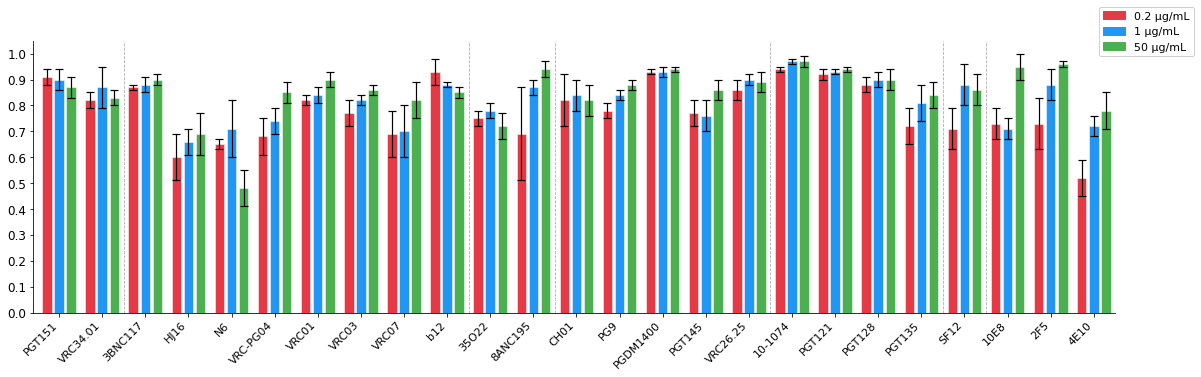

✓ Saved /Users/YUQIAO/blackbox/VALANCE/plots/bnab_rep_auc_barplot.png


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
DATA_PATH  = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
METRIC     = "AUC"    # "MCC", "ACC", "AUC", "F1"
MODEL      = "bNAb-ReP"  # "VALANCE", "BRAVE", "bNAb-ReP"
THRESHOLDS = [0.2, 1, 50]
THR_COLORS = {0.2: "#E63946", 1: "#2196F3", 50: "#4CAF50"}
THR_LABELS = {0.2: "0.2 µg/mL", 1: "1 µg/mL", 50: "50 µg/mL"}
ANTIBODIES_LIST = ['PGT121', 'VRC01', '10-1074', 'PGT145', '3BNC117', 'PGDM1400',
                   'VRC26.25', 'PGT151', 'PG9', '4E10', 'PGT128', 'SF12', 'N6',
                   '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 'VRC34.01',
                   'b12', 'VRC03', 'VRC07', '2F5', '8ANC195']


MODEL_COL_PREFIX = {
    "VALANCE":  "VALANCE",
    "BRAVE":    "BRAVE",
    "bNAb-ReP": "bNab-rep",
}
col_prefix = MODEL_COL_PREFIX[MODEL]


raw = pd.read_excel(XLSX_PATH, sheet_name="Fig_2A", header=1)
raw = raw.iloc[:, :14]
raw.columns = [
    "Antibody", "Threshold",
    "bNab-rep MCC", "bNab-rep ACC", "bNab-rep AUC", "bNab-rep F1",
    "BRAVE MCC",    "BRAVE ACC",    "BRAVE AUC",    "BRAVE F1",
    "VALANCE MCC",  "VALANCE ACC",  "VALANCE AUC",  "VALANCE F1",
]
raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")

def parse_mean(val):
    try:    return float(str(val).split("(")[0])
    except: return np.nan

def parse_std(val):
    try:    return float(str(val).split("(")[1].rstrip(")")) if "(" in str(val) else np.nan
    except: return np.nan

target_col = f"{col_prefix} {METRIC}"
vals = raw[target_col].tolist()
raw[f"{MODEL}_{METRIC}_mean"] = [parse_mean(v) for v in vals]
raw[f"{MODEL}_{METRIC}_std"]  = [parse_std(v)  for v in vals]


df_meta = pd.read_csv(DATA_PATH, sep="\t")
epitope_map = (df_meta[["Antibody", "epitope"]].drop_duplicates()
               .set_index("Antibody")["epitope"]
               .str.strip().to_dict())
 
# merge the two interface epitopes into one display group BEFORE sorting
# so antibodies from both sit together and share a single label
EPITOPE_MERGE = {
    "GP41-GP120_INTERFACE": "SUBUNIT_INTERFACE",
    "GP41-GP41_INTERFACE":  "SUBUNIT_INTERFACE",
}
def merged_epitope(ab):
    epi = epitope_map.get(ab, "")
    return EPITOPE_MERGE.get(epi, epi)
 
EPITOPE_ORDER = [
    "FUSION_PEPTIDE", "GP120_CD4BS", "SUBUNIT_INTERFACE",
    "GP120_V2", "GP120_V3", "GP120_SILENT", "GP41_MPER",
]
EPITOPE_DISPLAY = {
    "FUSION_PEPTIDE":    "Fusion Peptide",
    "GP120_CD4BS":       "CD4BS",
    "SUBUNIT_INTERFACE": "Subunit Interface",
    "GP120_V2":          "V2-Apex",
    "GP120_V3":          "V3-glycan",
    "GP120_SILENT":      "GP120 Silent Face",
    "GP41_MPER":         "MPER",
}
 
def epitope_sort_key(ab):
    epi = merged_epitope(ab)
    idx = EPITOPE_ORDER.index(epi) if epi in EPITOPE_ORDER else len(EPITOPE_ORDER)
    return (idx, ab)

all_abs = raw["Antibody"].dropna().unique().tolist()
try:
    all_abs = [ab for ab in ANTIBODIES_LIST if ab in all_abs]
except NameError:
    pass

antibodies    = sorted(all_abs, key=epitope_sort_key)

epitope_labels = [EPITOPE_DISPLAY.get(merged_epitope(ab), merged_epitope(ab))
                  for ab in antibodies]

n_ab  = len(antibodies)
bar_w = 0.22
offsets = np.linspace(-(len(THRESHOLDS)-1)/2, (len(THRESHOLDS)-1)/2,
                      len(THRESHOLDS)) * (bar_w + 0.06)
x = np.arange(n_ab)


fig, ax = plt.subplots(figsize=(18, 5))
fig.subplots_adjust(left=0.025, right=0.86)

for ti, thr in enumerate(THRESHOLDS):
    sub   = raw[raw["Threshold"] == thr].set_index("Antibody")
    means = np.array([sub.loc[ab, f"{MODEL}_{METRIC}_mean"]
                      if ab in sub.index else np.nan for ab in antibodies])
    stds  = np.array([sub.loc[ab, f"{MODEL}_{METRIC}_std"]
                      if ab in sub.index else np.nan for ab in antibodies])
    xpos  = x + offsets[ti]

    ax.bar(xpos, means, width=bar_w, color=THR_COLORS[thr],
           zorder=2, edgecolor="white", linewidth=0.5)
    ax.errorbar(xpos, means, yerr=stds, fmt="none", ecolor="black",
                elinewidth=1.2, capsize=4, capthick=1.2, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(antibodies, rotation=45, ha="right", fontsize=11)
ax.tick_params(axis="y", labelsize=12)


prev_epi, group_starts = None, []
for i, epi in enumerate(epitope_labels):
    if epi != prev_epi:
        if i > 0:
            ax.axvline(i - 0.5, color="#AAAAAA", linewidth=0.8,
                       linestyle="--", zorder=0)
        group_starts.append((i, epi))
        prev_epi = epi

ymax = ax.get_ylim()[1]
for idx, (start, epi) in enumerate(group_starts):
    end = group_starts[idx+1][0] if idx+1 < len(group_starts) else len(antibodies)
    mid = (start + end - 1) / 2
#     ax.text(mid, ymax * 0.98, epi, ha="center", va="top",
#             fontsize=12, color="#555555", style="italic",
#             bbox=dict(facecolor="white", edgecolor="none", alpha=0.0, pad=1))

# ax.set_ylabel(f"{MODEL} {METRIC}", fontsize=13)
ax.yaxis.set_label_coords(-0.03, 0.5)
ax.set_ylim(0, None)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xlim(-0.6, len(antibodies) - 0.5)

fig.legend(
    [plt.Rectangle((0,0),1,1, color=THR_COLORS[t]) for t in THRESHOLDS],
    [THR_LABELS[t] for t in THRESHOLDS],
    title="", fontsize=11, title_fontsize=11,
    frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
    loc="upper right", bbox_to_anchor=(0.925, 0.99))


out = f"/Users/YUQIAO/blackbox/VALANCE/plots/{MODEL.lower().replace('-','_')}_{METRIC.lower()}_barplot.png"
plt.savefig(out, bbox_inches="tight", dpi=800)
plt.show()
print(f"✓ Saved {out}")

# FigS4


Fisher's z-test on |ρ|: VALANCE vs other models (F1 ~ Imbalance)
H0: |ρ_VALANCE| == |ρ_other|  (equal sensitivity to imbalance)

  Threshold 0.2 µg/mL:
    VALANCE (|ρ|=0.692) vs bNAb-ReP (|ρ|=0.147): z=2.337, p=0.019
    VALANCE (|ρ|=0.692) vs BRAVE (|ρ|=0.708): z=-0.102, p=0.919

  Threshold 1 µg/mL:
    VALANCE (|ρ|=0.248) vs bNAb-ReP (|ρ|=0.123): z=0.429, p=0.668
    VALANCE (|ρ|=0.248) vs BRAVE (|ρ|=0.339): z=-0.325, p=0.745

  Threshold 50 µg/mL:
    VALANCE (|ρ|=0.667) vs bNAb-ReP (|ρ|=0.786): z=-0.839, p=0.402
    VALANCE (|ρ|=0.667) vs BRAVE (|ρ|=0.618): z=0.276, p=0.783


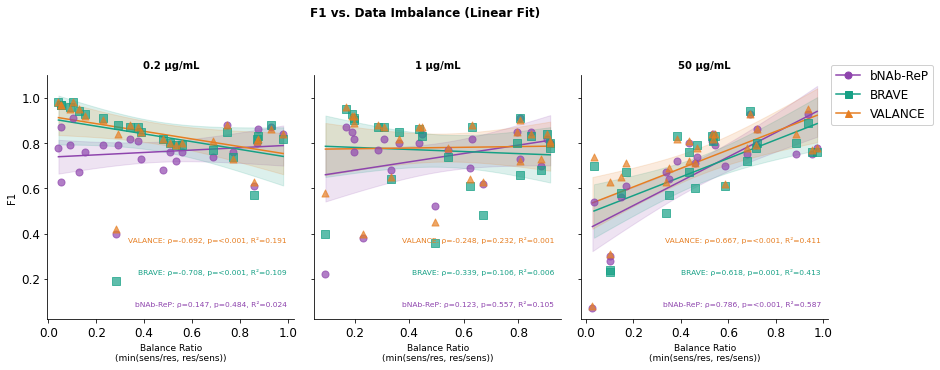

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

DATA_PATH       = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
ANTIBODIES_LIST = ['PGT121', 'VRC01', '10-1074', 'PGT145', '3BNC117', 'PGDM1400',
                   'VRC26.25', 'PGT151', 'PG9', '4E10', 'PGT128', 'SF12', 'N6',
                   '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 'VRC34.01',
                   'b12', 'VRC03', 'VRC07', '2F5', '8ANC195']

# Build counts_df 
df = pd.read_csv(DATA_PATH, sep="\t")
df["IC50"] = pd.to_numeric(df["IC50"], errors="coerce")

rows = []
for ab in ANTIBODIES_LIST:
    valid = df.loc[df["Antibody"] == ab, "IC50"].dropna()
    row   = {"Antibody": ab}
    for thr in THRESHOLDS:
        row[f"Sensitive (thr={thr})"] = (valid < thr).sum()
        row[f"Resistant (thr={thr})"] = (valid >= thr).sum()
    rows.append(row)
counts_df = pd.DataFrame(rows).set_index("Antibody")

XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
THRESHOLDS = [0.2, 1, 50]
METRIC     = "F1"      # change to "ACC", "MCC", "AUC", or "F1"
FIT_TYPE   = "linear"  # "linear" or "quadratic"

COLORS = {
    "bNAb-ReP": "#8E44AD",   # purple
    "BRAVE":    "#16A085",   # teal
    "VALANCE":  "#E67E22",   # orange
}
MARKERS = {
    "bNAb-ReP": "o",
    "BRAVE":    "s",
    "VALANCE":  "^",
}

# 1. Parse Excel 
COL_NAMES = [
    "Antibody", "Epitope", "Threshold",
    "bNab-rep MCC", "BRAVE MCC",    "VALANCE MCC",
    "bNab-rep ACC", "BRAVE ACC",    "VALANCE ACC",
    "bNab-rep AUC", "BRAVE AUC",    "VALANCE AUC",
    "bNab-rep F1",  "BRAVE F1",     "VALANCE F1",
]

def load_excel():
    frames = []
    for thr in [0.2, 1.0]:
        df = pd.read_excel(XLSX_PATH, sheet_name="Supplemental Table 1",
                           header=None, skiprows=2)
        df = df.iloc[:26, :15] if thr == 0.2 else df.iloc[27:56, :15]
        df.columns = COL_NAMES
        df = df[df["Antibody"].notna() & (df["Antibody"] != "Number of Wins")].copy()
        df["Threshold"] = pd.to_numeric(df["Threshold"], errors="coerce")
        frames.append(df[df["Threshold"] == thr])
    df50 = pd.read_excel(XLSX_PATH, sheet_name="Fig_1c",
                         header=None, skiprows=2)
    df50 = df50.iloc[:, :15]
    df50.columns = COL_NAMES
    df50 = df50[df50["Antibody"].notna() & (df50["Antibody"] != "Number of Wins")].copy()
    df50["Threshold"] = pd.to_numeric(df50["Threshold"], errors="coerce")
    frames.append(df50)
    return pd.concat(frames, ignore_index=True)

raw = load_excel()

for metric in ["MCC", "ACC", "AUC", "F1"]:
    raw[f"bNab-rep {metric}"] = raw[f"bNab-rep {metric}"]
    raw[f"BRAVE {metric}"]    = raw[f"BRAVE {metric}"]
    raw[f"VALANCE {metric}"]  = raw[f"VALANCE {metric}"]

MODELS = {
    "bNAb-ReP": f"bNab-rep {METRIC}",
    "BRAVE":    f"BRAVE {METRIC}",
    "VALANCE":  f"VALANCE {METRIC}",
}

def parse_mean(val):
    try:
        return float(str(val).split("(")[0])
    except:
        return np.nan

for col in MODELS.values():
    raw[col] = raw[col].apply(parse_mean)
raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")

# 2. Compute imbalance ratio 
imbalance_rows = []
for ab in raw["Antibody"].dropna().unique():
    for thr in THRESHOLDS:
        s = counts_df.loc[ab, f"Sensitive (thr={thr})"] if ab in counts_df.index else np.nan
        r = counts_df.loc[ab, f"Resistant (thr={thr})"] if ab in counts_df.index else np.nan
        ratio = min(s / r, r / s) if (s and r) else np.nan
        imbalance_rows.append({"Antibody": ab, "Threshold": thr, "Imbalance": ratio})

imbalance_df = pd.DataFrame(imbalance_rows)
merged = raw.merge(imbalance_df, on=["Antibody", "Threshold"], how="inner")

# 3. Fisher's z-test: compare Spearman |ρ| of VALANCE vs other models
def fisher_z_test_abs(r1, r2, n1, n2):
    """
    Two-tailed Fisher's z-test comparing two independent Spearman correlations.
    Tests H0: |ρ1| == |ρ2|  (i.e. equal sensitivity to imbalance).
    Returns (z_stat, p_value).
    """
    z1 = np.arctanh(abs(r1))
    z2 = np.arctanh(abs(r2))
    se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z_stat = (z1 - z2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return z_stat, p_value

print(f"\n{'='*65}")
print(f"Fisher's z-test on |ρ|: VALANCE vs other models ({METRIC} ~ Imbalance)")
print(f"H0: |ρ_VALANCE| == |ρ_other|  (equal sensitivity to imbalance)")
print(f"{'='*65}")

fisher_results = {}   # store for annotation
for thr in THRESHOLDS:
    sub = merged[merged["Threshold"] == thr].dropna(subset=["Imbalance"])
    print(f"\n  Threshold {thr} µg/mL:")

    rho_valance, _ = stats.spearmanr(
        sub[["Imbalance", MODELS["VALANCE"]]].dropna()["Imbalance"],
        sub[["Imbalance", MODELS["VALANCE"]]].dropna()[MODELS["VALANCE"]]
    )
    n_val = sub[["Imbalance", MODELS["VALANCE"]]].dropna().shape[0]

    fisher_results[thr] = {}
    for model in ["bNAb-ReP", "BRAVE"]:
        d = sub[["Imbalance", MODELS[model]]].dropna()
        rho_other, _ = stats.spearmanr(d["Imbalance"], d[MODELS[model]])
        n_other = len(d)
        z_stat, p_val = fisher_z_test_abs(rho_valance, rho_other, n_val, n_other)
        p_str = f"{p_val:.3f}" if p_val >= 0.001 else "<0.001"
        print(f"    VALANCE (|ρ|={abs(rho_valance):.3f}) vs {model} (|ρ|={abs(rho_other):.3f}): "
              f"z={z_stat:.3f}, p={p_str}")
        fisher_results[thr][model] = (rho_other, p_val)
    fisher_results[thr]["VALANCE_rho"] = rho_valance

# 4. Plot 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fig.subplots_adjust(wspace=0.08)

for ax, thr in zip(axes, THRESHOLDS):
    sub = merged[merged["Threshold"] == thr].dropna(subset=["Imbalance"])

    for i, (model, metric_col) in enumerate(MODELS.items()):
        d = sub[["Imbalance", metric_col]].dropna()
        x, y = d["Imbalance"].values, d[metric_col].values

        ax.scatter(x, y, color=COLORS[model], s=50, alpha=0.69, zorder=3,
                       marker=MARKERS[model])

        if len(x) > 2:
            x_line = np.linspace(x.min(), x.max(), 200)

            if FIT_TYPE == "quadratic":
                coeffs = np.polyfit(x, y, 2)
                y_fit  = np.polyval(coeffs, x_line)
                y_pred = np.polyval(coeffs, x)
                ss_res = np.sum((y - y_pred) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)
                r2     = 1 - ss_res / ss_tot
            else:
                slope, intercept, _, _, _ = stats.linregress(x, y)
                y_fit = slope * x_line + intercept
                r2    = np.corrcoef(x, y)[0, 1] ** 2

            # analytical 95% CI around regression line using prediction interval
            n      = len(x)
            x_mean = x.mean()
            se_line = np.sqrt(
                (np.sum((y - (slope * x + intercept))**2) / (n - 2)) *
                (1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
            )
            t_crit = stats.t.ppf(0.975, df=n - 2)
            ci_lo  = y_fit - t_crit * se_line
            ci_hi  = y_fit + t_crit * se_line

            ax.plot(x_line, y_fit, color=COLORS[model], linewidth=1.5, zorder=2)
            ax.fill_between(x_line, ci_lo, ci_hi,
                            color=COLORS[model], alpha=0.15, zorder=1)

            rho, p = stats.spearmanr(x, y)
            p_str  = f"{p:.3f}" if p >= 0.001 else "<0.001"
            ax.text(0.97, 0.05 + i * 0.13,
                    f"{model}: ρ={rho:.3f}, p={p_str}, R²={r2:.3f}",
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=7.5, color=COLORS[model])

    ax.set_title(f"{thr} µg/mL", fontsize=10, fontweight="bold")
    ax.set_xlabel("Balance Ratio\n(min(sens/res, res/sens))", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)


axes[0].set_ylabel(METRIC, fontsize=10)

handles = [plt.Line2D([0], [0], color=COLORS[m], marker=MARKERS[m],
                       markersize=7, linewidth=1.5, label=m)
           for m in COLORS]
fig.legend(handles=handles, loc="upper right", ncol=1, fontsize=12,
           frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(1.01, 0.93))

fit_label = "Quadratic" if FIT_TYPE == "quadratic" else "Linear"
fig.suptitle(f"{METRIC} vs. Data Imbalance ({fit_label} Fit)",
             fontsize=12, fontweight="bold", y=1.09)

plt.savefig(
    f"/Users/YUQIAO/blackbox/VALANCE/plots/{METRIC.lower()}_vs_imbalance_{FIT_TYPE}.png",
    bbox_inches="tight", dpi=500
)
plt.show()

### Remove titles, axis labels for publication


Fisher's z-test on |ρ|: VALANCE vs other models (ACC ~ Imbalance)
H0: |ρ_VALANCE| == |ρ_other|  (equal sensitivity to imbalance)

  Threshold 0.2 µg/mL:
    VALANCE (|ρ|=0.514) vs bNAb-ReP (|ρ|=0.553): z=-0.183, p=0.855
    VALANCE (|ρ|=0.514) vs BRAVE (|ρ|=0.547): z=-0.153, p=0.879

  Threshold 1 µg/mL:
    VALANCE (|ρ|=0.196) vs bNAb-ReP (|ρ|=0.548): z=-1.384, p=0.166
    VALANCE (|ρ|=0.196) vs BRAVE (|ρ|=0.260): z=-0.223, p=0.823

  Threshold 50 µg/mL:
    VALANCE (|ρ|=0.438) vs bNAb-ReP (|ρ|=0.213): z=0.841, p=0.400
    VALANCE (|ρ|=0.438) vs BRAVE (|ρ|=0.483): z=-0.189, p=0.850


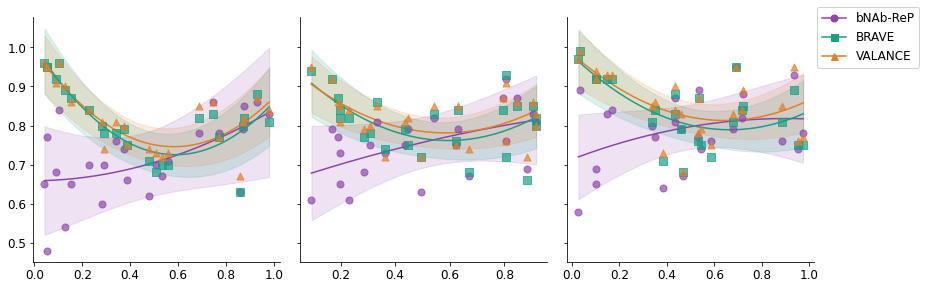

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

DATA_PATH       = "/Users/YUQIAO/blackbox/VALANCE/env_neu_unique_ab_removed_outliers_duplicates_geomean_include_TBDs.txt"
ANTIBODIES_LIST = ['PGT121', 'VRC01', '10-1074', 'PGT145', '3BNC117', 'PGDM1400',
                   'VRC26.25', 'PGT151', 'PG9', '4E10', 'PGT128', 'SF12', 'N6',
                   '35O22', 'PGT135', 'VRC-PG04', 'CH01', 'HJ16', '10E8', 'VRC34.01',
                   'b12', 'VRC03', 'VRC07', '2F5', '8ANC195']

# Build counts_df 
df = pd.read_csv(DATA_PATH, sep="\t")
df["IC50"] = pd.to_numeric(df["IC50"], errors="coerce")

rows = []
for ab in ANTIBODIES_LIST:
    valid = df.loc[df["Antibody"] == ab, "IC50"].dropna()
    row   = {"Antibody": ab}
    for thr in THRESHOLDS:
        row[f"Sensitive (thr={thr})"] = (valid < thr).sum()
        row[f"Resistant (thr={thr})"] = (valid >= thr).sum()
    rows.append(row)
counts_df = pd.DataFrame(rows).set_index("Antibody")

XLSX_PATH  = "/Users/YUQIAO/blackbox/VALANCE/Supplemental_Tables_Final.xlsx"
THRESHOLDS = [0.2, 1, 50]
METRIC     = "ACC"      # change to "ACC", "MCC", "AUC", or "F1"
FIT_TYPE   = "quadratic"  # "linear" or "quadratic"

COLORS = {
    "bNAb-ReP": "#8E44AD",   # purple
    "BRAVE":    "#16A085",   # teal
    "VALANCE":  "#E67E22",   # orange
}
MARKERS = {
    "bNAb-ReP": "o",
    "BRAVE":    "s",
    "VALANCE":  "^",
}

# 1. Parse Excel 
COL_NAMES = [
    "Antibody", "Epitope", "Threshold",
    "bNab-rep MCC", "BRAVE MCC",    "VALANCE MCC",
    "bNab-rep ACC", "BRAVE ACC",    "VALANCE ACC",
    "bNab-rep AUC", "BRAVE AUC",    "VALANCE AUC",
    "bNab-rep F1",  "BRAVE F1",     "VALANCE F1",
]

def load_excel():
    frames = []
    for thr in [0.2, 1.0]:
        df = pd.read_excel(XLSX_PATH, sheet_name="Supplemental Table 1",
                           header=None, skiprows=2)
        df = df.iloc[:26, :15] if thr == 0.2 else df.iloc[27:56, :15]
        df.columns = COL_NAMES
        df = df[df["Antibody"].notna() & (df["Antibody"] != "Number of Wins")].copy()
        df["Threshold"] = pd.to_numeric(df["Threshold"], errors="coerce")
        frames.append(df[df["Threshold"] == thr])
    df50 = pd.read_excel(XLSX_PATH, sheet_name="Fig_1c",
                         header=None, skiprows=2)
    df50 = df50.iloc[:, :15]
    df50.columns = COL_NAMES
    df50 = df50[df50["Antibody"].notna() & (df50["Antibody"] != "Number of Wins")].copy()
    df50["Threshold"] = pd.to_numeric(df50["Threshold"], errors="coerce")
    frames.append(df50)
    return pd.concat(frames, ignore_index=True)

raw = load_excel()

# rename columns to match MODELS lookup
for metric in ["MCC", "ACC", "AUC", "F1"]:
    raw[f"bNab-rep {metric}"] = raw[f"bNab-rep {metric}"]
    raw[f"BRAVE {metric}"]    = raw[f"BRAVE {metric}"]
    raw[f"VALANCE {metric}"]  = raw[f"VALANCE {metric}"]

MODELS = {
    "bNAb-ReP": f"bNab-rep {METRIC}",
    "BRAVE":    f"BRAVE {METRIC}",
    "VALANCE":  f"VALANCE {METRIC}",
}

def parse_mean(val):
    try:
        return float(str(val).split("(")[0])
    except:
        return np.nan

for col in MODELS.values():
    raw[col] = raw[col].apply(parse_mean)
raw["Threshold"] = pd.to_numeric(raw["Threshold"], errors="coerce")

# 2. Compute imbalance ratio 
imbalance_rows = []
for ab in raw["Antibody"].dropna().unique():
    for thr in THRESHOLDS:
        s = counts_df.loc[ab, f"Sensitive (thr={thr})"] if ab in counts_df.index else np.nan
        r = counts_df.loc[ab, f"Resistant (thr={thr})"] if ab in counts_df.index else np.nan
        ratio = min(s / r, r / s) if (s and r) else np.nan
        imbalance_rows.append({"Antibody": ab, "Threshold": thr, "Imbalance": ratio})

imbalance_df = pd.DataFrame(imbalance_rows)
merged = raw.merge(imbalance_df, on=["Antibody", "Threshold"], how="inner")

# 3. Fisher's z-test: compare Spearman |ρ| of VALANCE vs other models
def fisher_z_test_abs(r1, r2, n1, n2):
    """
    Two-tailed Fisher's z-test comparing two independent Spearman correlations.
    Tests H0: |ρ1| == |ρ2|  (i.e. equal sensitivity to imbalance).
    Returns (z_stat, p_value).
    """
    z1 = np.arctanh(abs(r1))
    z2 = np.arctanh(abs(r2))
    se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z_stat = (z1 - z2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return z_stat, p_value

print(f"\n{'='*65}")
print(f"Fisher's z-test on |ρ|: VALANCE vs other models ({METRIC} ~ Imbalance)")
print(f"H0: |ρ_VALANCE| == |ρ_other|  (equal sensitivity to imbalance)")
print(f"{'='*65}")

fisher_results = {}   # store for annotation
for thr in THRESHOLDS:
    sub = merged[merged["Threshold"] == thr].dropna(subset=["Imbalance"])
    print(f"\n  Threshold {thr} µg/mL:")

    rho_valance, _ = stats.spearmanr(
        sub[["Imbalance", MODELS["VALANCE"]]].dropna()["Imbalance"],
        sub[["Imbalance", MODELS["VALANCE"]]].dropna()[MODELS["VALANCE"]]
    )
    n_val = sub[["Imbalance", MODELS["VALANCE"]]].dropna().shape[0]

    fisher_results[thr] = {}
    for model in ["bNAb-ReP", "BRAVE"]:
        d = sub[["Imbalance", MODELS[model]]].dropna()
        rho_other, _ = stats.spearmanr(d["Imbalance"], d[MODELS[model]])
        n_other = len(d)
        z_stat, p_val = fisher_z_test_abs(rho_valance, rho_other, n_val, n_other)
        p_str = f"{p_val:.3f}" if p_val >= 0.001 else "<0.001"
        print(f"    VALANCE (|ρ|={abs(rho_valance):.3f}) vs {model} (|ρ|={abs(rho_other):.3f}): "
              f"z={z_stat:.3f}, p={p_str}")
        fisher_results[thr][model] = (rho_other, p_val)
    fisher_results[thr]["VALANCE_rho"] = rho_valance

# 4. Plot 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fig.subplots_adjust(wspace=0.08)

for ax, thr in zip(axes, THRESHOLDS):
    sub = merged[merged["Threshold"] == thr].dropna(subset=["Imbalance"])

    for i, (model, metric_col) in enumerate(MODELS.items()):
        d = sub[["Imbalance", metric_col]].dropna()
        x, y = d["Imbalance"].values, d[metric_col].values

        ax.scatter(x, y, color=COLORS[model], s=50, alpha=0.69, zorder=3,
                       marker=MARKERS[model])

        if len(x) > 2:
            x_line = np.linspace(x.min(), x.max(), 200)

            if FIT_TYPE == "quadratic":
                coeffs = np.polyfit(x, y, 2)
                y_fit  = np.polyval(coeffs, x_line)
                y_pred = np.polyval(coeffs, x)
                ss_res = np.sum((y - y_pred) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)
                r2     = 1 - ss_res / ss_tot
            else:
                slope, intercept, _, _, _ = stats.linregress(x, y)
                y_fit = slope * x_line + intercept
                r2    = np.corrcoef(x, y)[0, 1] ** 2
      
            # analytical 95% CI around regression line using prediction interval
            n      = len(x)
            x_mean = x.mean()
            se_line = np.sqrt(
                (np.sum((y - (slope * x + intercept))**2) / (n - 2)) *
                (1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
            )
            t_crit = stats.t.ppf(0.975, df=n - 2)
            ci_lo  = y_fit - t_crit * se_line
            ci_hi  = y_fit + t_crit * se_line
            
            

            ax.plot(x_line, y_fit, color=COLORS[model], linewidth=1.5, zorder=2)
            ax.fill_between(x_line, ci_lo, ci_hi,
                            color=COLORS[model], alpha=0.15, zorder=1)

            rho, p = stats.spearmanr(x, y)
            p_str  = f"{p:.3f}" if p >= 0.001 else "<0.001"
#             ax.text(0.97, 0.05 + i * 0.13,
#                     f"{model}: ρ={rho:.3f}, p={p_str}, R²={r2:.3f}",
#                     transform=ax.transAxes, ha="right", va="bottom",
#                     fontsize=7.5, color=COLORS[model])

    # ax.set_title(f"{thr} µg/mL", fontsize=10, fontweight="bold")
    # ax.set_xlabel("Imbalance Ratio\n(min(sens/res, res/sens))", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)


# axes[0].set_ylabel(METRIC, fontsize=10)

handles = [plt.Line2D([0], [0], color=COLORS[m], marker=MARKERS[m],
                       markersize=7, linewidth=1.5, label=m)
           for m in COLORS]
fig.legend(handles=handles, loc="upper right", ncol=1, fontsize=12,
           frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(1.01, 0.93))

fit_label = "Quadratic" if FIT_TYPE == "quadratic" else "Linear"
# fig.suptitle(f"{METRIC} vs. Data Imbalance ({fit_label} Fit)",
#              fontsize=12, fontweight="bold", y=1.09)

plt.savefig(
    f"/Users/YUQIAO/blackbox/VALANCE/plots/{METRIC.lower()}_vs_imbalance_{FIT_TYPE}.png",
    bbox_inches="tight", dpi=800
)
plt.show()